In [1]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_kl_gamma-0.2_vq_beta-0.3_target_data-heart_description-None/42/best_20251119_141941.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: ['latent_graph.node_embeddings', 'gnn_experts.graph_gnns.0.linear.weight', 'gnn_experts.graph_gnns.0.linear.bias', 'gnn_experts.graph_gnns.0.update.weight', 'gnn_experts.graph_gnns.0.update.bias', 'gnn_experts.graph_gnns.0.norm.weight', 'gnn_experts.graph_gnns.0.norm.bias', 'gnn_experts.graph_gnns.1.linear.weight', 'gnn_experts.graph_gnns.1.linear.bias', 'gnn_experts.graph_gnns.1.update.weight', 'gnn_experts.graph_gnns.1.update.bias', 'gnn_experts.graph_gnns.1.norm.weight', 'gnn_experts.graph_gnns.1.norm.bias', 'gnn_experts.graph_gnns.2.linear.weight', 'gnn_experts.graph_gnns.2.linear.bias', 'gnn_experts.graph_gnns.2.update.weight', 'gnn_experts.graph_gnns.2.update.bias', 'gnn_experts.graph_gnns.2.norm.weight', 'gnn_experts.graph_gnns.2.norm.bias', 'gnn_experts.graph_gnns.3.linear.weight', 'gnn_experts.graph_gnns.3.linear.bias', 'gnn_experts.graph_gnns.3.update.weight', 'gnn_experts.graph_gnns.3.update.bias', 'gnn_experts.graph_gnns.3.norm.weight', 'gnn_experts.graph_gnns

Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleLis

In [2]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_3
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_3.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_4
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_4.pkl
Training data size: 600
Va

In [3]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





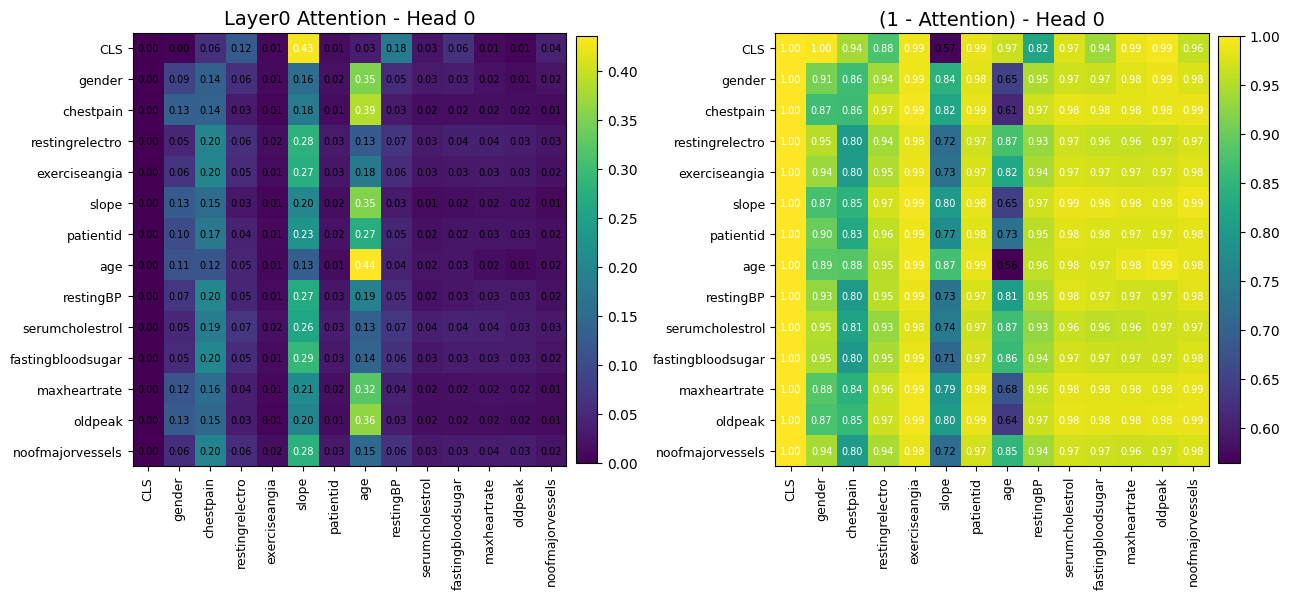

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0010 | std=0.2838
         gender  | mean=0.0356 | std=2.3787
      chestpain  | mean=0.2571 | std=5.5455
restingrelectro  | mean=0.3142 | std=6.4835
  exerciseangia  | mean=0.0520 | std=2.4422
          slope  | mean=0.2458 | std=5.6105
      patientid  | mean=0.2616 | std=6.9971
            age  | mean=-0.0637 | std=2.8077
      restingBP  | mean=0.2657 | std=6.2182
serumcholestrol  | mean=-0.0734 | std=1.4744
fastingbloodsugar  | mean=-0.1801 | std=3.8014
   maxheartrate  | mean=0.1924 | std=4.1469
        oldpeak  | mean=0.1636 | std=4.0177
noofmajorvessels  | mean=0.2412 | std=4.9261

=== Global embedding statistics ===
global mean: 0.1222
global std : 4.5200


In [5]:
src = sources[1]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



In [6]:
import torch
import ot
from ot.backend import get_backend

# 배치 데이터 생성
batch_size = 32
n, m = 10, 8

# Source와 target distributions (batch)
a = torch.ones(batch_size, n) / n
b = torch.ones(batch_size, m) / m

# Cost matrices (batch)
xs = torch.randn(batch_size, n, 2)
xt = torch.randn(batch_size, m, 2)

# Structure matrices for Gromov-Wasserstein
C1 = torch.cdist(xs, xs)  # [batch, n, n]
C2 = torch.cdist(xt, xt)  # [batch, m, m]

# Feature cost for Fused GW
M = torch.cdist(xs, xt)   # [batch, n, m]

print("Testing batch Fused Gromov-Wasserstein...")

# Batch solve
from ot.batch import solve_gromov_batch

result = solve_gromov_batch(
    C1, C2,
    M=M,           # Feature cost (Fused)
    alpha=0.5,     # Balance between feature and structure
    reg=0.01,      # Entropic regularization
    a=a, b=b,
    max_iter=50
)

# OTResult 객체에서 transport plan 추출
T = result.value  # 또는 result.plan

print(f"✅ Success! Transport plan shape: {T.shape}")
print(f"Transport plan sum (should be ~1): {T[0].sum().item():.4f}")

# OTResult의 다른 속성들
print(f"\nOTResult attributes: {dir(result)}")

Testing batch Fused Gromov-Wasserstein...
✅ Success! Transport plan shape: torch.Size([32])
Transport plan sum (should be ~1): 0.6415

OTResult attributes: ['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_backend', '_batch_size', '_lazy_plan', '_log', '_plan', '_potentials', '_sparse_plan', '_status', '_value', '_value_linear', '_value_quad', 'a_to_b', 'b_to_a', 'citation', 'lazy_plan', 'log', 'marginal_a', 'marginal_b', 'marginals', 'plan', 'potential_a', 'potential_b', 'potentials', 'sparse_plan', 'status', 'value', 'value_linear', 'value_quad']


In [7]:
def train_with_pot_fgw_multi_source(model, loaders, learnable_graphs, optimizer,
                                    alpha=0.5, reg=0.01, batches_per_source=20):
    model.train()
    learnable_graphs.train()

    total_loss = 0
    total_batches = 0

    for src_name, loader in loaders.items():
        print(f"\n=== Source {src_name} ===")

        for batch_idx, batch in enumerate(loader):
            if batch_idx >= batches_per_source:
                break

            # 1. Extract source graph
            source_features, source_structure = extract_source_graph(model, batch)

            # 2. Current LCG graphs
            target_features, target_structure = learnable_graphs()

            # 3. FGW computation
            _, fgw_values, feature_costs, structure_costs, transport_plans = compute_batch_fgw(
                source_features, source_structure,
                target_features, target_structure,
                alpha=alpha, reg=reg
            )

            # Loss = FGW + orthogonal
            fgw_loss = fgw_values.mean()
            orth_loss = learnable_graphs.orthogonal_loss()
            loss = fgw_loss +  orth_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_batches += 1

            if batch_idx % 10 == 0:
                print(f"[{src_name}] Batch {batch_idx} Loss: {loss.item():.4f}")

    avg_loss = total_loss / total_batches
    return avg_loss


In [ ]:
# optimizer = torch.optim.Adam(learnable_graphs.parameters(), lr=1e-3)

# for epoch in range(1, 4):
#     print(f"\n===== Epoch {epoch} =====")
#     avg_loss = train_with_pot_fgw_multi_source(
#         model, loaders, learnable_graphs, optimizer,
#         alpha=0.5, reg=0.01, batches_per_source=20
#     )
#     print(f"Epoch {epoch} - Avg Loss: {avg_loss:.4f}")


NameError: name 'learnable_graphs' is not defined

Training with source: Heart_disease_statlog
Model input_dim: 768
Learnable graphs: M=8, K=8, D=768

===== Epoch 1 =====
Batch 0, Loss: 0.1366 (FGW: 0.1358, Orth: 0.0008)
  Total FGW (first sample): [0.11720367 0.18201534 0.11520121 0.24504867 0.12194858 0.24468762
 0.1169985  0.12064479]
  Feature cost (first sample): [0.05689026 0.05650016 0.05762156 0.05787552 0.0570688  0.0572881
 0.05710809 0.0563003 ]
  Structure cost (first sample): [0.0603134  0.12551518 0.05757965 0.18717316 0.06487978 0.18739952
 0.05989041 0.0643445 ]
Epoch 1 - Average Loss: 0.1480

===== Epoch 2 =====
Batch 0, Loss: 0.1325 (FGW: 0.1317, Orth: 0.0008)
  Total FGW (first sample): [0.1156712  0.17504668 0.11495233 0.2373095  0.11933832 0.23710722
 0.11580098 0.11797854]
  Feature cost (first sample): [0.05684067 0.05644011 0.05756493 0.05784533 0.05705643 0.05721716
 0.05711133 0.05622856]
  Structure cost (first sample): [0.05883052 0.11860658 0.0573874  0.17946418 0.06228188 0.17989005
 0.05868965 0.06174997]

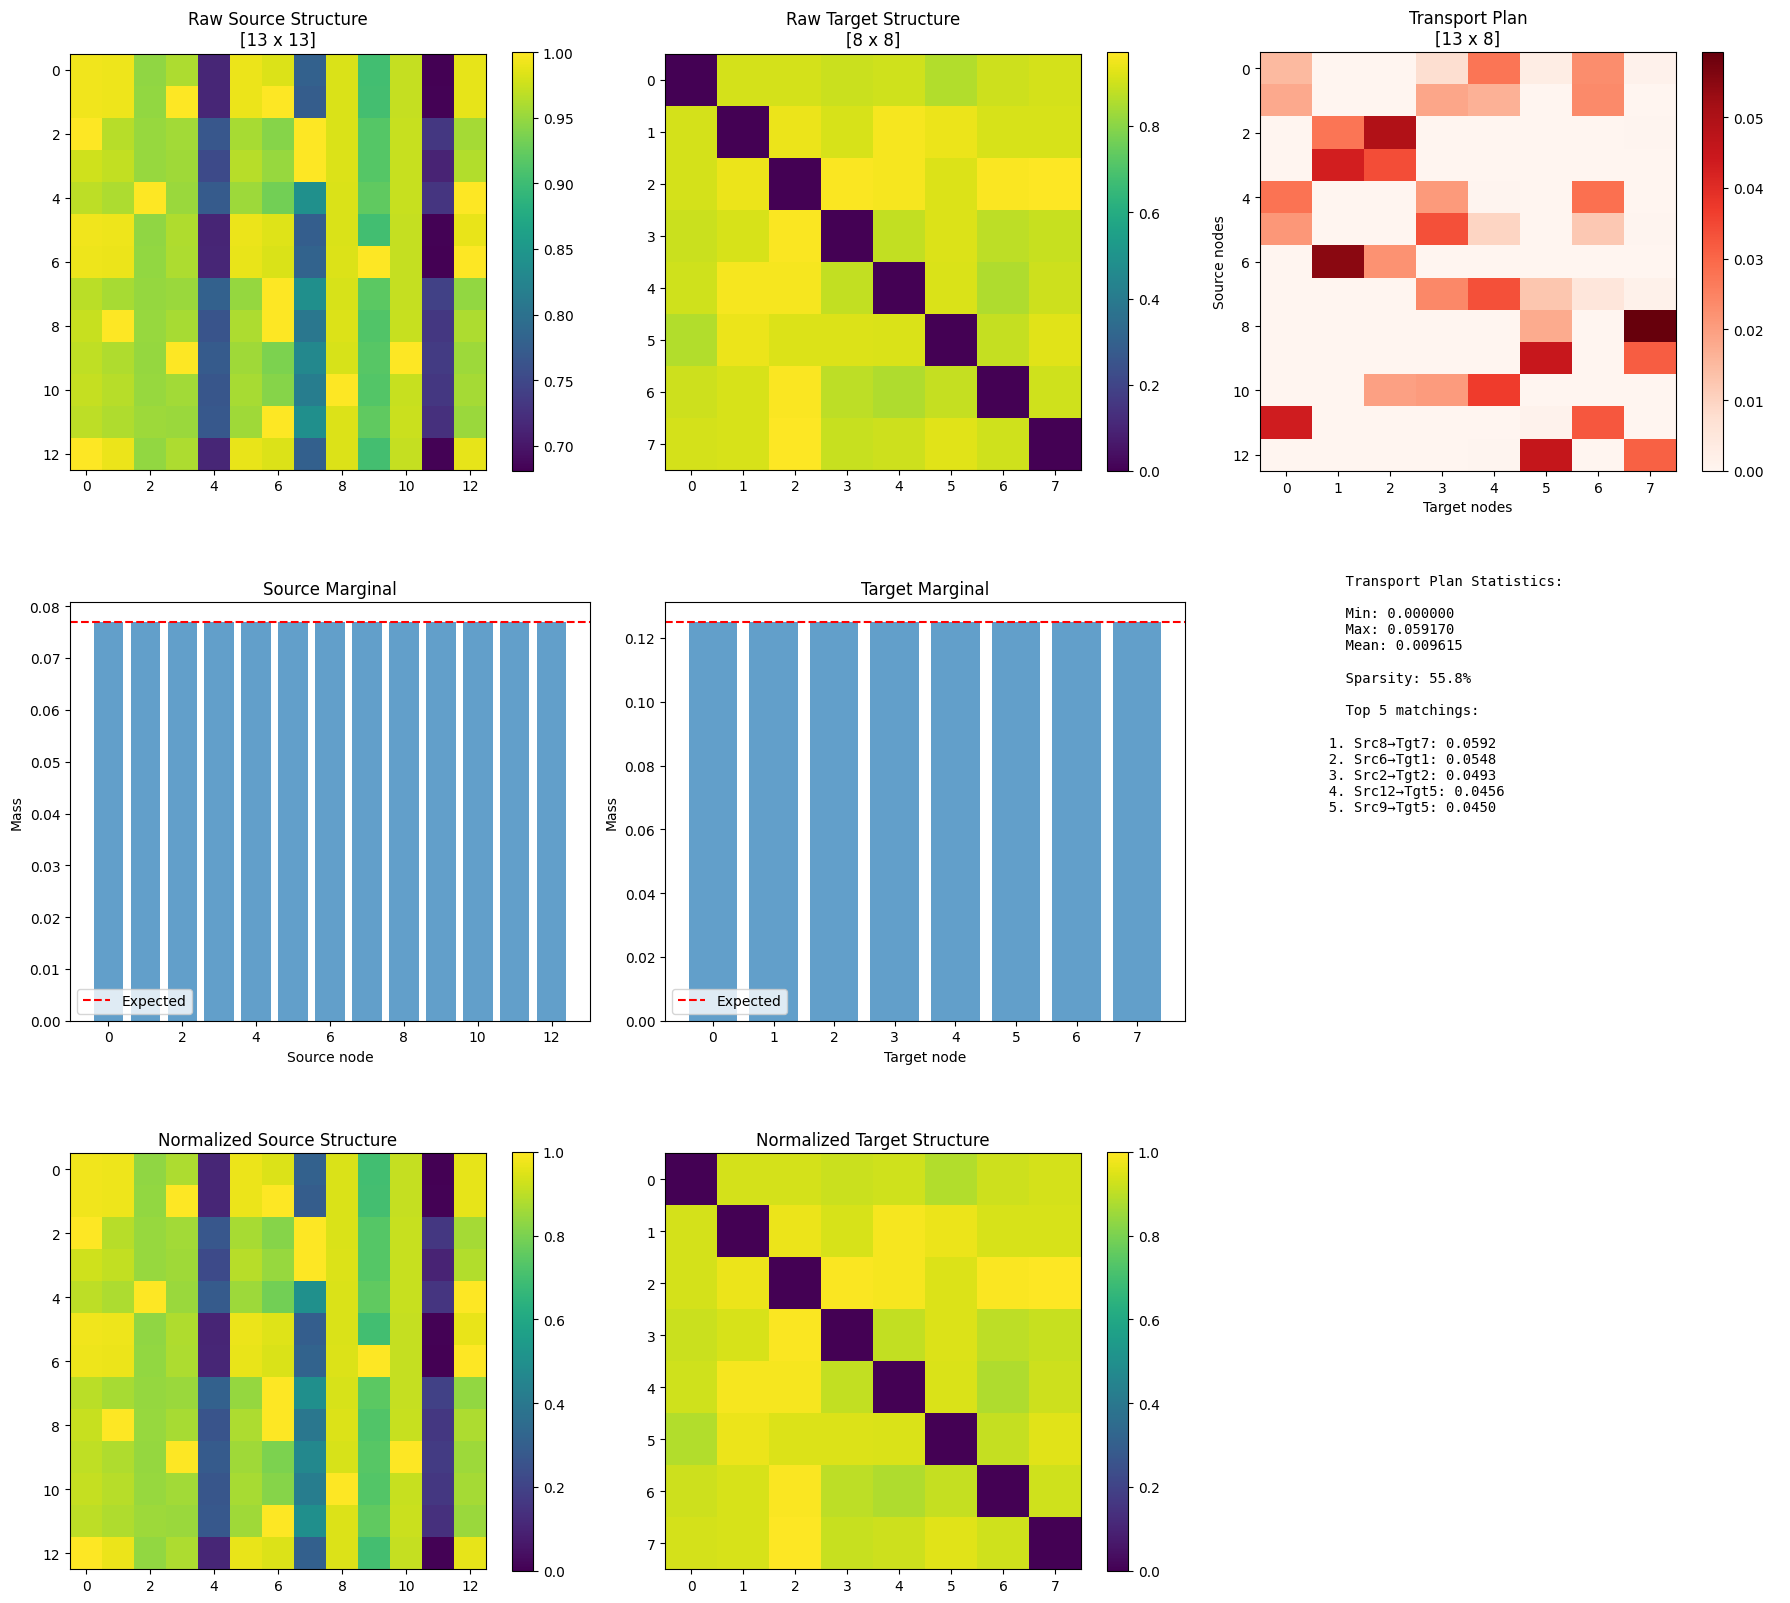

✅ Visualization saved!

Visualizing Sample 1 with Graph 1


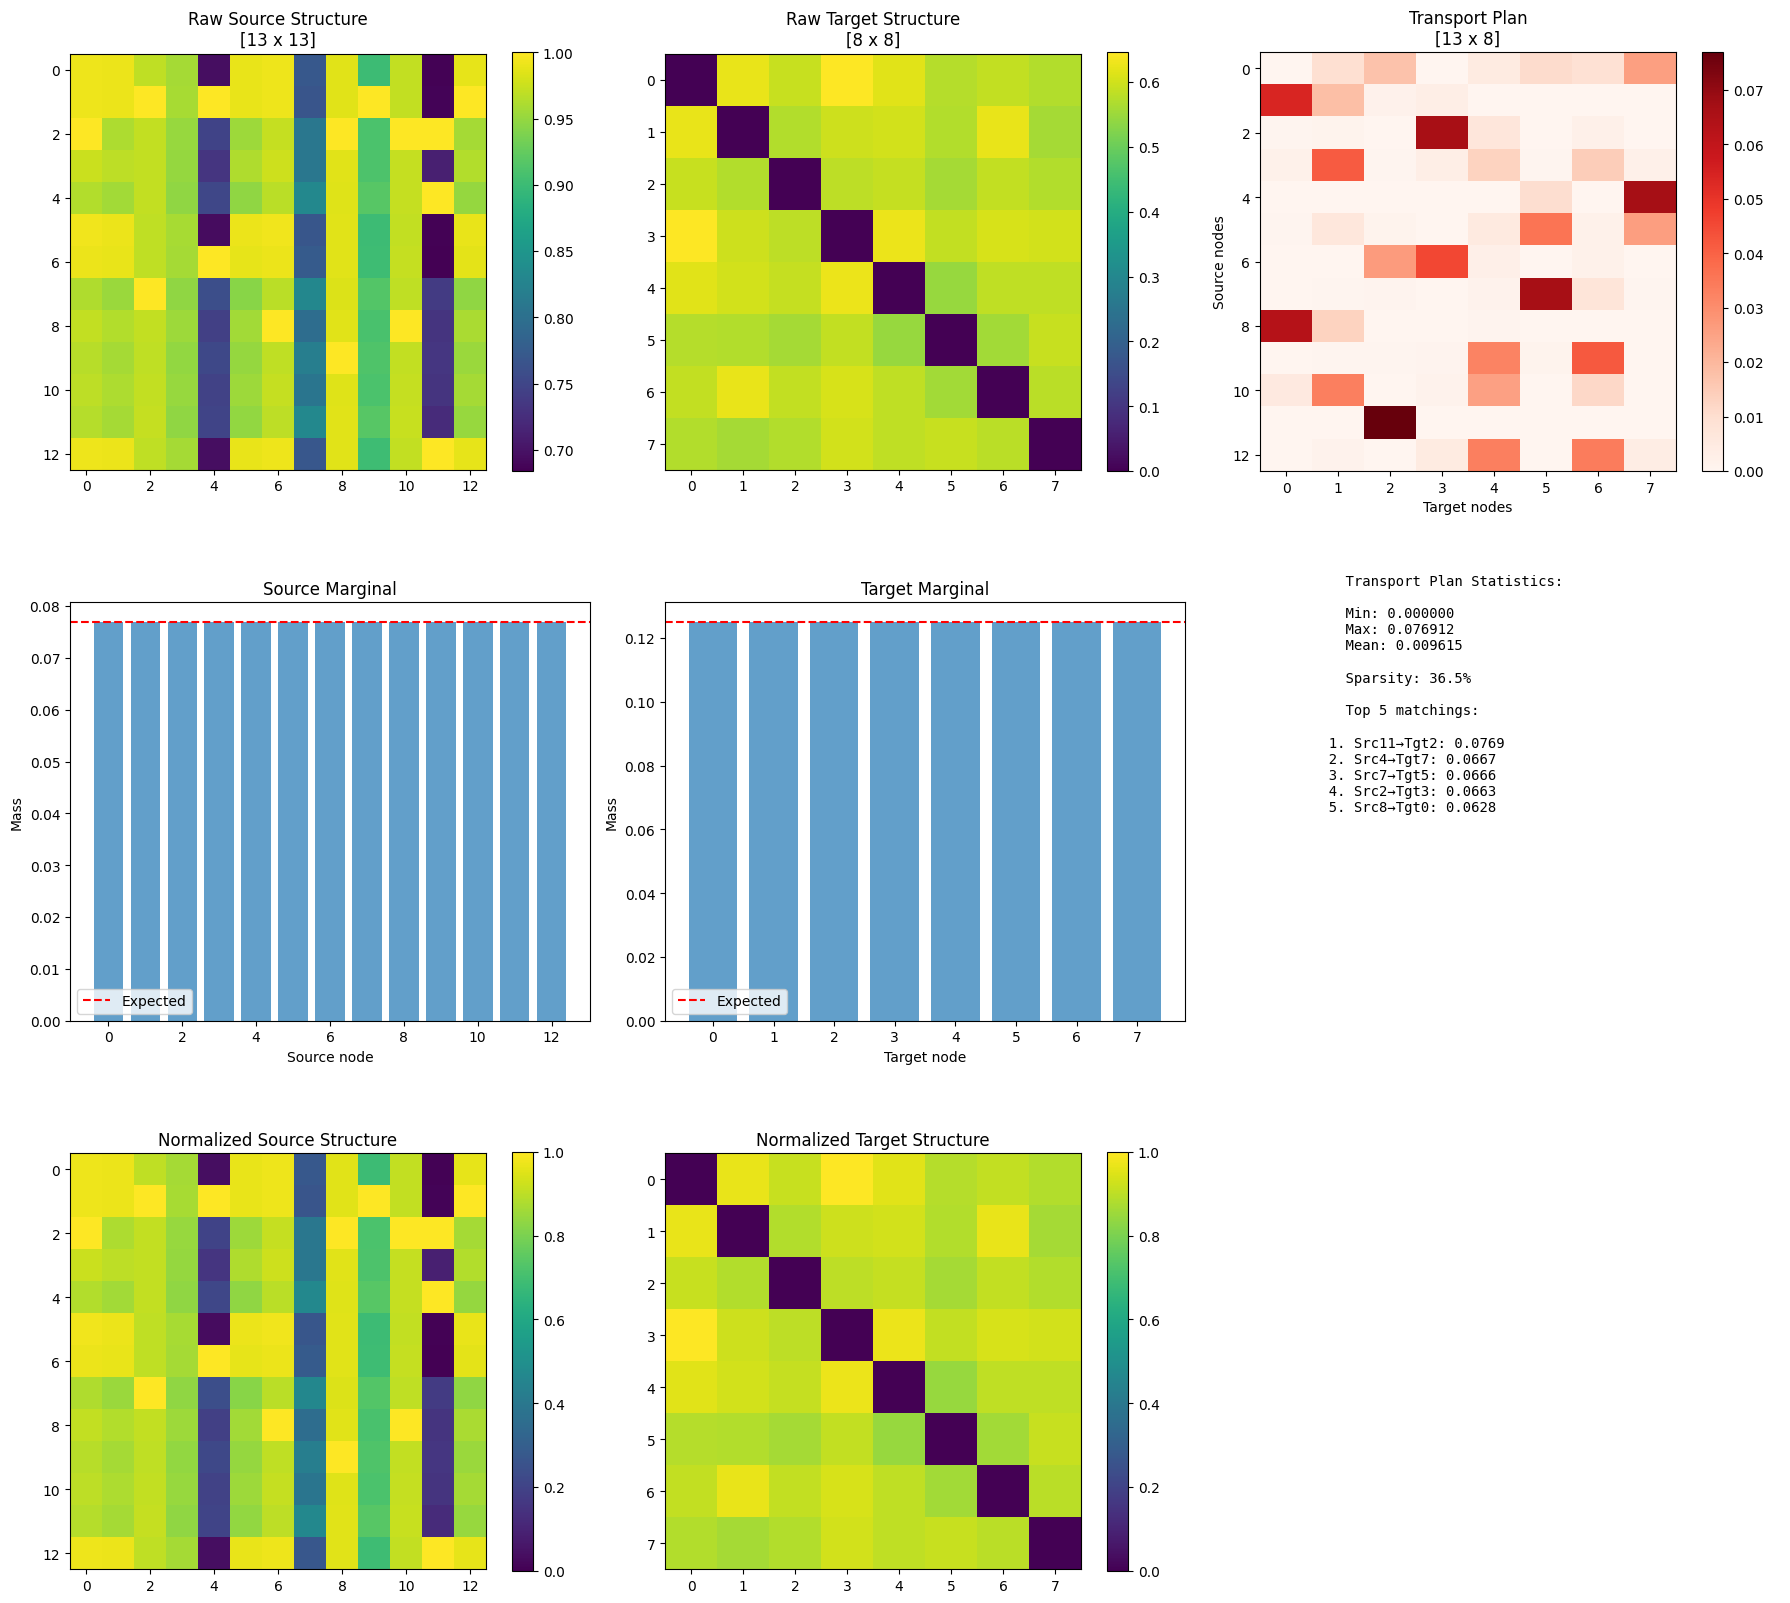

✅ Visualization saved!

Visualizing Sample 2 with Graph 2


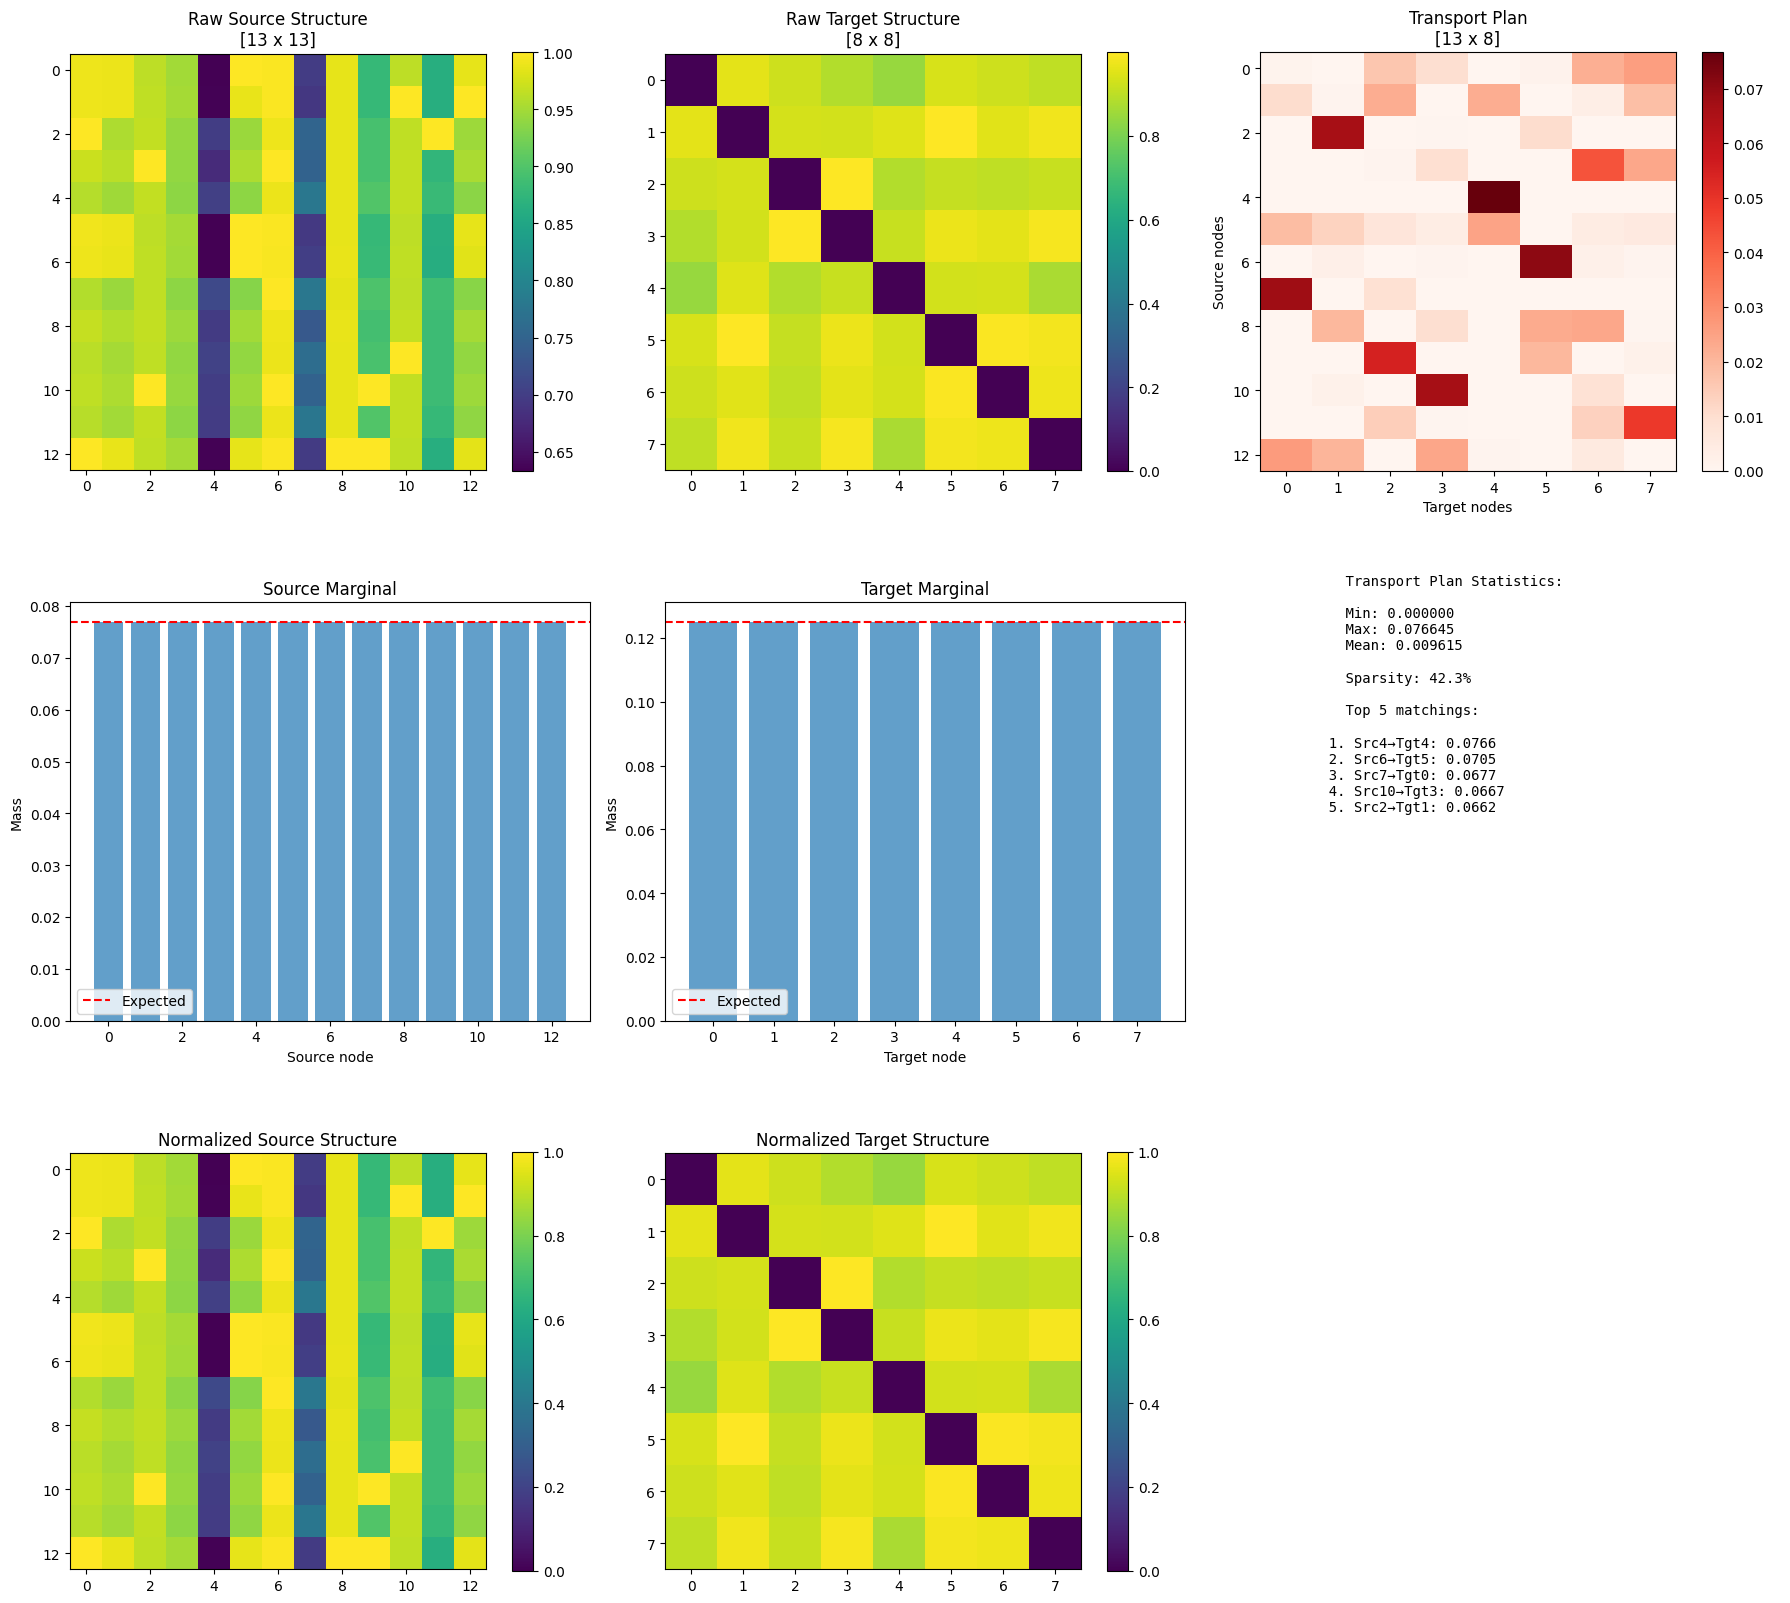

✅ Visualization saved!

Visualizing Sample 3 with Graph 3


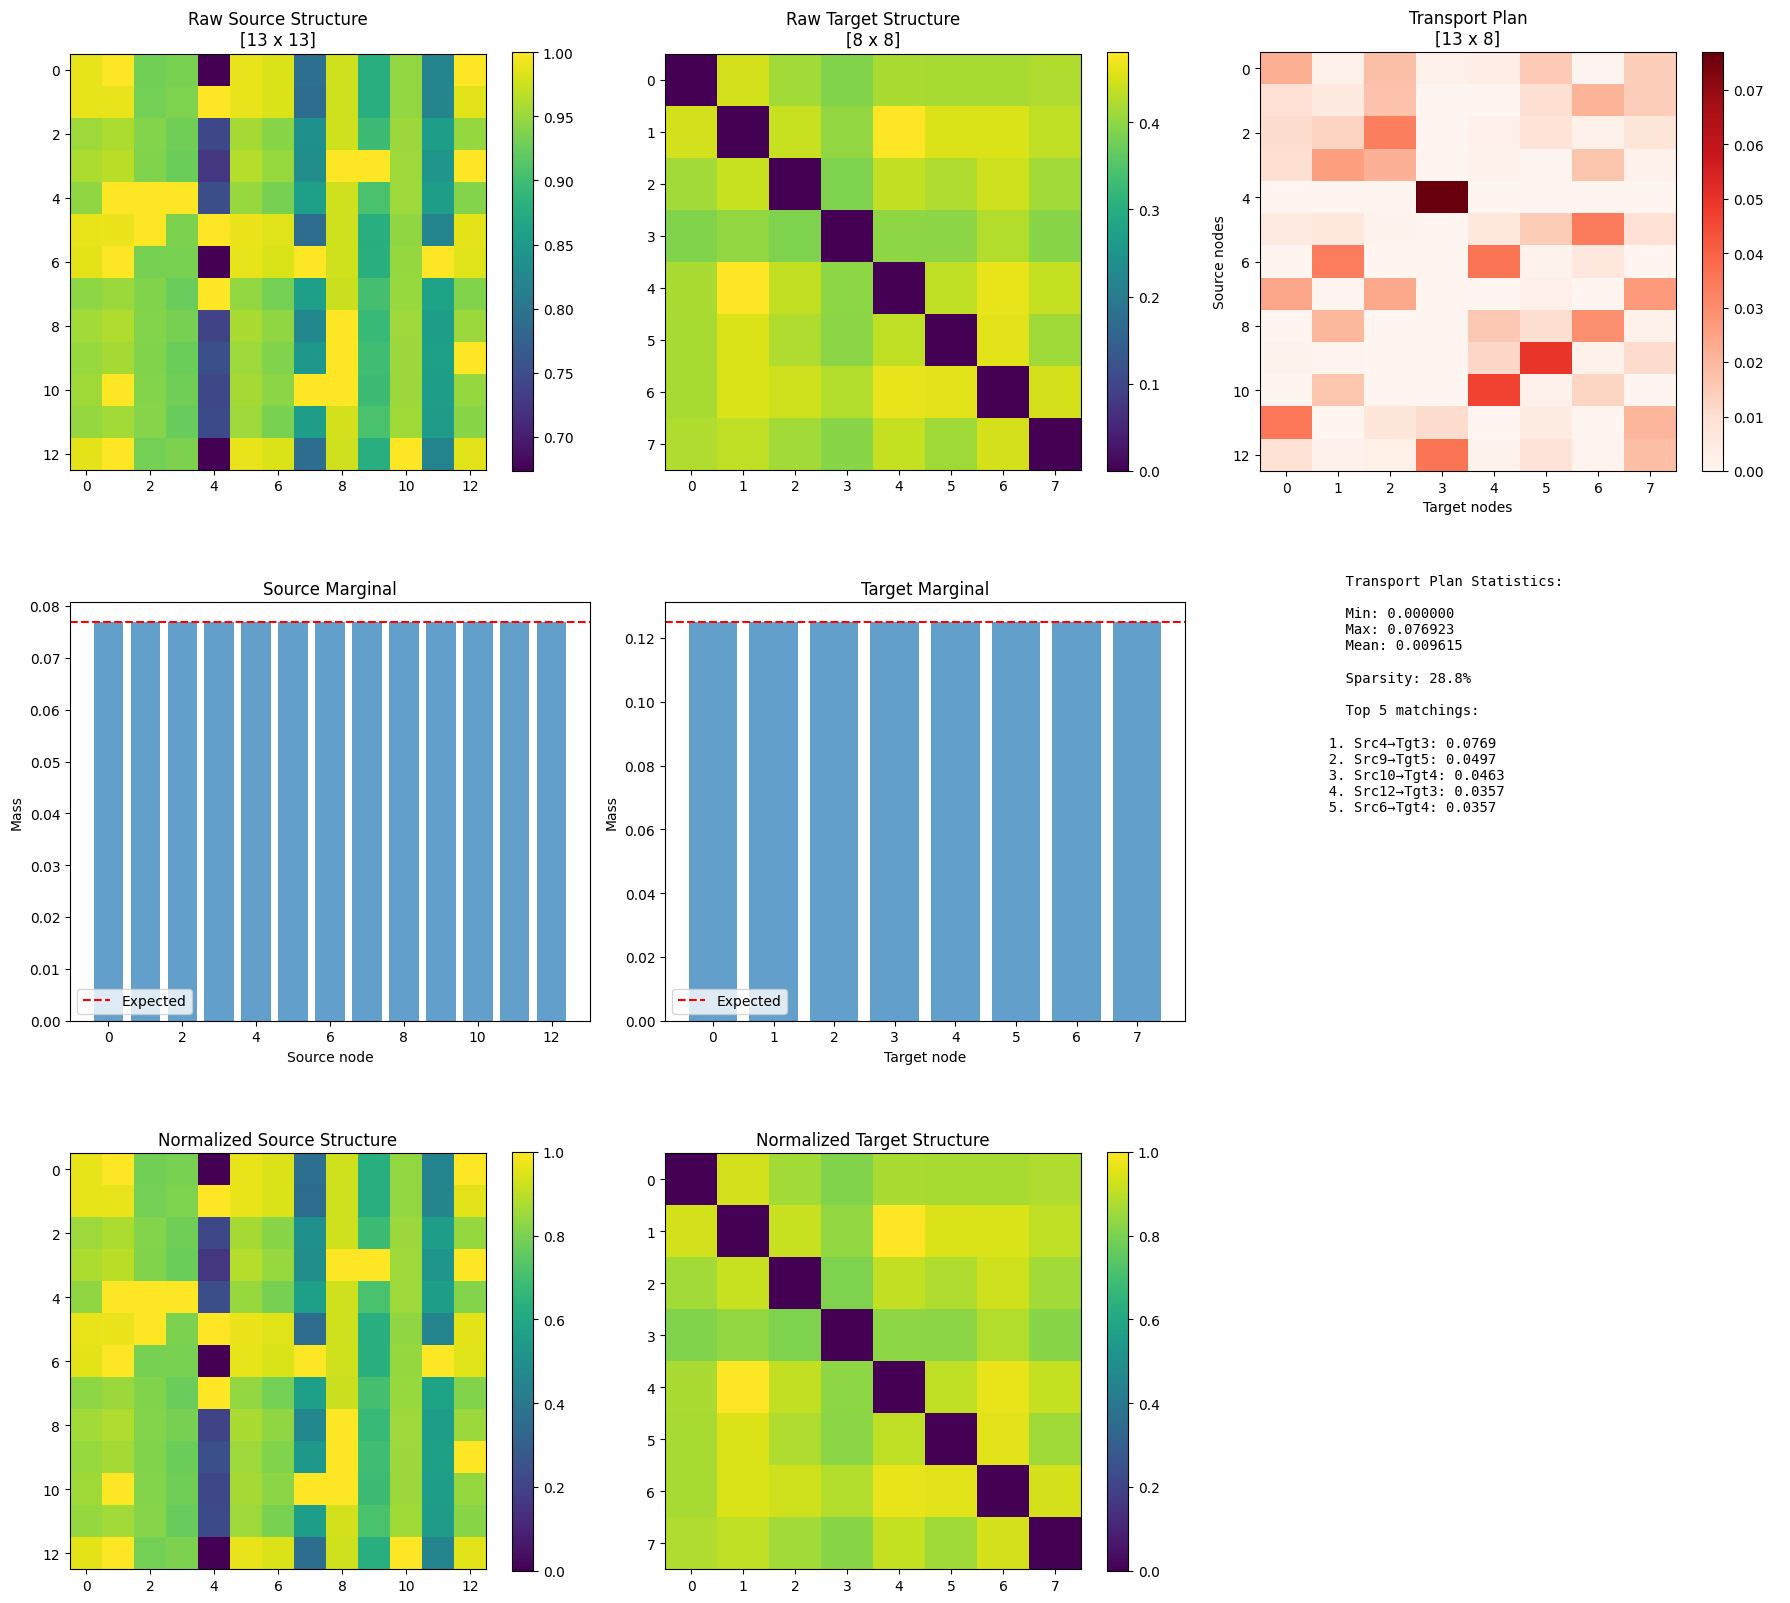

✅ Visualization saved!

Visualizing Sample 4 with Graph 4


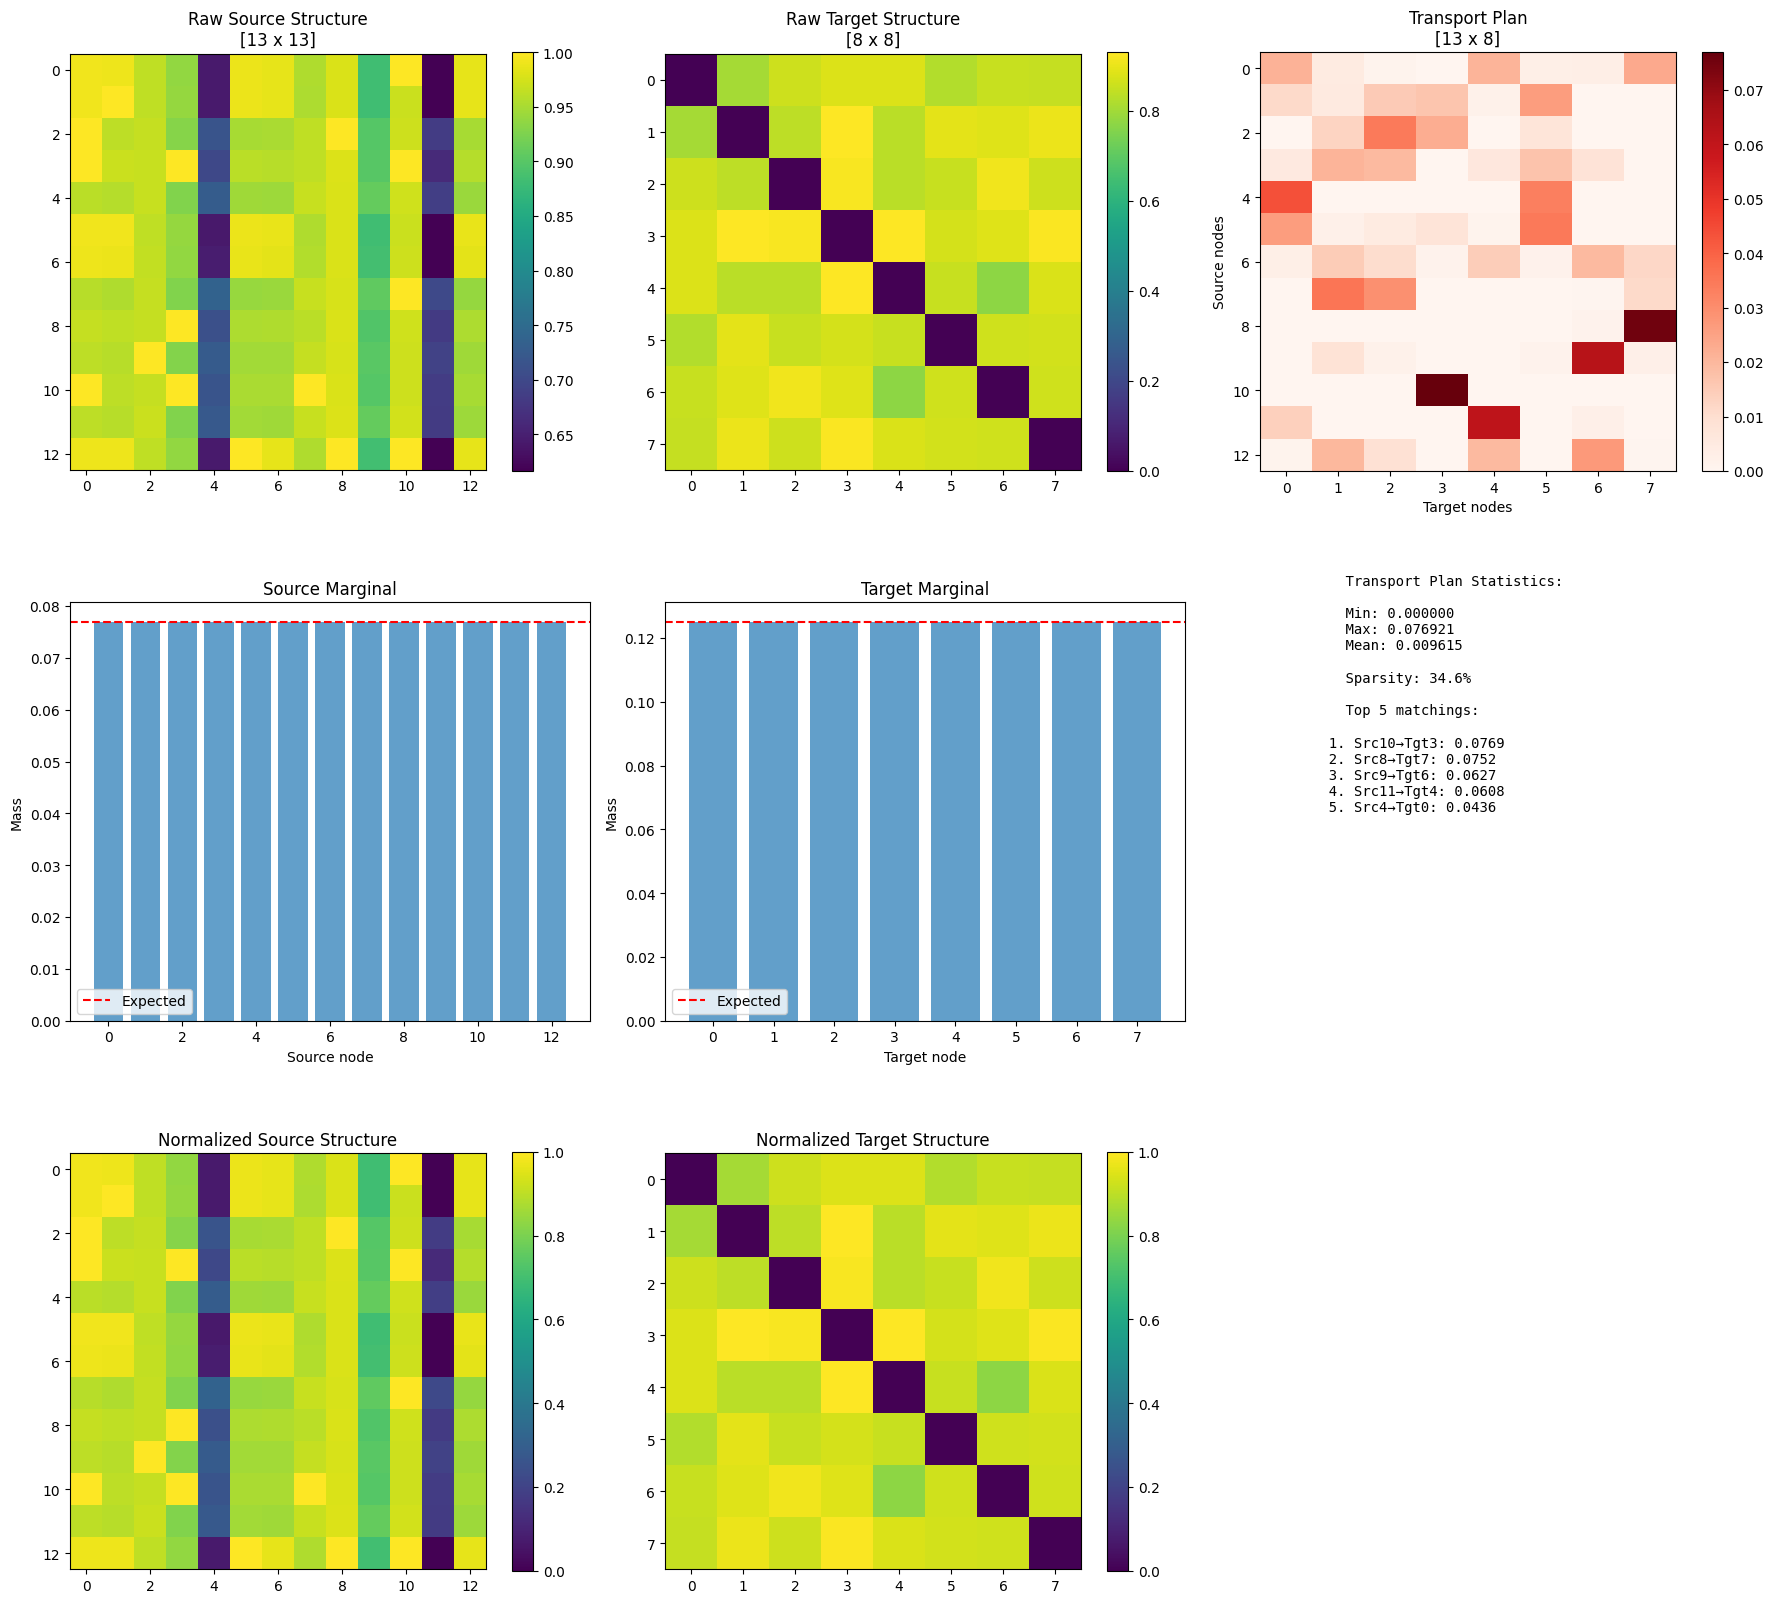

✅ Visualization saved!


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from ot.batch import solve_gromov_batch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========== 1. Learnable Target Graphs ==========
class LearnableGraphs(nn.Module):
    def __init__(self, M=8, K=8, D=768):
        """
        M: number of graphs
        K: number of nodes per graph
        D: dimension of node embeddings
        """
        super().__init__()
        self.M = M
        self.K = K
        self.D = D
        
        # 먼저 Parameter로 placeholder를 만든다
        self.node_embeddings = nn.Parameter(torch.empty(M, K, D))

        # LCG별 mean/std 기반 초기화
        with torch.no_grad():
            means = torch.randn(M, D) * 2.0         # [M, D]
            stds  = torch.rand(M, 1, 1) * 0.5 + 0.5 # [M, 1, 1]

            # 최종 초기화값 계산
            init_values = means.unsqueeze(1) + stds * torch.randn(M, K, D)

            # Parameter에 주입
            self.node_embeddings.data.copy_(init_values)

        # for m in range(M):
        #     # Random direction in high-dimensional space
        #     direction = torch.randn(K, D)
        #     direction = direction / torch.norm(direction, dim=-1, keepdim=True)
            
        #     # Random radius (large range for diversity)
        #     radius = 0.5 + torch.rand(1).item() * 1.5  # [0.5, 2.0] random
            
        #     # Random center shift around sample mean
        #     sample_mean = 0.07
        #     center_shift = (torch.rand(1).item() - 0.5) * 0.5  # [-0.25, 0.25]
        #     center = sample_mean + center_shift
            
        #     self.node_embeddings.data[m] = direction * radius + center

    def compute_structure(self):
        """
        Compute structure using 1 - cosine similarity
        Returns: [M, K, K]
        """
        # Normalize embeddings
        U_norm = F.normalize(self.node_embeddings, p=2, dim=-1)  # [M, K, D]
        
        # Cosine similarity
        cosine_sim = torch.einsum("mkd,mjd->mkj", U_norm, U_norm)  # [M, K, K]
        
        # Distance = 1 - cosine similarity
        distance = 1.0 - cosine_sim
        distance = distance.clamp_min(0.0)
        
        return distance
    
    def orthogonal_loss(self):
        """
        Encourage different graphs to use different subspaces
        Returns: scalar loss
        """
        # Flatten each graph: [M, K, D] -> [M, K*D]
        flat = self.node_embeddings.view(self.M, -1)  # [M, K*D]
        
        # Normalize to unit norm (compare direction only)
        flat_norm = F.normalize(flat, p=2, dim=1)  # [M, K*D]
        
        # Compute Gram matrix (cosine similarity)
        gram = torch.matmul(flat_norm, flat_norm.T)  # [M, M] ∈ [-1, 1]
        
        # Remove diagonal (self-similarity = 1)
        gram = gram - torch.eye(self.M, device=gram.device)
        
        # Minimize off-diagonal elements (make graphs orthogonal)
        # Average over M*(M-1) off-diagonal elements
        return (gram ** 2).sum() / (self.M * (self.M - 1))
    
    def forward(self):
        """
        Returns:
            features: [M, K, D]
            structure: [M, K, K]
        """
        structure = self.compute_structure()
        structure = (structure - structure.min()) / (structure.max() - structure.min() + 1e-8)
        return self.node_embeddings, structure


# ========== 2. Extract Source Graph from Model ==========
def extract_source_graph(model, batch):
    """
    Extract node embeddings and attention from model
    
    Returns:
        features: [B, N, D]
        structure: [B, N, N]
    """
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    
    # Gather embeddings
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])
    
    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)
    
    # Forward through basis layers
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)
    last_att = None
    
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
        last_att = att
    
    # Extract without CLS
    features = x_basis[:, 1:, :]  # [B, N, D]
    
    # Attention distance (1 - attention)
    if last_att is not None:
        attention = last_att[:, :, 1:, 1:]  # [B, H, N, N]
        attention = attention.squeeze(1)     # [B, N, N] (H=1)
        structure = 1.0 - attention
        structure = structure.clamp_min(0.0)
    else:
        raise ValueError("No attention found!")
    
    return features, structure


# ========== 3. Compute FGW using POT ==========
def compute_batch_fgw(source_features, source_structure, target_features, target_structure, alpha=0.5, reg=0.01):
    """
    Compute Fused Gromov-Wasserstein distance using POT
    
    Args:
        source_features: [B, N, D_source]
        source_structure: [B, N, N]
        target_features: [M, K, D_target]
        target_structure: [M, K, K]
    
    Returns:
        result: OTResult object
    """
    B, N, D_source = source_features.shape
    M, K, D_target = target_features.shape
    
    # Expand source for all target graphs
    # [B, N, D] -> [B*M, N, D]
    source_features_exp = source_features.unsqueeze(1).expand(B, M, N, D_source).reshape(B*M, N, D_source)
    source_structure_exp = source_structure.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
    
    # Expand target for all source samples
    # [M, K, D] -> [B*M, K, D]
    target_features_exp = target_features.unsqueeze(0).expand(B, M, K, D_target).reshape(B*M, K, D_target)
    target_structure_exp = target_structure.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
    
    # Compute feature cost (squared Euclidean distance)
    # [B*M, N, K]
    M_cost = torch.cdist(source_features_exp, target_features_exp, p=2) ** 2
    # Normalize by dimension
    #M_cost = M_cost / D_source
    # Min-max normalize to [0, 1] for fair comparison with structure cost
    M_cost = (M_cost - M_cost.min()) / (M_cost.max() - M_cost.min() + 1e-8)
    
    # Uniform distributions
    a = torch.ones(B*M, N, device=device) / N
    b = torch.ones(B*M, K, device=device) / K
    
    # Solve FGW
    result = solve_gromov_batch(
        source_structure_exp,  # C1: [B*M, N, N]
        target_structure_exp,  # C2: [B*M, K, K]
        M=M_cost,              # Feature cost: [B*M, N, K]
        alpha=alpha,           # Balance between feature and structure
        reg=reg,               # Entropic regularization
        a=a,
        b=b,
        max_iter=50
    )
    
    # Reshape result back to [B, M]
    fgw_values = result.value.reshape(B, M)
    
    # Get feature and structure costs separately
    feature_costs = result.value_linear.reshape(B, M) if hasattr(result, 'value_linear') else None
    structure_costs = result.value_quad.reshape(B, M) if hasattr(result, 'value_quad') else None
    
    # Transport plans: [B*M, N, K] -> [B, M, N, K]
    transport_plans = result.plan.reshape(B, M, N, K)
    
    return result, fgw_values, feature_costs, structure_costs, transport_plans


# ========== 4. Main Training Loop ==========
def train_with_pot_fgw(model, dataloader, learnable_graphs, optimizer, alpha=0.5, reg=0.01):
    """
    Train using POT batch FGW
    """
    model.train()
    learnable_graphs.train()
    
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, batch in enumerate(dataloader):
        # Extract source graph from model
        source_features, source_structure = extract_source_graph(model, batch)
        
        # Get target graphs
        target_features, target_structure = learnable_graphs()
        
        # Compute FGW
        result, fgw_values, feature_costs, structure_costs, transport_plans = compute_batch_fgw(
            source_features, source_structure,
            target_features, target_structure,
            alpha=alpha, reg=reg
        )
        
        # Loss: mean FGW distance + orthogonal regularization
        
        fgw_loss = fgw_values.mean()
        orth_loss = learnable_graphs.orthogonal_loss()
        
        loss = fgw_loss + orth_loss  # Lambda = 0.1
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
        
        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item():.4f} (FGW: {fgw_loss.item():.4f}, Orth: {orth_loss.item():.4f})")
            print(f"  Total FGW (first sample): {fgw_values[0].detach().cpu().numpy()}")
            
            if feature_costs is not None:
                print(f"  Feature cost (first sample): {feature_costs[0].detach().cpu().numpy()}")
            if structure_costs is not None:
                print(f"  Structure cost (first sample): {structure_costs[0].detach().cpu().numpy()}")
    
    avg_loss = total_loss / num_batches
    return avg_loss, transport_plans


# ========== 5. Visualization ==========
def visualize_transport_plan(source_features, target_features, transport_plans, 
                            source_structure, target_structure, 
                            sample_idx=0, graph_idx=0):
    """
    Visualize transport plan + raw/normalized structures
    """
    import matplotlib.pyplot as plt
    
    # Extract for visualization
    T = transport_plans[sample_idx, graph_idx].detach().cpu().numpy()  # [N, K]
    
    # Raw structures
    src_raw = source_structure[sample_idx].detach().cpu().numpy()
    tgt_raw = target_structure[graph_idx].detach().cpu().numpy()
    
    # Normalized structures (min-max per matrix)
    src_norm = (src_raw - src_raw.min()) / (src_raw.max() - src_raw.min() + 1e-8)
    tgt_norm = (tgt_raw - tgt_raw.min()) / (tgt_raw.max() - tgt_raw.min() + 1e-8)
    
    # 8 plots: raw src, raw tgt, T, marginals, stats, norm src, norm tgt
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    
    # 1. Raw Source structure
    ax = axes[0, 0]
    im = ax.imshow(src_raw, cmap='viridis')
    ax.set_title(f'Raw Source Structure\n[{src_raw.shape[0]} x {src_raw.shape[0]}]')
    plt.colorbar(im, ax=ax)
    
    # 2. Raw Target structure
    ax = axes[0, 1]
    im = ax.imshow(tgt_raw, cmap='viridis')
    ax.set_title(f'Raw Target Structure\n[{tgt_raw.shape[0]} x {tgt_raw.shape[0]}]')
    plt.colorbar(im, ax=ax)

    # 3. Transport Plan
    ax = axes[0, 2]
    im = ax.imshow(T, cmap='Reds', aspect='auto')
    ax.set_title(f'Transport Plan\n[{T.shape[0]} x {T.shape[1]}]')
    ax.set_xlabel('Target nodes')
    ax.set_ylabel('Source nodes')
    plt.colorbar(im, ax=ax)
    
    # 4. Source marginal
    ax = axes[1, 0]
    source_marginal = T.sum(axis=1)
    ax.bar(range(len(source_marginal)), source_marginal, alpha=0.7)
    ax.axhline(1/len(source_marginal), color='r', linestyle='--', label='Expected')
    ax.set_title('Source Marginal')
    ax.set_xlabel('Source node')
    ax.set_ylabel('Mass')
    ax.legend()
    
    # 5. Target marginal
    ax = axes[1, 1]
    target_marginal = T.sum(axis=0)
    ax.bar(range(len(target_marginal)), target_marginal, alpha=0.7)
    ax.axhline(1/len(target_marginal), color='r', linestyle='--', label='Expected')
    ax.set_title('Target Marginal')
    ax.set_xlabel('Target node')
    ax.set_ylabel('Mass')
    ax.legend()
    
    # 6. Stats
    ax = axes[1, 2]
    ax.axis('off')
    stats_text = f"""
    Transport Plan Statistics:
    
    Min: {T.min():.6f}
    Max: {T.max():.6f}
    Mean: {T.mean():.6f}
    
    Sparsity: {(T < 1e-4).sum() / T.size * 100:.1f}%
    
    Top 5 matchings:
    """
    flat_idx = np.argsort(T.flatten())[-5:][::-1]
    for rank, flat_i in enumerate(flat_idx, 1):
        i, j = np.unravel_index(flat_i, T.shape)
        stats_text += f"\n  {rank}. Src{i}→Tgt{j}: {T[i,j]:.4f}"
    ax.text(0.1, 0.5, stats_text, fontsize=10, family='monospace')
    
    # 7. Normalized Source Structure
    ax = axes[2, 0]
    im = ax.imshow(src_norm, cmap='viridis')
    ax.set_title(f'Normalized Source Structure')
    plt.colorbar(im, ax=ax)
    
    # 8. Normalized Target Structure
    ax = axes[2, 1]
    im = ax.imshow(tgt_norm, cmap='viridis')
    ax.set_title(f'Normalized Target Structure')
    plt.colorbar(im, ax=ax)

    # 9. Empty for layout
    axes[2, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Visualization saved!")


# ========== 6. Main Experiment ==========
if __name__ == "__main__":
    # Get D from model
    D = model.input_dim  # Assuming model is already loaded
    
    # Initialize learnable graphs
    learnable_graphs = LearnableGraphs(M=8, K=8, D=D).to(device)
    
    # Optimizer (only for learnable graphs)
    optimizer = torch.optim.Adam(learnable_graphs.parameters(), lr=1e-3)
    
    # Get first source dataloader
    first_source = list(loaders.keys())[0]
    dataloader = loaders[first_source]
    
    print(f"Training with source: {first_source}")
    print(f"Model input_dim: {D}")
    print(f"Learnable graphs: M={learnable_graphs.M}, K={learnable_graphs.K}, D={learnable_graphs.D}")
    
    # Train for a few batches
    num_batches_to_train = 50
    from itertools import islice
    
    final_transport_plans = None
    for epoch in range(1, 4):
        print(f"\n===== Epoch {epoch} =====")
        limited_loader = islice(dataloader, num_batches_to_train)
        avg_loss, transport_plans = train_with_pot_fgw(
            model, limited_loader, learnable_graphs, optimizer,
            alpha=0.5, reg=0.01
        )
        print(f"Epoch {epoch} - Average Loss: {avg_loss:.4f}")
        final_transport_plans = transport_plans
    
    print("\n✅ Training completed!")
    
    # Visualize final transport plan
    print("\n📊 Creating visualization...")
    
    # Get one batch for visualization
    dataloader_viz = iter(loaders[first_source])
    batch_viz = next(dataloader_viz)
    source_features, source_structure = extract_source_graph(model, batch_viz)
    target_features, target_structure = learnable_graphs()
    
    _, fgw_values, _, _, transport_plans_viz = compute_batch_fgw(
        source_features, source_structure,
        target_features, target_structure,
        alpha=0.5, reg=0.01
    )
    
    B = source_features.shape[0]

    num_samples_to_visualize = 5   # 원하는 만큼

    B = source_features.shape[0]
    num_samples_to_visualize = min(num_samples_to_visualize, B)

    for sample_idx in range(num_samples_to_visualize):

        # 그냥 동일 인덱스로 graph 선택 (closest 안 씀)
        graph_idx = sample_idx % target_features.shape[0]   # target_graph 개수 초과 방지

        print(f"\nVisualizing Sample {sample_idx} with Graph {graph_idx}")

        visualize_transport_plan(
            source_features, target_features, transport_plans_viz,
            source_structure, target_structure,
            sample_idx=sample_idx,
            graph_idx=graph_idx
        )

Analyzing embedding distributions...
EMBEDDING DISTRIBUTION ANALYSIS

Sample Embeddings: (3510, 768)
  Mean: 0.0714
  Std:  0.5433
  Min:  -393.1307
  Max:  459.2849

LCG Embeddings: (64, 768)
  Graph 0 - Mean: -0.0016, Std: 2.1868
  Graph 1 - Mean: 0.0719, Std: 2.0724
  Graph 2 - Mean: 0.0621, Std: 2.2424
  Graph 3 - Mean: 0.0657, Std: 2.1318
  Graph 4 - Mean: -0.1067, Std: 2.2153
  Graph 5 - Mean: 0.0334, Std: 2.2362
  Graph 6 - Mean: 0.1183, Std: 2.1687
  Graph 7 - Mean: -0.0589, Std: 2.1375


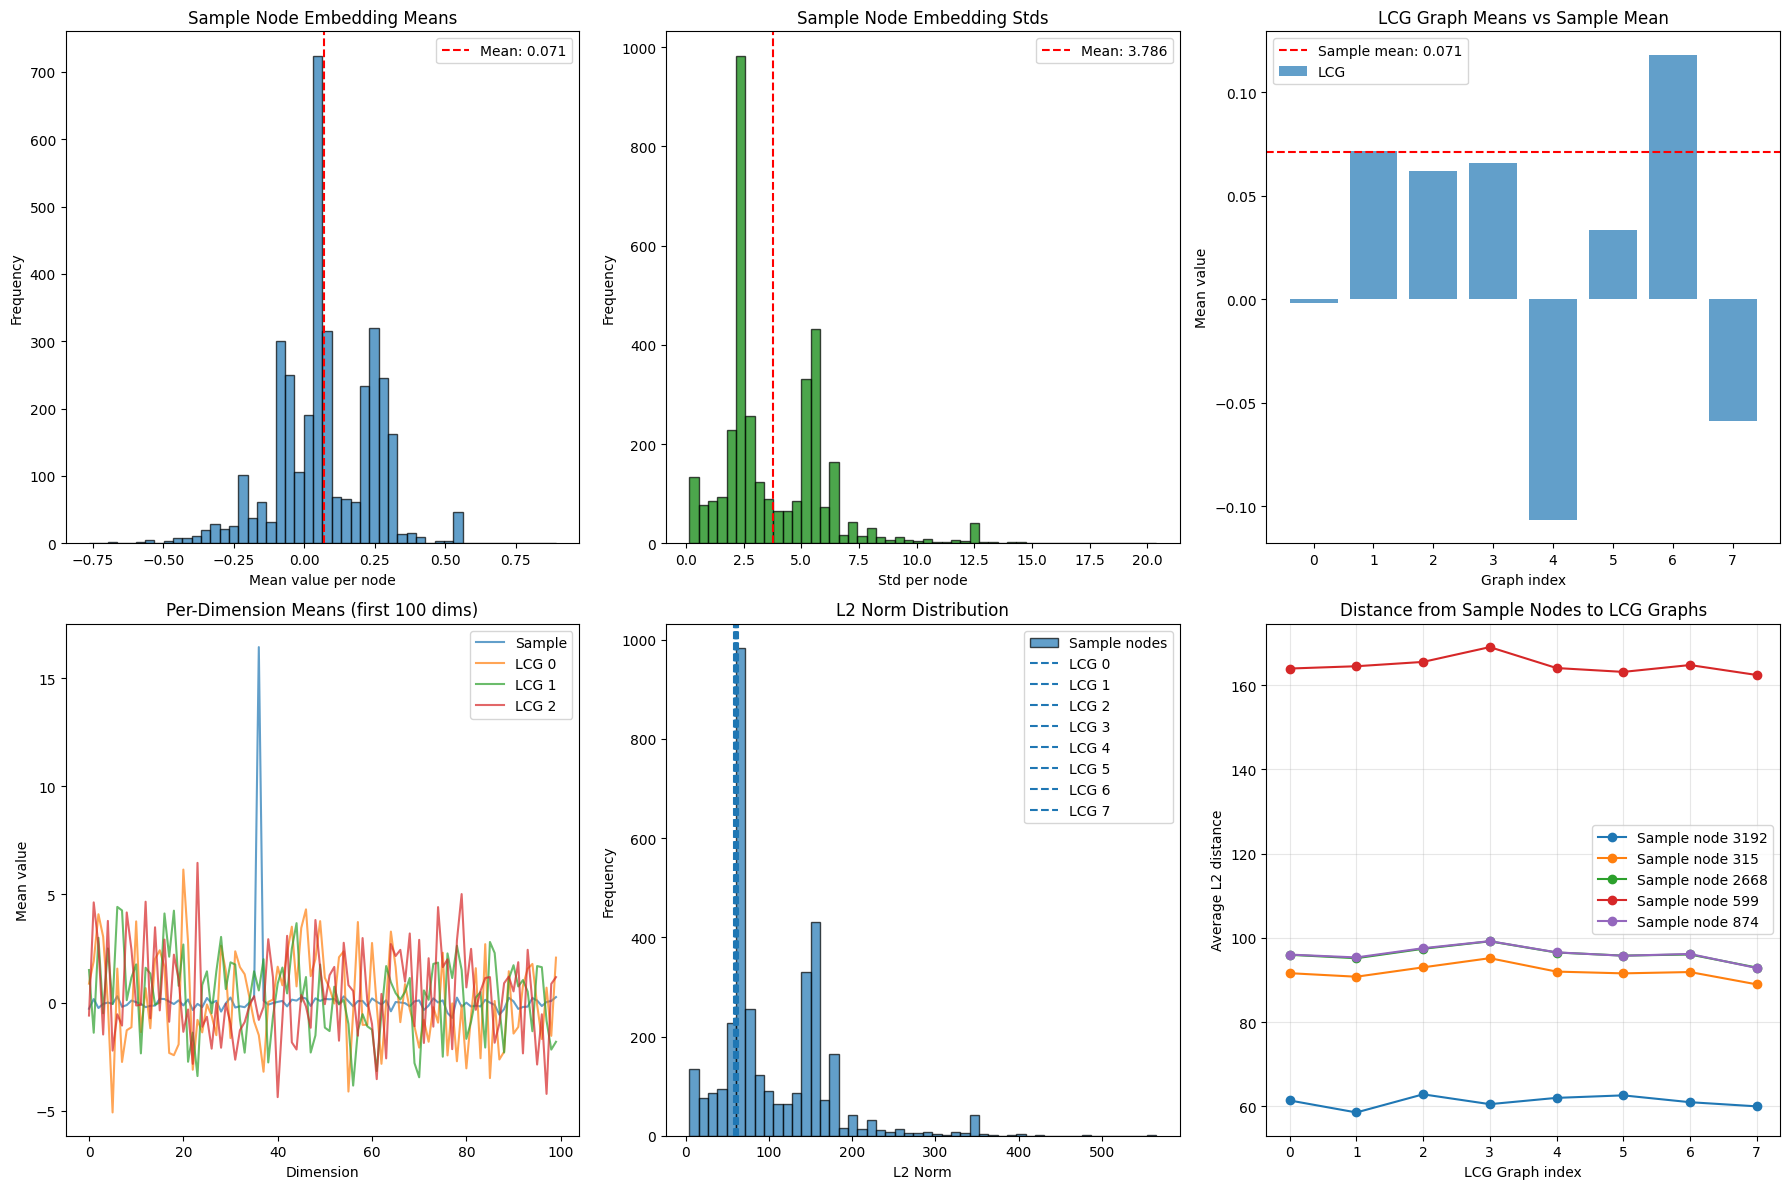


✅ Analysis complete! Plot saved.

Computing LCG selection frequencies...


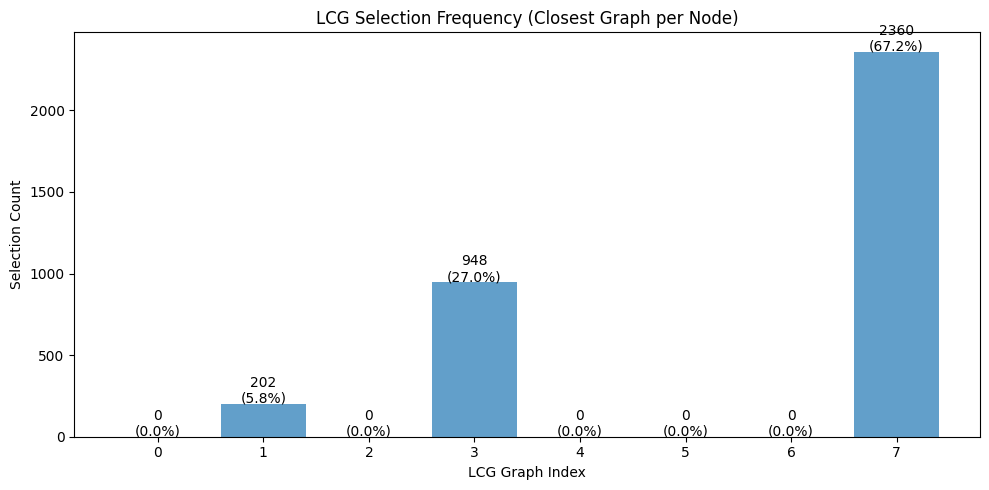

LCG selection frequencies: [   0.  202.    0.  948.    0.    0.    0. 2360.]


In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def analyze_embedding_distributions(model, dataloader, learnable_graphs, num_samples=100):
    """
    Analyze distribution of sample embeddings vs LCG embeddings
    """
    model.eval()
    learnable_graphs.eval()
    
    all_sample_embeddings = []
    
    # Collect sample embeddings
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_samples:
                break
            
            # Extract source features
            features, _ = extract_source_graph(model, batch)
            # features: [B, N, D]
            
            # Flatten: [B, N, D] -> [B*N, D]
            features_flat = features.reshape(-1, features.shape[-1])
            all_sample_embeddings.append(features_flat)
    
    # Concatenate all
    sample_embs = torch.cat(all_sample_embeddings, dim=0).cpu().numpy()  # [Total, D]
    
    # Get LCG embeddings
    lcg_embs = learnable_graphs.node_embeddings.detach().cpu().numpy()  # [M, K, D]
    lcg_embs_flat = lcg_embs.reshape(-1, lcg_embs.shape[-1])  # [M*K, D]
    
    # Statistics
    print("=" * 60)
    print("EMBEDDING DISTRIBUTION ANALYSIS")
    print("=" * 60)
    
    print(f"\nSample Embeddings: {sample_embs.shape}")
    print(f"  Mean: {sample_embs.mean(axis=0).mean():.4f}")
    print(f"  Std:  {sample_embs.std(axis=0).mean():.4f}")
    print(f"  Min:  {sample_embs.min():.4f}")
    print(f"  Max:  {sample_embs.max():.4f}")
    
    print(f"\nLCG Embeddings: {lcg_embs_flat.shape}")
    for m in range(learnable_graphs.M):
        emb_m = lcg_embs[m].reshape(-1)
        print(f"  Graph {m} - Mean: {emb_m.mean():.4f}, Std: {emb_m.std():.4f}")
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Sample embedding mean distribution
    ax = axes[0, 0]
    sample_means = sample_embs.mean(axis=1)
    ax.hist(sample_means, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(sample_means.mean(), color='r', linestyle='--', 
               label=f'Mean: {sample_means.mean():.3f}')
    ax.set_title('Sample Node Embedding Means')
    ax.set_xlabel('Mean value per node')
    ax.set_ylabel('Frequency')
    ax.legend()
    
    # 2. Sample embedding std distribution
    ax = axes[0, 1]
    sample_stds = sample_embs.std(axis=1)
    ax.hist(sample_stds, bins=50, alpha=0.7, edgecolor='black', color='green')
    ax.axvline(sample_stds.mean(), color='r', linestyle='--',
               label=f'Mean: {sample_stds.mean():.3f}')
    ax.set_title('Sample Node Embedding Stds')
    ax.set_xlabel('Std per node')
    ax.set_ylabel('Frequency')
    ax.legend()
    
    # 3. Sample vs LCG mean comparison
    ax = axes[0, 2]
    lcg_means = [lcg_embs[m].mean() for m in range(learnable_graphs.M)]
    ax.bar(range(learnable_graphs.M), lcg_means, alpha=0.7, label='LCG')
    ax.axhline(sample_means.mean(), color='r', linestyle='--', 
               label=f'Sample mean: {sample_means.mean():.3f}')
    ax.set_title('LCG Graph Means vs Sample Mean')
    ax.set_xlabel('Graph index')
    ax.set_ylabel('Mean value')
    ax.legend()
    
    # 4. Per-dimension mean (first 100 dims)
    ax = axes[1, 0]
    dims_to_plot = min(100, sample_embs.shape[1])
    ax.plot(sample_embs.mean(axis=0)[:dims_to_plot], label='Sample', alpha=0.7)
    for m in range(min(3, learnable_graphs.M)):  # First 3 graphs
        ax.plot(lcg_embs[m].mean(axis=0)[:dims_to_plot], 
                label=f'LCG {m}', alpha=0.7)
    ax.set_title(f'Per-Dimension Means (first {dims_to_plot} dims)')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Mean value')
    ax.legend()
    
    # 5. Norm distribution
    ax = axes[1, 1]
    sample_norms = np.linalg.norm(sample_embs, axis=1)
    lcg_norms = [np.linalg.norm(lcg_embs[m], axis=1).mean() 
                 for m in range(learnable_graphs.M)]
    
    ax.hist(sample_norms, bins=50, alpha=0.7, label='Sample nodes', edgecolor='black')
    for m in range(learnable_graphs.M):
        ax.axvline(lcg_norms[m], linestyle='--', label=f'LCG {m}')
    ax.set_title('L2 Norm Distribution')
    ax.set_xlabel('L2 Norm')
    ax.set_ylabel('Frequency')
    ax.legend()
    
    # 6. Distance to each LCG graph
    ax = axes[1, 2]
    
    # Sample a few sample nodes
    n_samples_to_plot = min(5, sample_embs.shape[0])
    sample_indices = np.random.choice(sample_embs.shape[0], n_samples_to_plot, replace=False)
    
    distances = []
    for idx in sample_indices:
        sample_node = sample_embs[idx]
        dists = []
        for m in range(learnable_graphs.M):
            # Distance to graph m (mean distance to all nodes in graph m)
            graph_nodes = lcg_embs[m]  # [K, D]
            dist = np.mean([np.linalg.norm(sample_node - graph_nodes[k]) 
                           for k in range(learnable_graphs.K)])
            dists.append(dist)
        distances.append(dists)
    
    for i, dists in enumerate(distances):
        ax.plot(range(learnable_graphs.M), dists, marker='o', 
                label=f'Sample node {sample_indices[i]}')
    
    ax.set_title('Distance from Sample Nodes to LCG Graphs')
    ax.set_xlabel('LCG Graph index')
    ax.set_ylabel('Average L2 distance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()

    plt.show()
    
    print("\n✅ Analysis complete! Plot saved.")
     # =====================================================================
    # 7. Which LCGs are selected more?  (Based on nearest graph per node)
    # =====================================================================

    print("\nComputing LCG selection frequencies...")

    lcg_selection_counts = np.zeros(learnable_graphs.M)

    # For each sample embedding, find the closest LCG (mean L2 distance)
    for i in range(sample_embs.shape[0]):
        node = sample_embs[i]   # [D]
        dists = []
        for m in range(learnable_graphs.M):
            graph_nodes = lcg_embs[m]  # [K, D]
            dist = np.mean(np.linalg.norm(graph_nodes - node, axis=1))
            dists.append(dist)
        closest = np.argmin(dists)
        lcg_selection_counts[closest] += 1

    # Normalize counts to percentage
    lcg_selection_percent = lcg_selection_counts / lcg_selection_counts.sum() * 100

    # Plot bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(range(learnable_graphs.M), lcg_selection_counts, alpha=0.7)
    plt.title("LCG Selection Frequency (Closest Graph per Node)")
    plt.xlabel("LCG Graph Index")
    plt.ylabel("Selection Count")
    for idx, cnt in enumerate(lcg_selection_counts):
        plt.text(idx, cnt + 5, f"{int(cnt)}\n({lcg_selection_percent[idx]:.1f}%)", 
                 ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

    print("LCG selection frequencies:", lcg_selection_counts)
    return {
        'sample_embs': sample_embs,
        'lcg_embs': lcg_embs,
        'sample_means': sample_means,
        'lcg_means': lcg_means
    }


# Run analysis
if __name__ == "__main__":
    print("Analyzing embedding distributions...")
    
    # Get dataloader
    first_source = list(loaders.keys())[0]
    dataloader = loaders[first_source]
    
    results = analyze_embedding_distributions(
        model, dataloader, learnable_graphs, num_samples=50
    )

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch

@torch.no_grad()
def analyze_multi_source_lcg_assignments(model, loaders, learnable_graphs, num_batches=20):

    model.eval()
    learnable_graphs.eval()

    M = learnable_graphs.M      # number of LCG graphs
    K = learnable_graphs.K
    D = learnable_graphs.D

    lcg_embs = learnable_graphs.node_embeddings.detach().cpu().numpy()  # [M, K, D]

    # 결과 저장: source_index × LCG_index matrix
    source_names = list(loaders.keys())
    num_sources = len(source_names)

    assignment_matrix = np.zeros((num_sources, M))

    for si, src_name in enumerate(source_names):
        print(f"\n===== Processing Source: {src_name} =====")

        dataloader = loaders[src_name]
        collected_embs = []

        for bi, batch in enumerate(dataloader):
            if bi >= num_batches:
                break

            features, _ = extract_source_graph(model, batch)  # [B, N, D]
            node_embs = features.reshape(-1, features.shape[-1]).cpu().numpy()
            collected_embs.append(node_embs)

        if len(collected_embs) == 0:
            print(f"No embeddings for source {src_name}, skipping.")
            continue

        sample_embs = np.concatenate(collected_embs, axis=0)
        print(f"Collected {sample_embs.shape[0]} embeddings from {src_name}")

        # 각 sample embedding에 대해 가장 가까운 LCG 선택
        for i in range(sample_embs.shape[0]):
            node = sample_embs[i]
            dists = []

            for m in range(M):
                graph_nodes = lcg_embs[m]  # [K, D]
                dist = np.mean(np.linalg.norm(graph_nodes - node, axis=1))
                dists.append(dist)

            closest = np.argmin(dists)
            assignment_matrix[si, closest] += 1

    # ========== 시각화 (Stacked Bar Plot) ==========
    fig, ax = plt.subplots(figsize=(12, 6))

    # 색상 팔레트
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(num_sources)]

    bottom = np.zeros(M)

    for si in range(num_sources):
        ax.bar(
            np.arange(M),
            assignment_matrix[si],
            bottom=bottom,
            label=source_names[si],
            color=colors[si],
            alpha=0.85
        )
        bottom += assignment_matrix[si]

    ax.set_title("LCG Assignment Counts per Source (Stacked)", fontsize=16)
    ax.set_xlabel("LCG Graph Index", fontsize=13)
    ax.set_ylabel("Assignment Count", fontsize=13)
    ax.legend(title="Sources", fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n===== Multi-source Assignment Matrix =====")
    print(assignment_matrix)

    return assignment_matrix


In [12]:
def train_with_pot_fgw_multi_source(model, loaders, learnable_graphs, optimizer,
                                    alpha=0.5, reg=0.01, batches_per_source=40):

    model.train()
    learnable_graphs.train()

    total_loss, total_batches = 0.0, 0

    for src_name, dataloader in loaders.items():
        print(f"\n====== Training on Source: {src_name} ======")

        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= batches_per_source:
                break

            # 1) Source graph
            source_features, source_structure = extract_source_graph(model, batch)

            # 2) Learnable target graphs
            target_features, target_structure = learnable_graphs()

            # 3) FGW computation
            _, fgw_values, feature_costs, structure_costs, transport_plans = compute_batch_fgw(
                source_features, source_structure,
                target_features, target_structure,
                alpha=alpha, reg=reg
            )

            # 4) Loss
            fgw_loss = fgw_values.mean()
            orth_loss = learnable_graphs.orthogonal_loss()
            loss = fgw_loss + orth_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_batches += 1

            if batch_idx % 10 == 0:
                print(f"[{src_name}] Batch {batch_idx} | "
                      f"Loss={loss.item():.4f} (FGW={fgw_loss.item():.4f}, Orth={orth_loss.item():.4f})")

    return total_loss / total_batches


In [13]:
def visualize_multi_source_alignment(model, loaders, learnable_graphs, alpha=0.5, reg=0.01):

    print("\n===== Multi-Source Visualization =====")

    target_features, target_structure = learnable_graphs()

    for src_name, dataloader in loaders.items():
        print(f"\n>>> Visualization for Source: {src_name}")

        batch = next(iter(dataloader))
        source_features, source_structure = extract_source_graph(model, batch)

        # Compute FGW (no training)
        _, fgw_values, _, _, transport_plans = compute_batch_fgw(
            source_features, source_structure,
            target_features, target_structure,
            alpha=alpha, reg=reg
        )

        B = source_features.shape[0]
        num_samples_to_visualize = min(5, B)

        for sample_idx in range(num_samples_to_visualize):
            graph_idx = sample_idx % target_features.shape[0]

            print(f"  - {src_name} | Sample {sample_idx} → Graph {graph_idx}")

            visualize_transport_plan(
                source_features, target_features, transport_plans,
                source_structure, target_structure,
                sample_idx=sample_idx,
                graph_idx=graph_idx
            )



===== Epoch 1 =====

====== Training on Source: Heart_disease_statlog ======
[Heart_disease_statlog] Batch 0 | Loss=0.2073 (FGW=0.2067, Orth=0.0006)

====== Training on Source: Cardiovascular_Disease_Dataset ======
[Cardiovascular_Disease_Dataset] Batch 0 | Loss=0.2085 (FGW=0.2079, Orth=0.0006)
[Cardiovascular_Disease_Dataset] Batch 10 | Loss=0.2071 (FGW=0.2065, Orth=0.0006)
[Cardiovascular_Disease_Dataset] Batch 20 | Loss=0.1979 (FGW=0.1974, Orth=0.0006)
[Cardiovascular_Disease_Dataset] Batch 30 | Loss=0.1904 (FGW=0.1898, Orth=0.0006)

====== Training on Source: heart_target_3 ======
[heart_target_3] Batch 0 | Loss=0.1934 (FGW=0.1929, Orth=0.0006)
[heart_target_3] Batch 10 | Loss=0.1900 (FGW=0.1894, Orth=0.0006)
[heart_target_3] Batch 20 | Loss=0.1830 (FGW=0.1824, Orth=0.0006)
[heart_target_3] Batch 30 | Loss=0.1764 (FGW=0.1759, Orth=0.0006)

====== Training on Source: heart_target_4 ======
[heart_target_4] Batch 0 | Loss=0.1623 (FGW=0.1618, Orth=0.0006)
[heart_target_4] Batch 10 | L

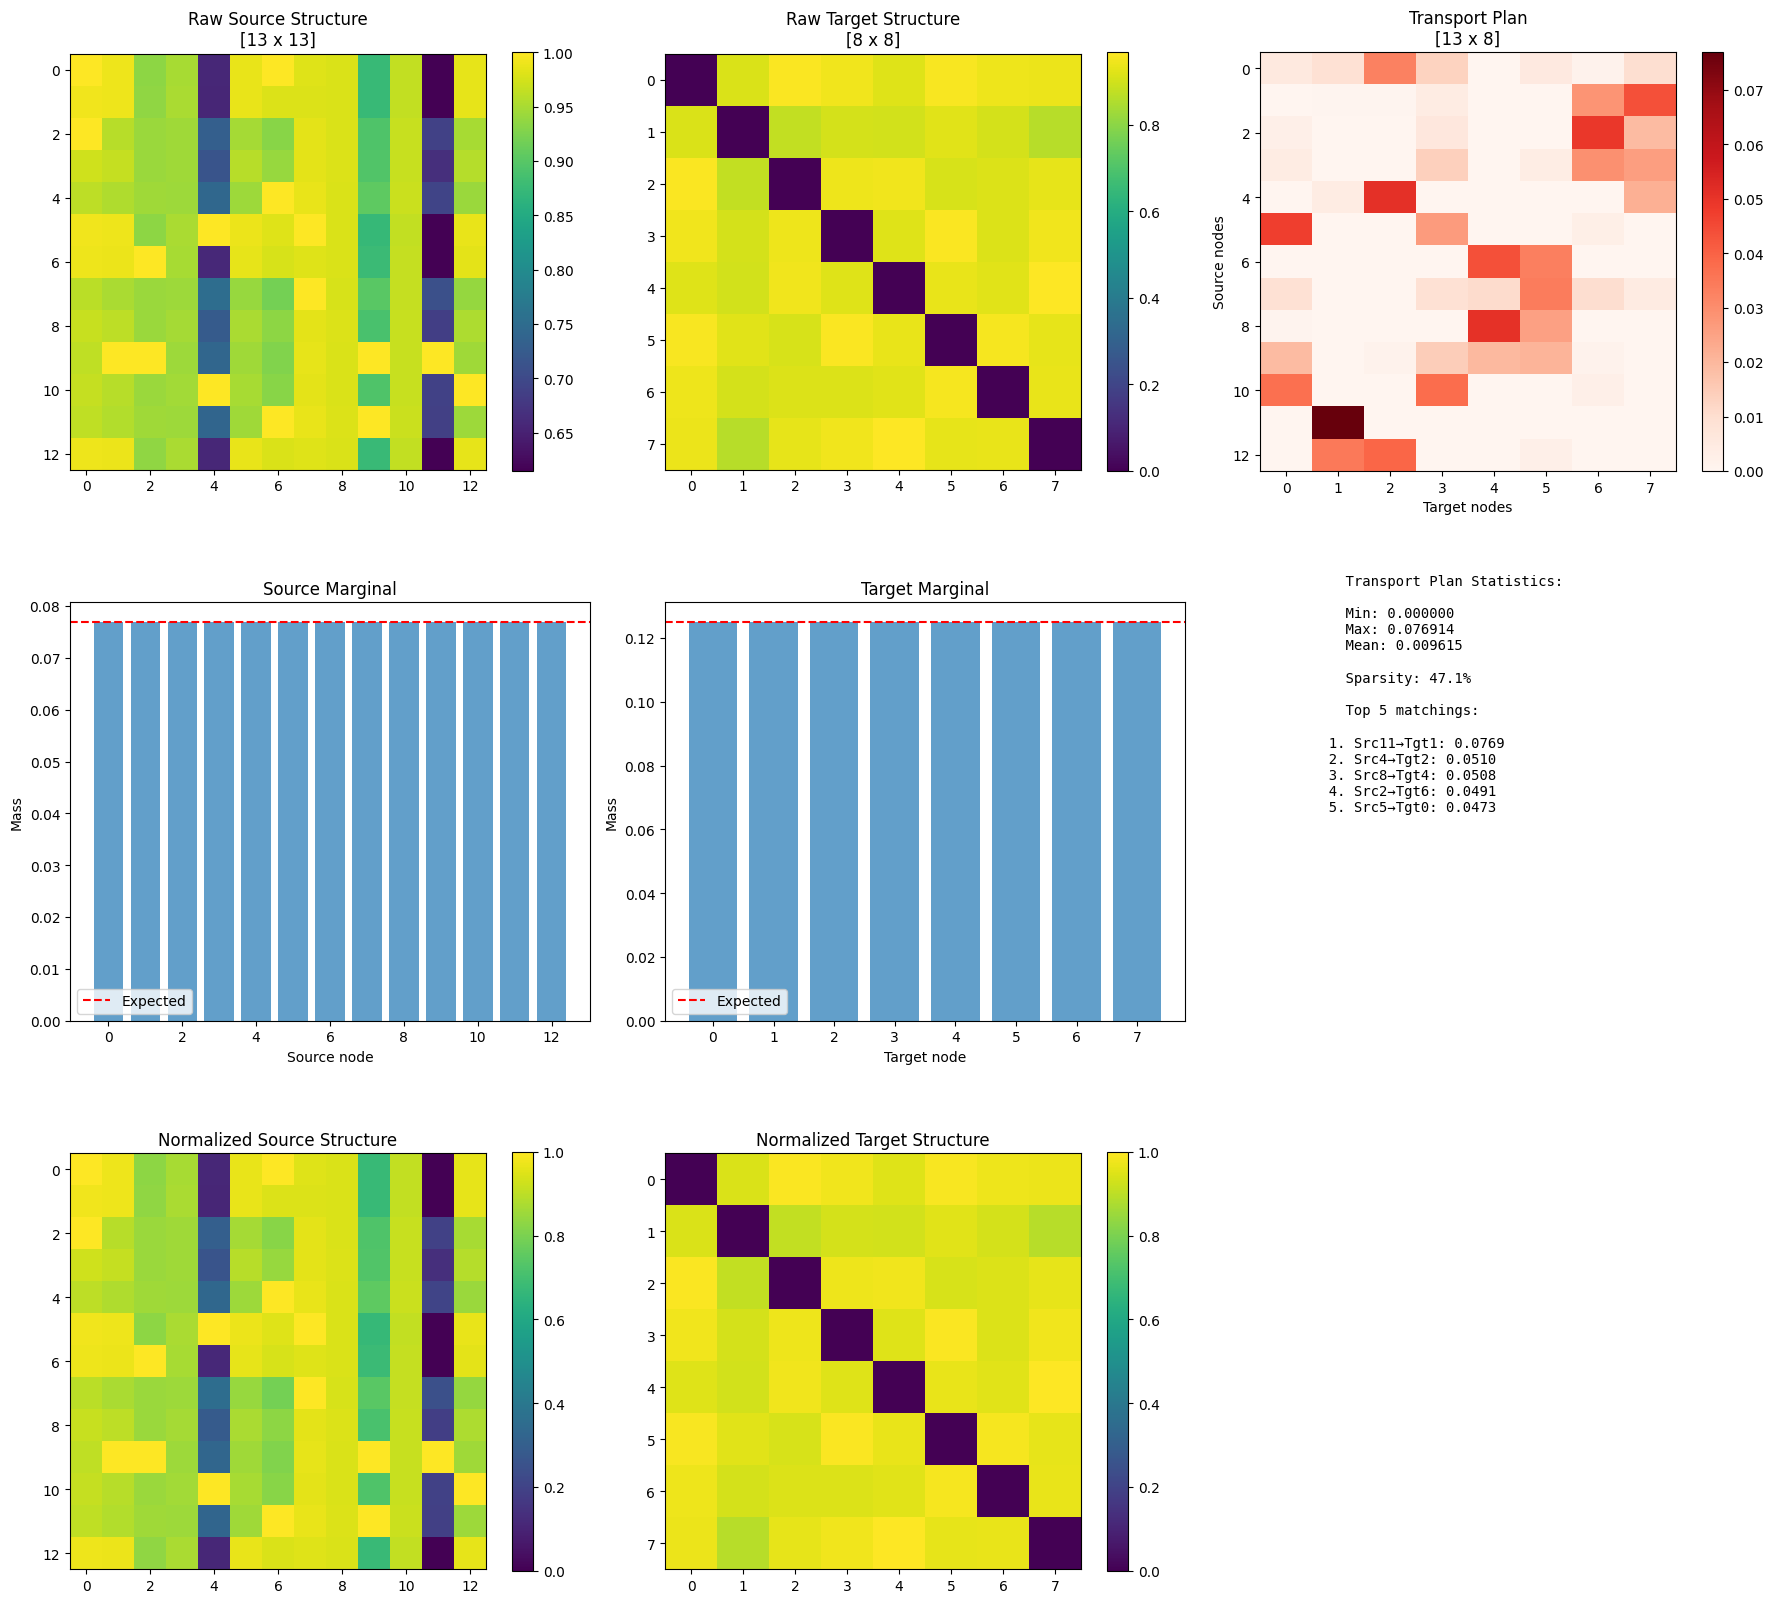

✅ Visualization saved!
  - Heart_disease_statlog | Sample 1 → Graph 1


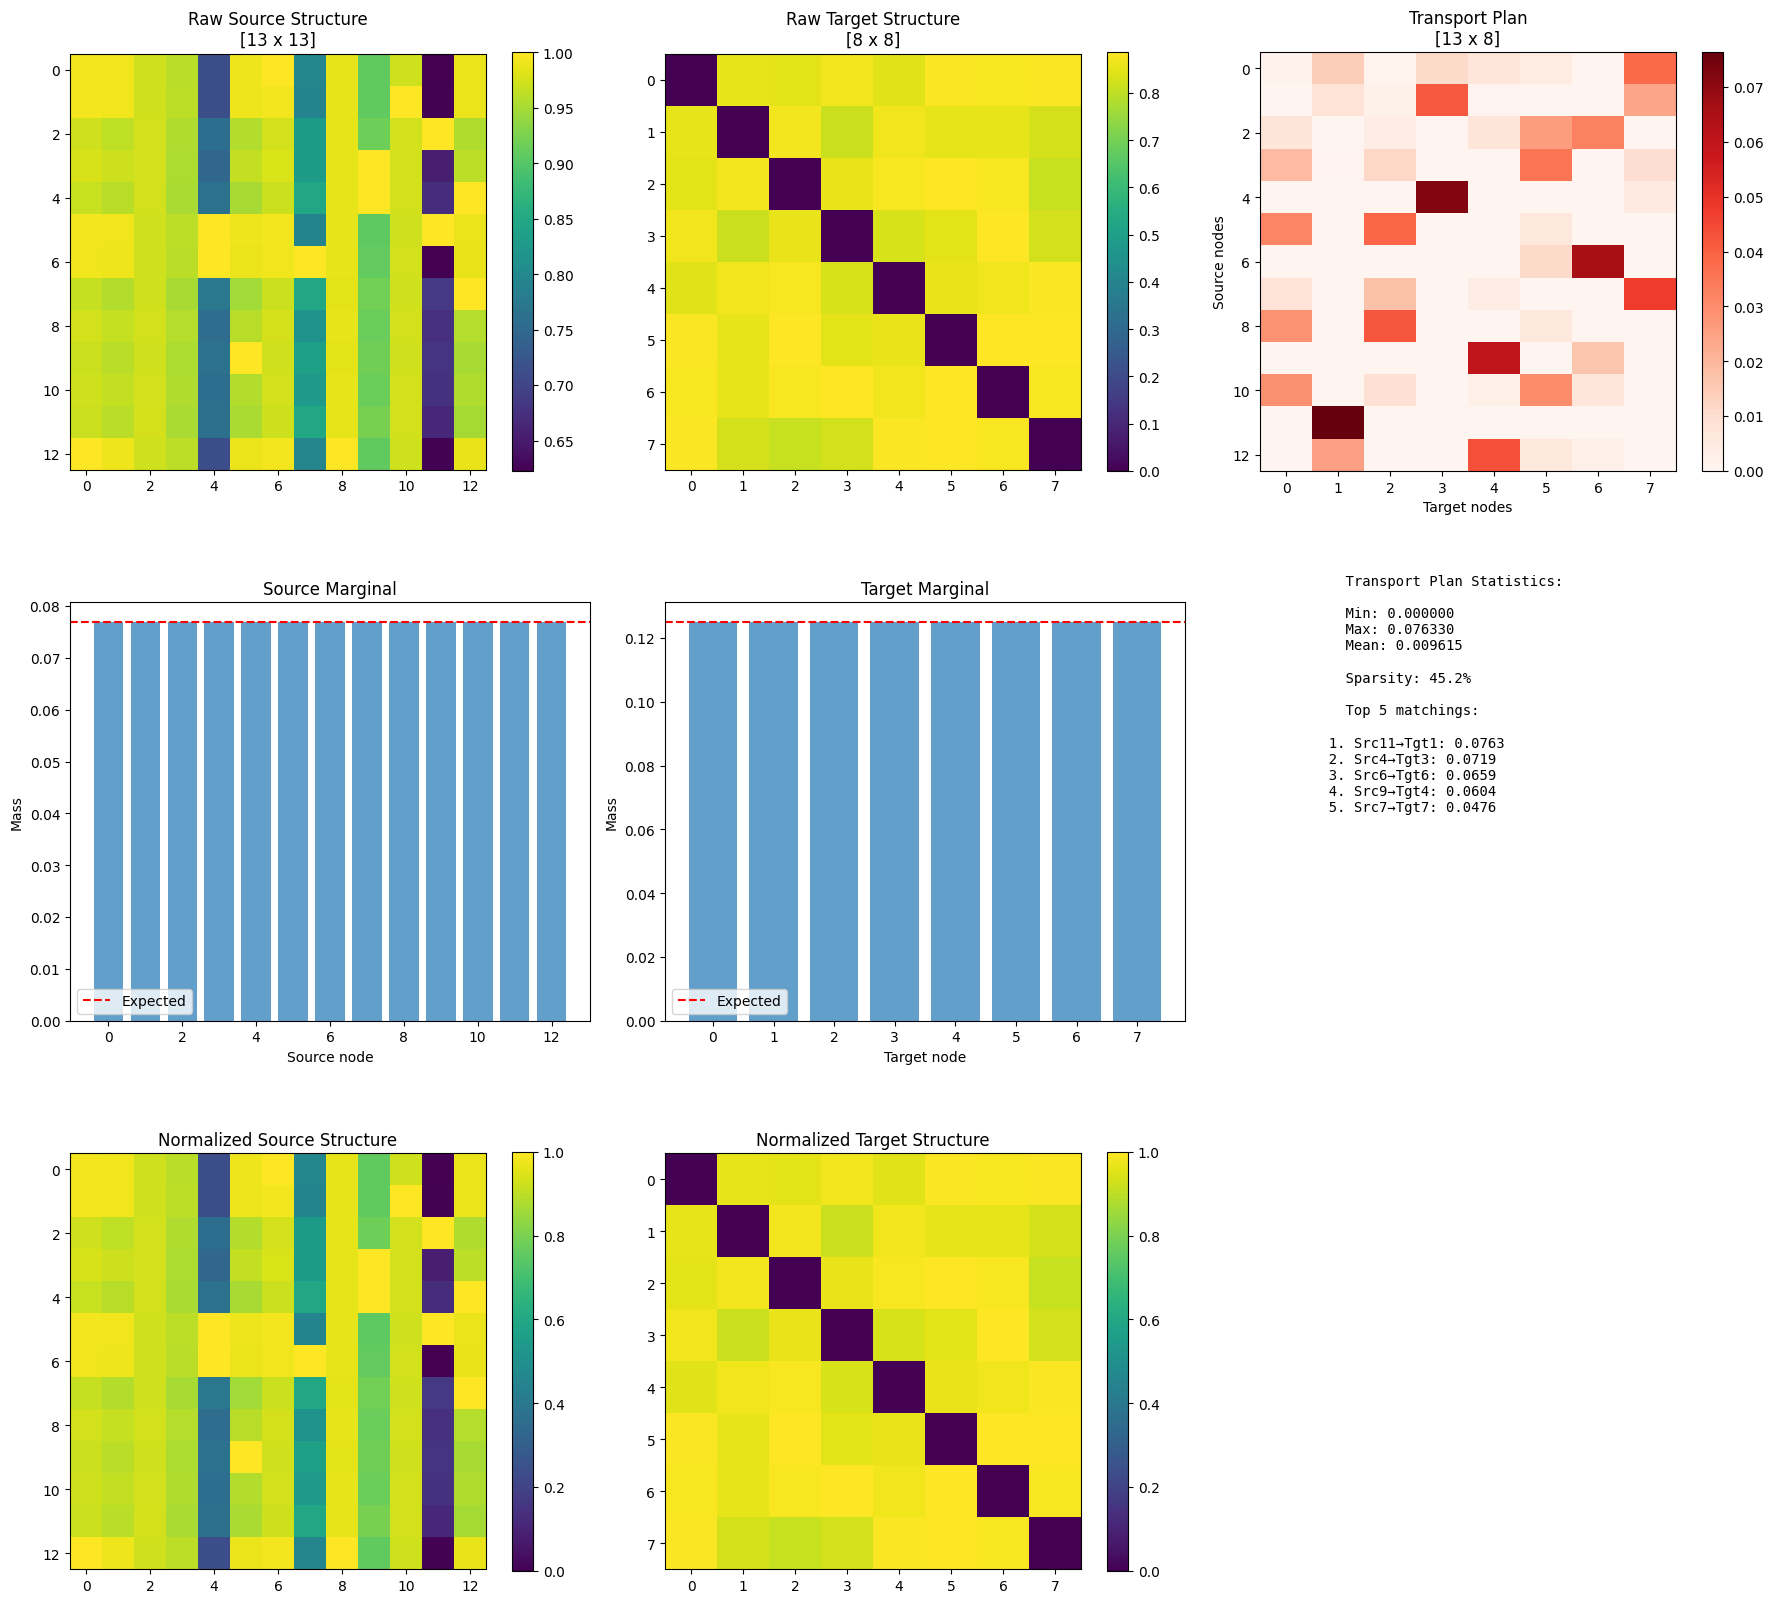

✅ Visualization saved!
  - Heart_disease_statlog | Sample 2 → Graph 2


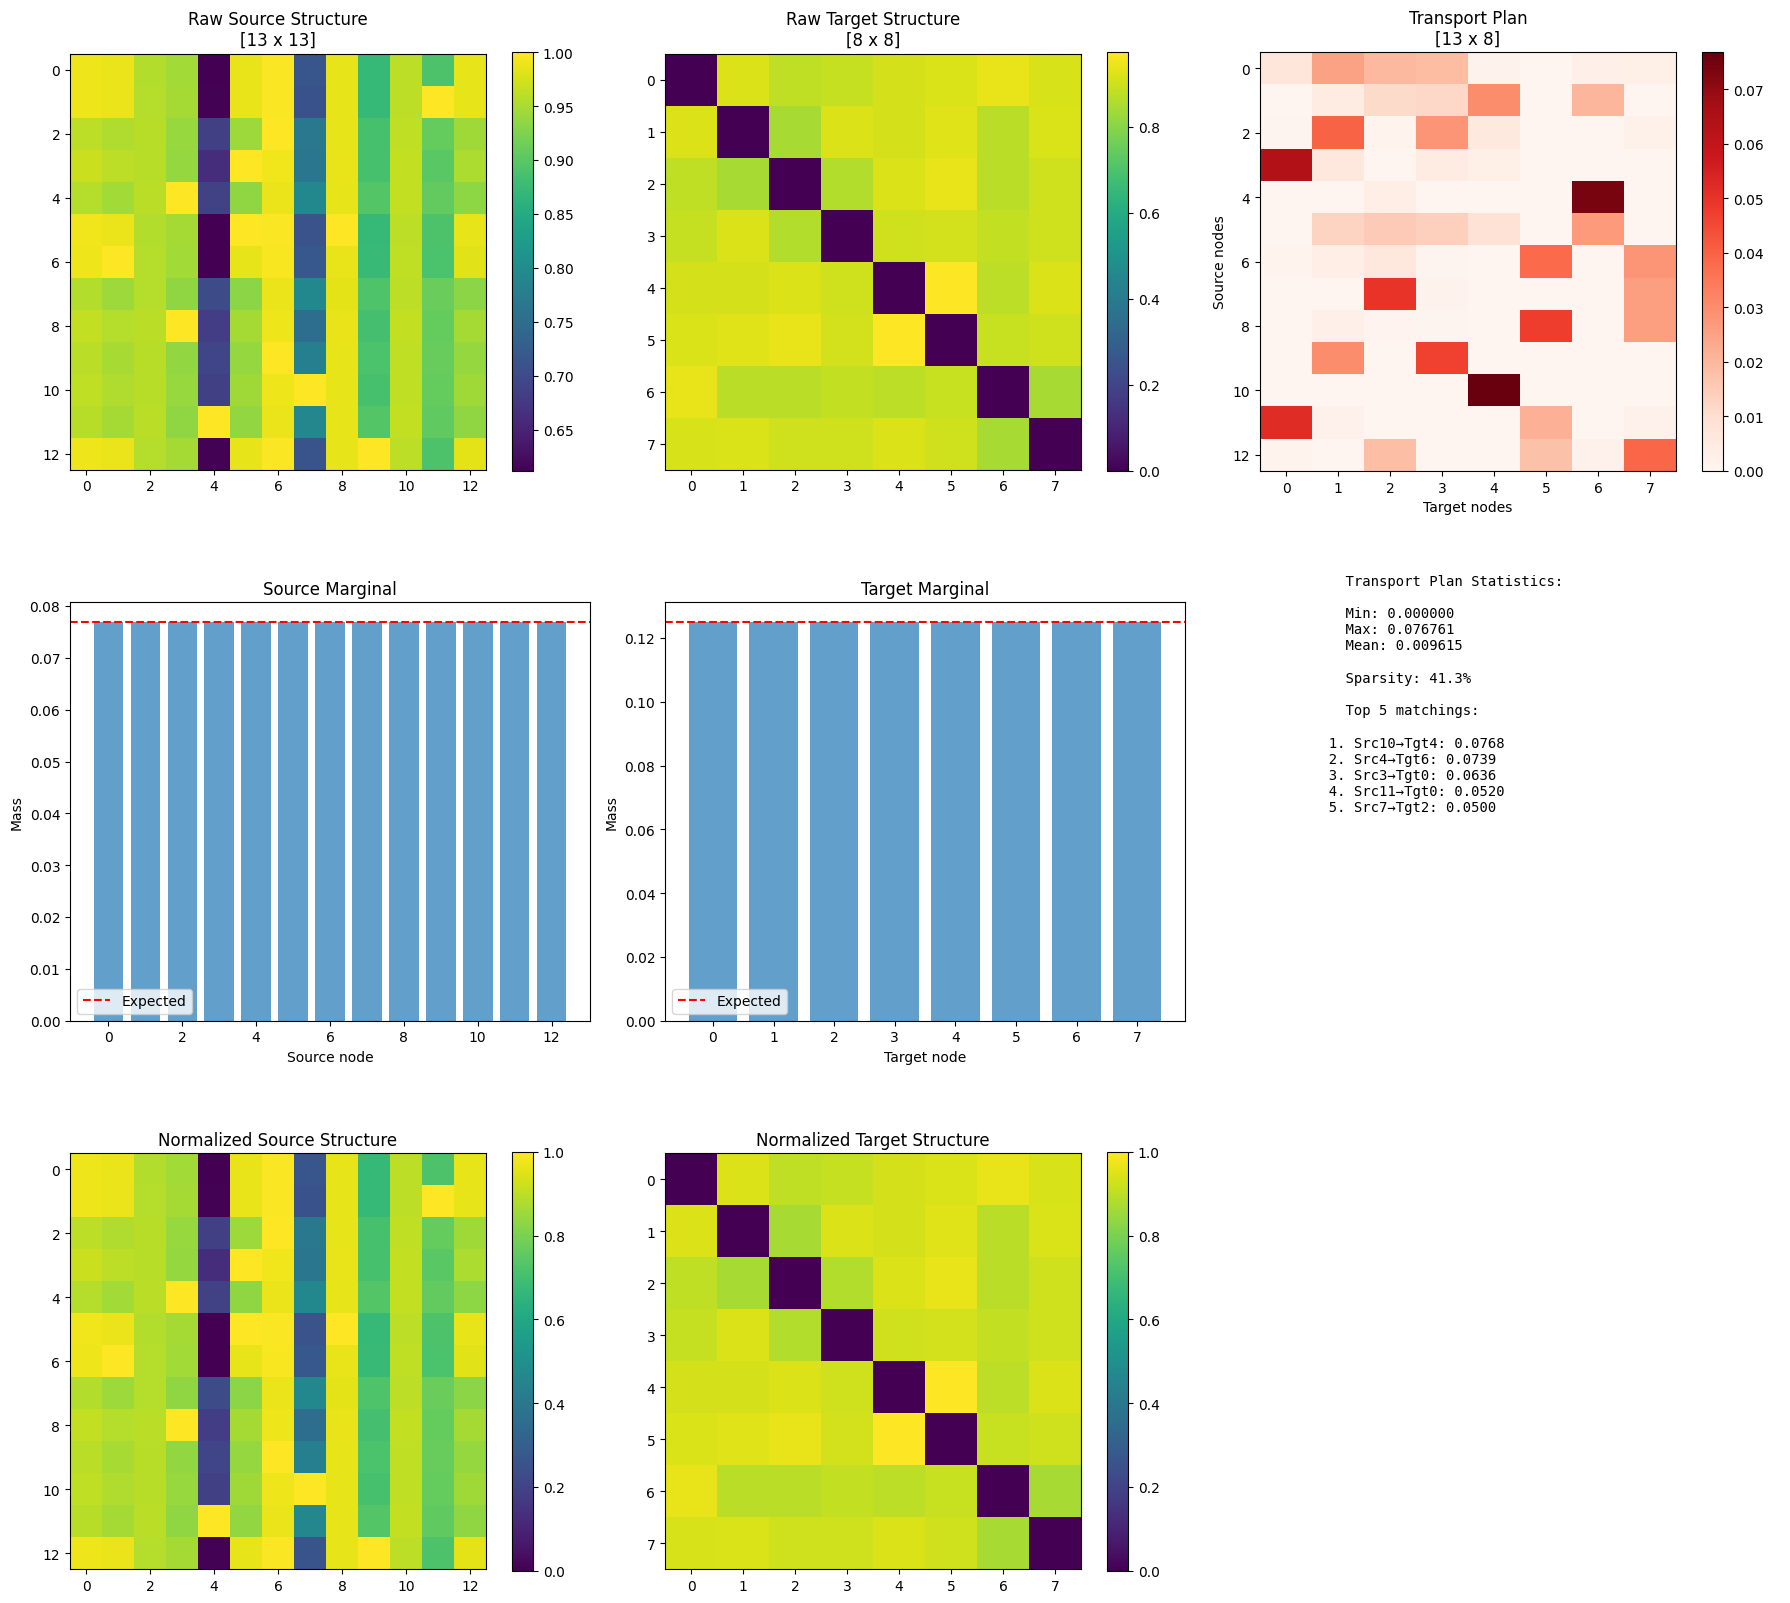

✅ Visualization saved!
  - Heart_disease_statlog | Sample 3 → Graph 3


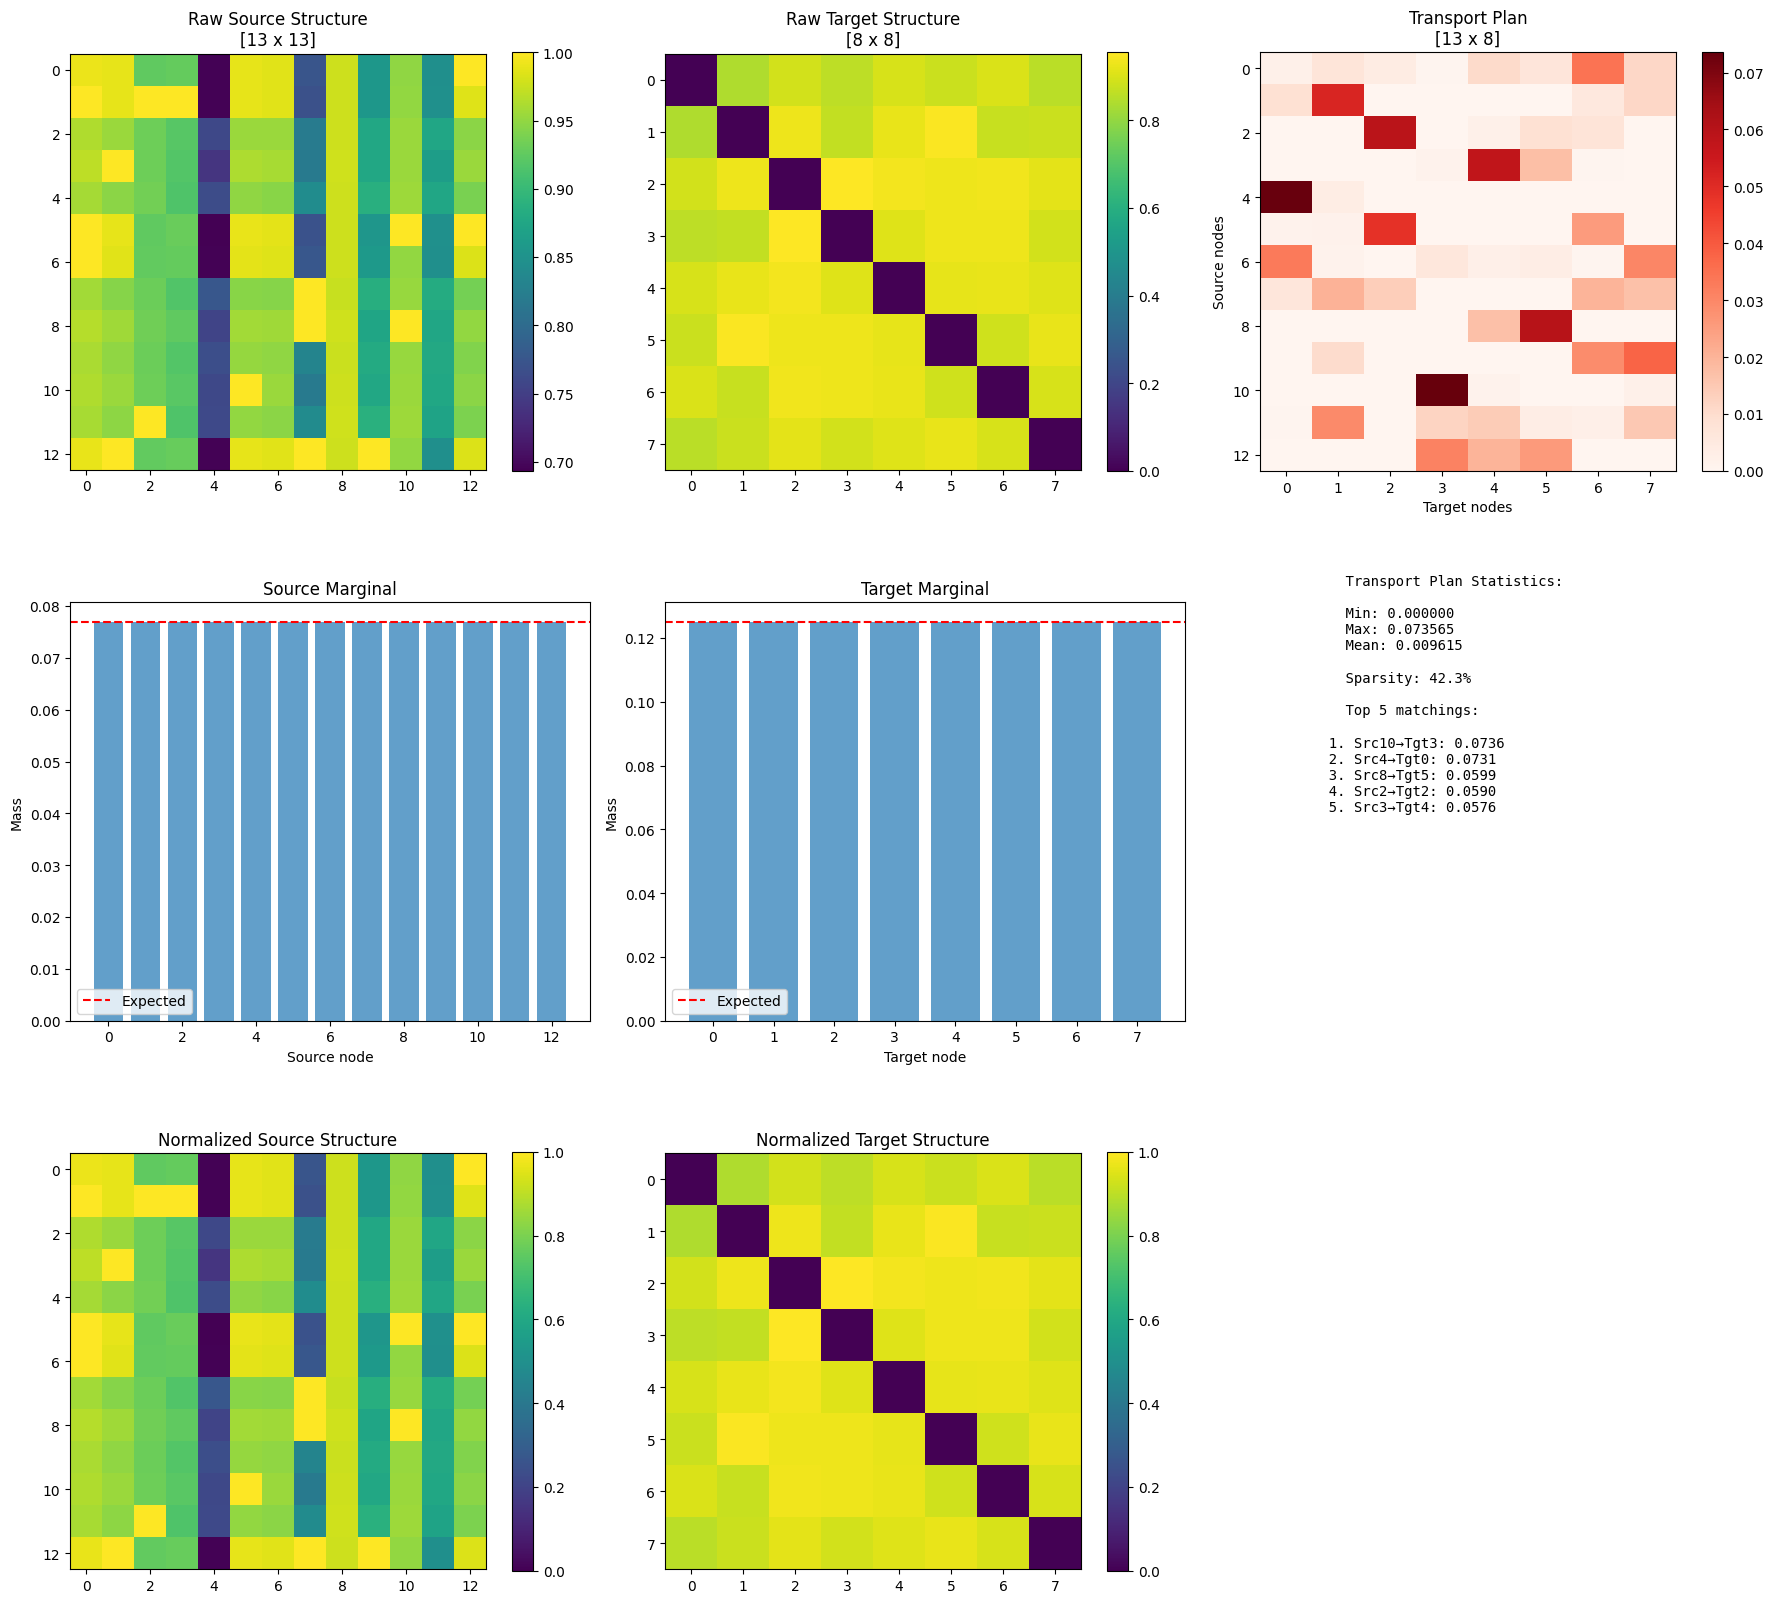

✅ Visualization saved!
  - Heart_disease_statlog | Sample 4 → Graph 4


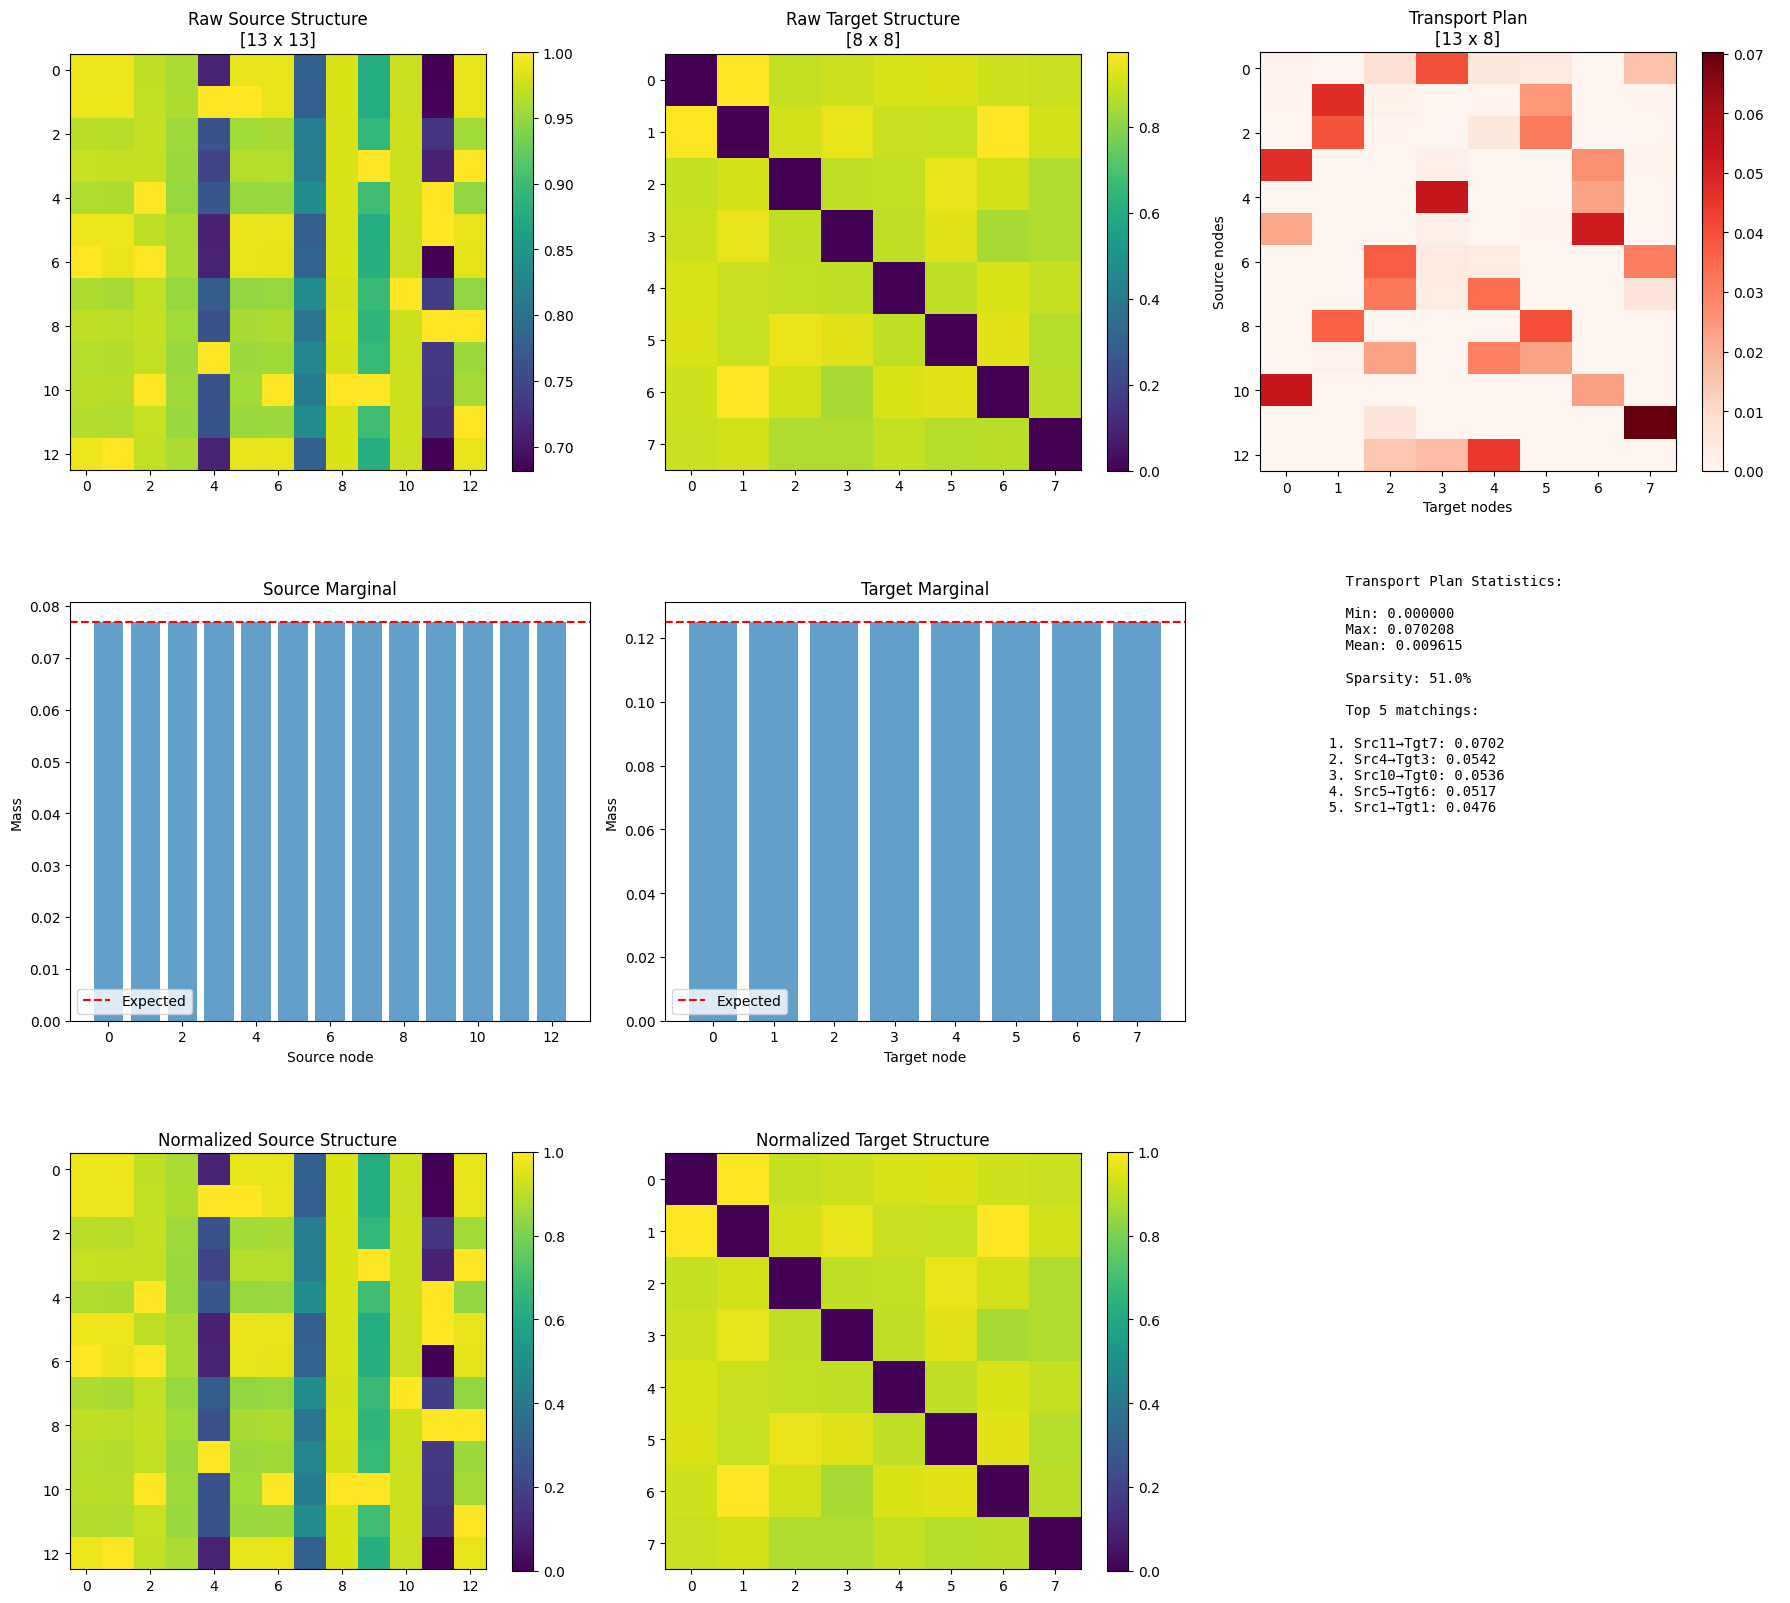

✅ Visualization saved!

>>> Visualization for Source: Cardiovascular_Disease_Dataset
  - Cardiovascular_Disease_Dataset | Sample 0 → Graph 0


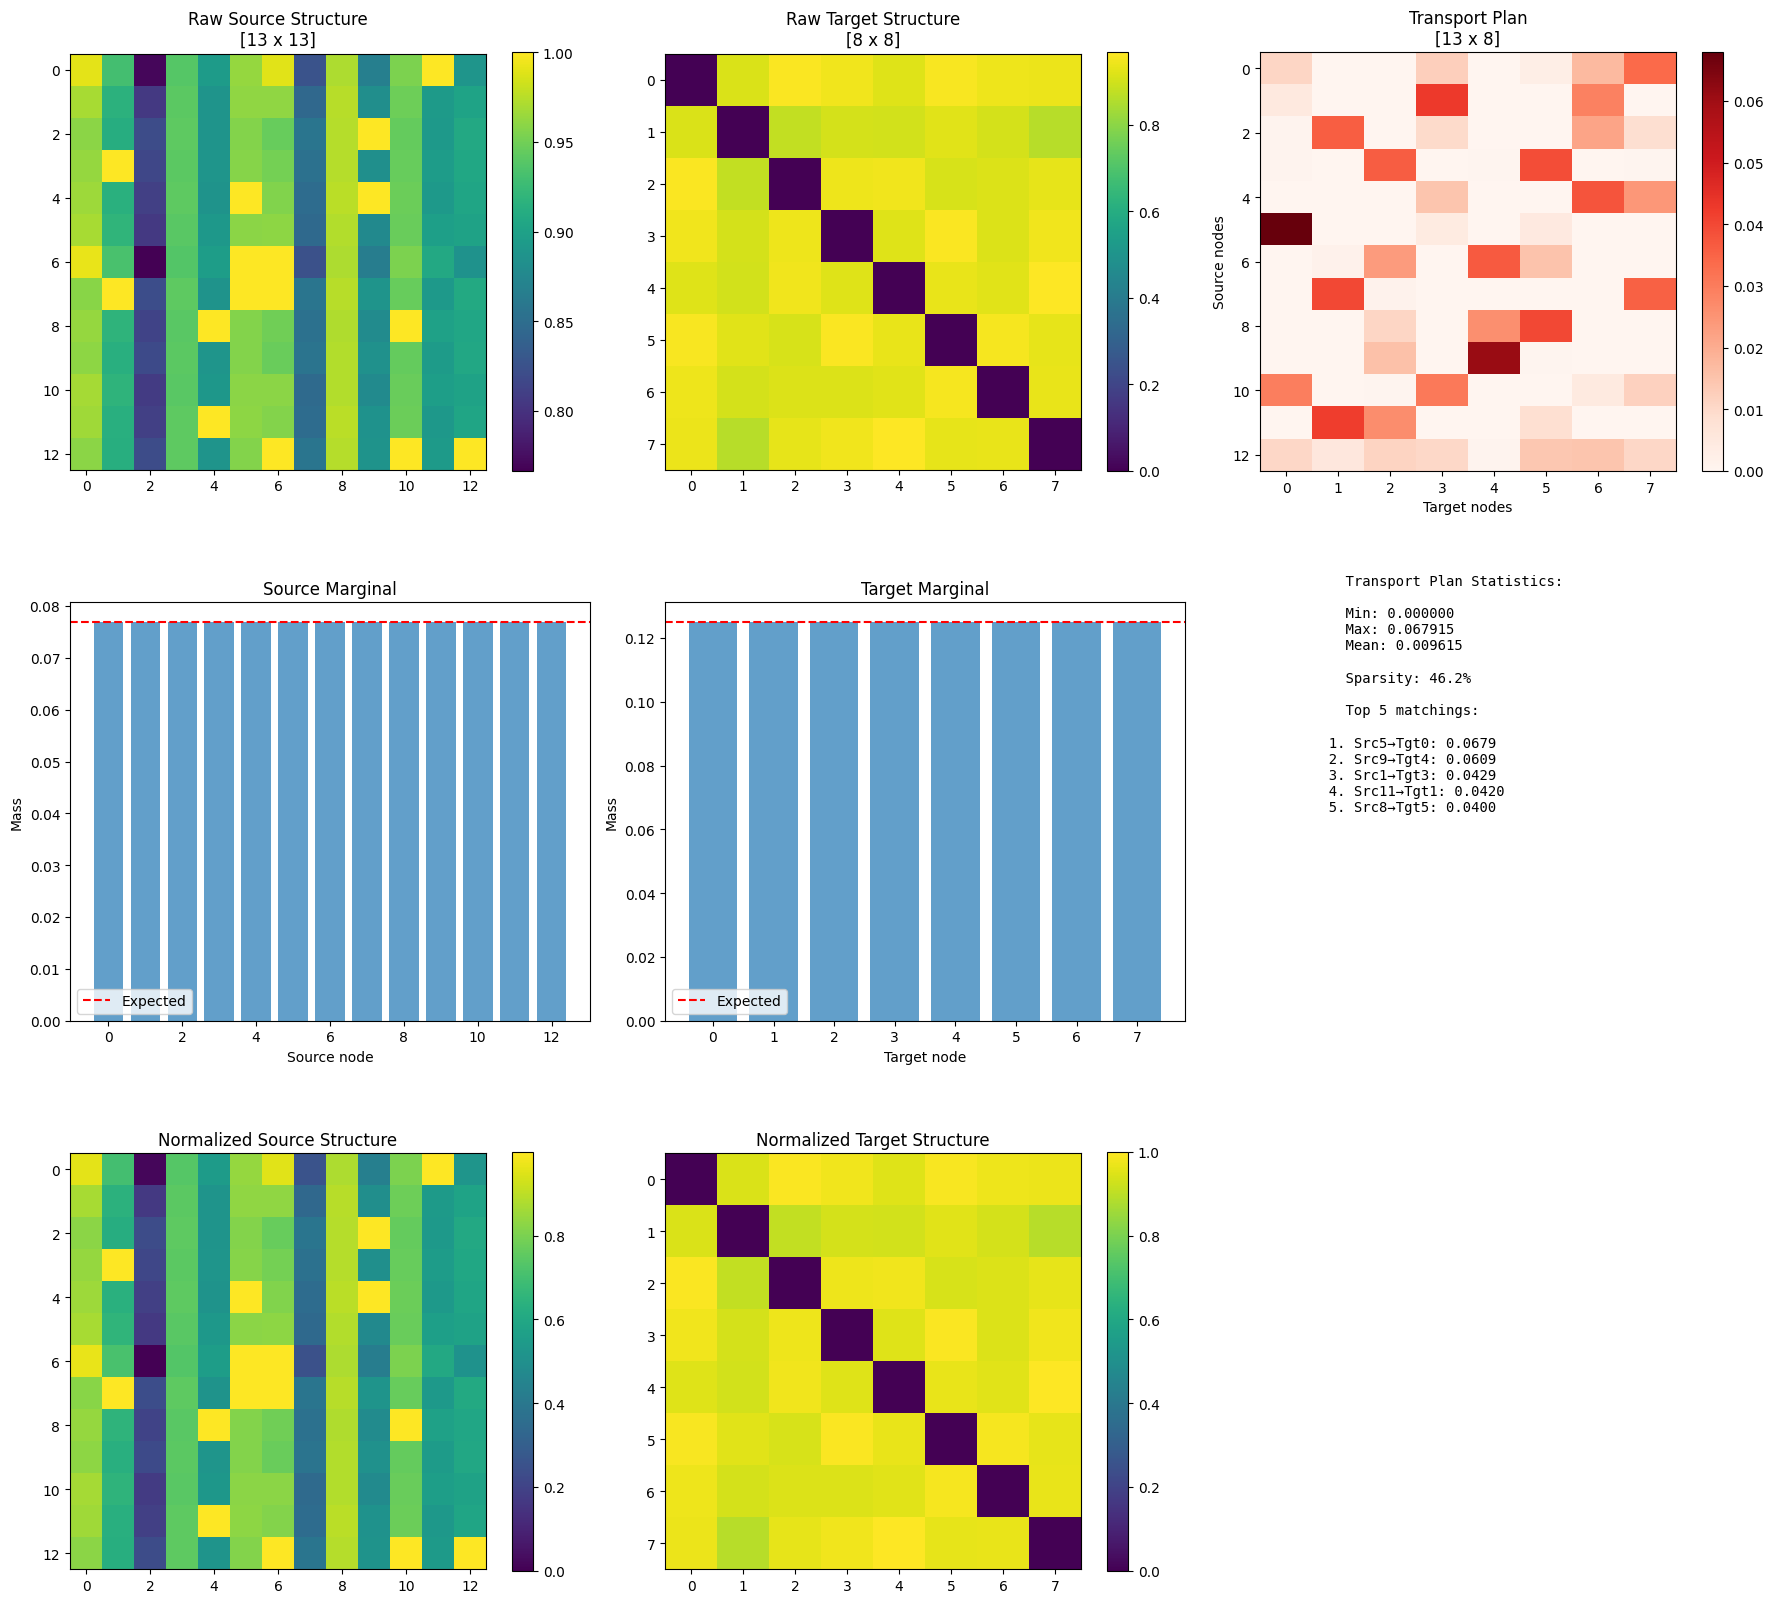

✅ Visualization saved!
  - Cardiovascular_Disease_Dataset | Sample 1 → Graph 1


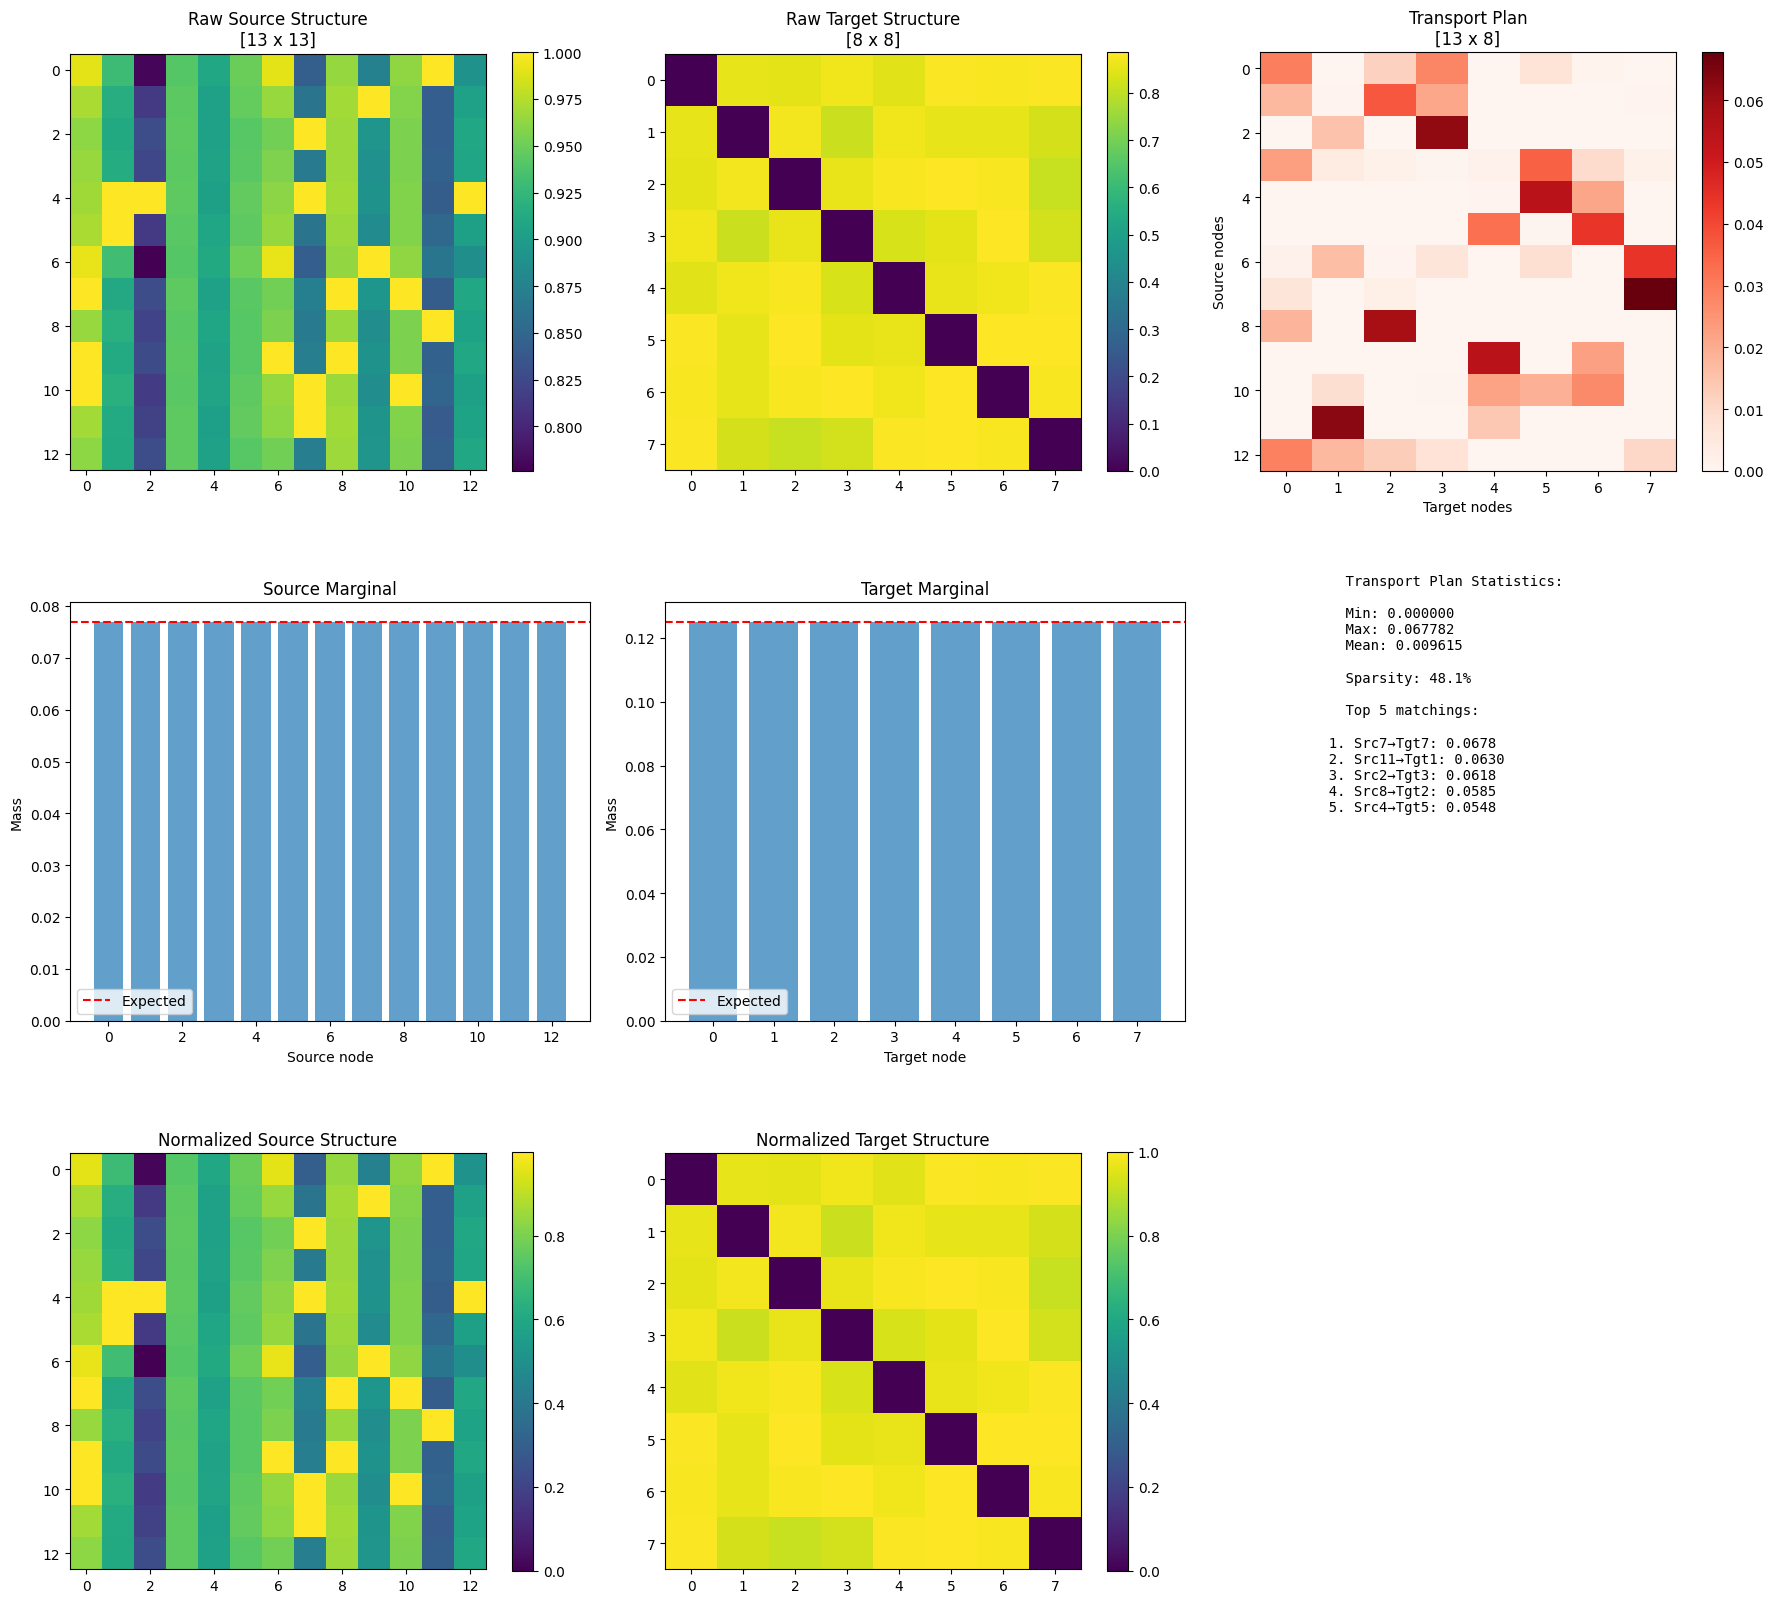

✅ Visualization saved!
  - Cardiovascular_Disease_Dataset | Sample 2 → Graph 2


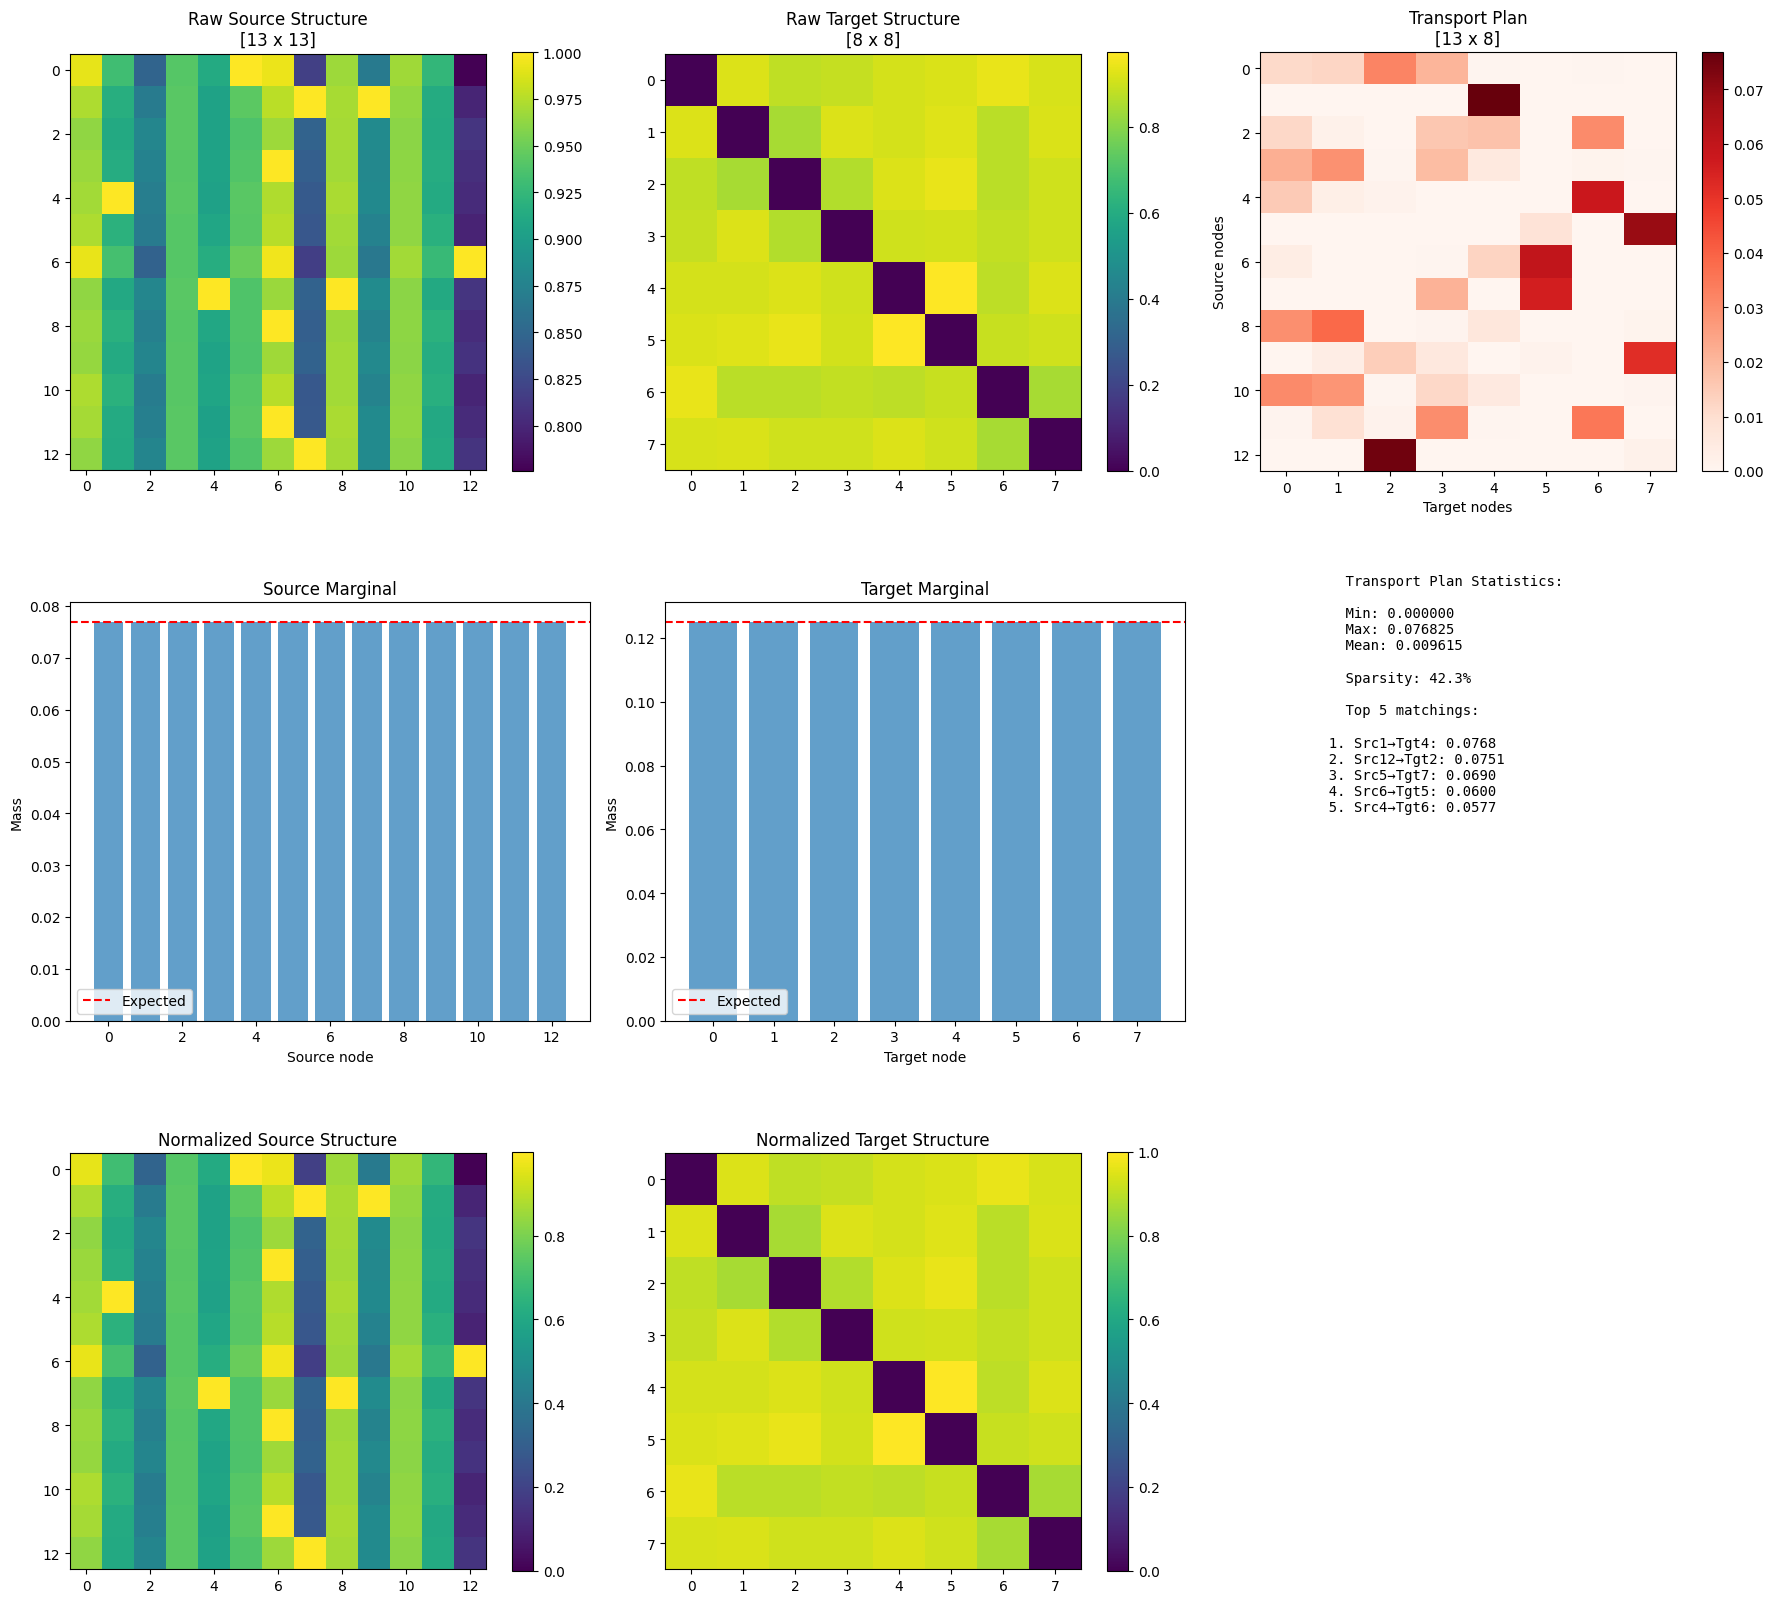

✅ Visualization saved!
  - Cardiovascular_Disease_Dataset | Sample 3 → Graph 3


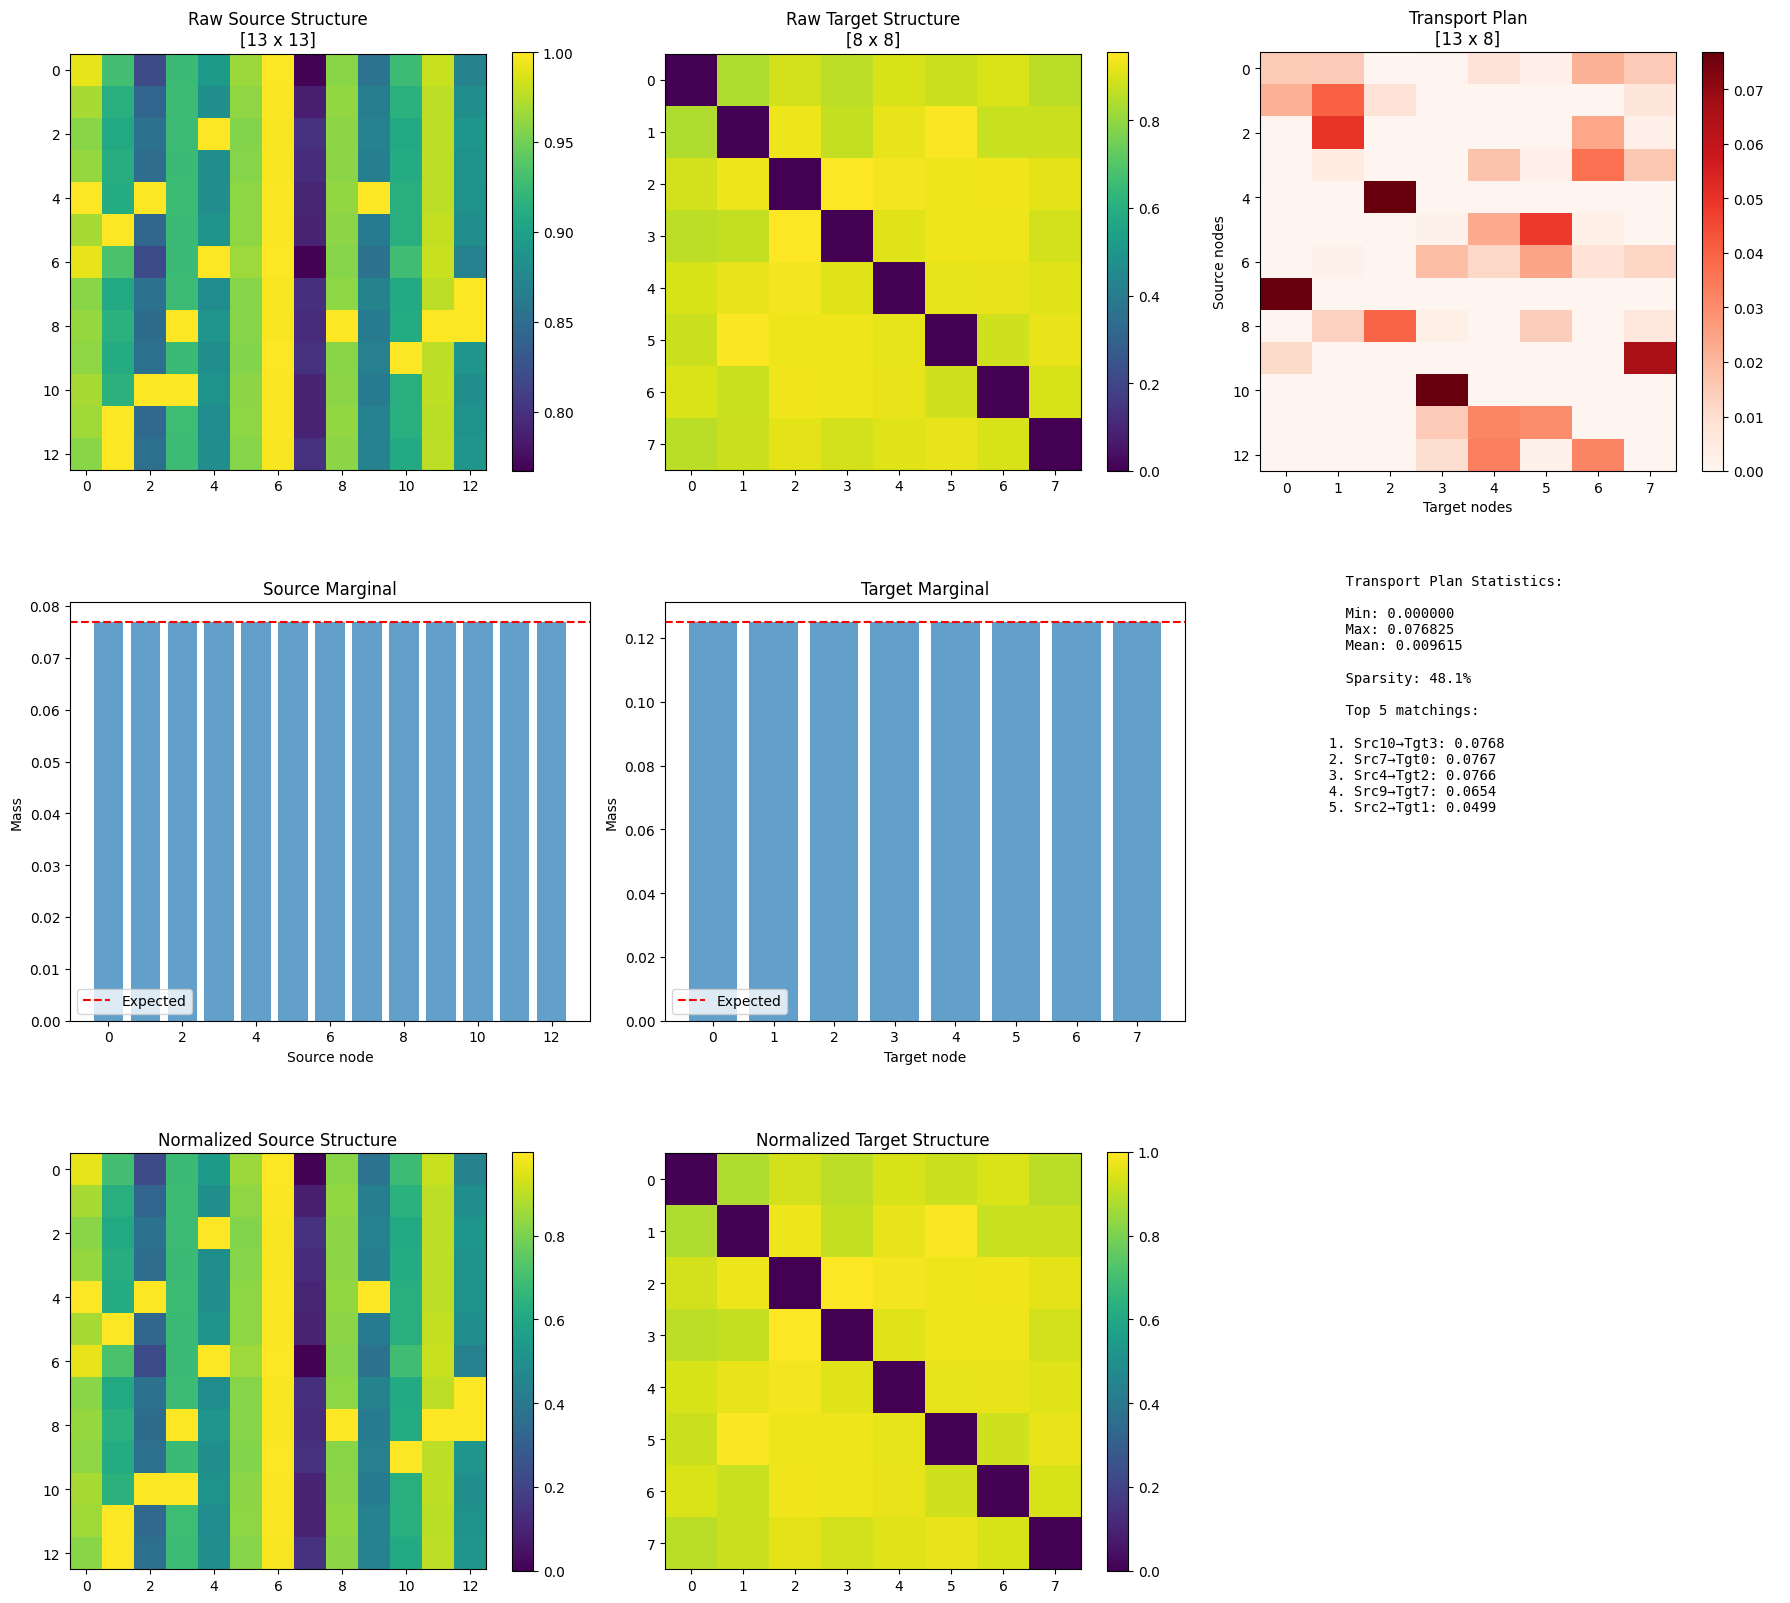

✅ Visualization saved!
  - Cardiovascular_Disease_Dataset | Sample 4 → Graph 4


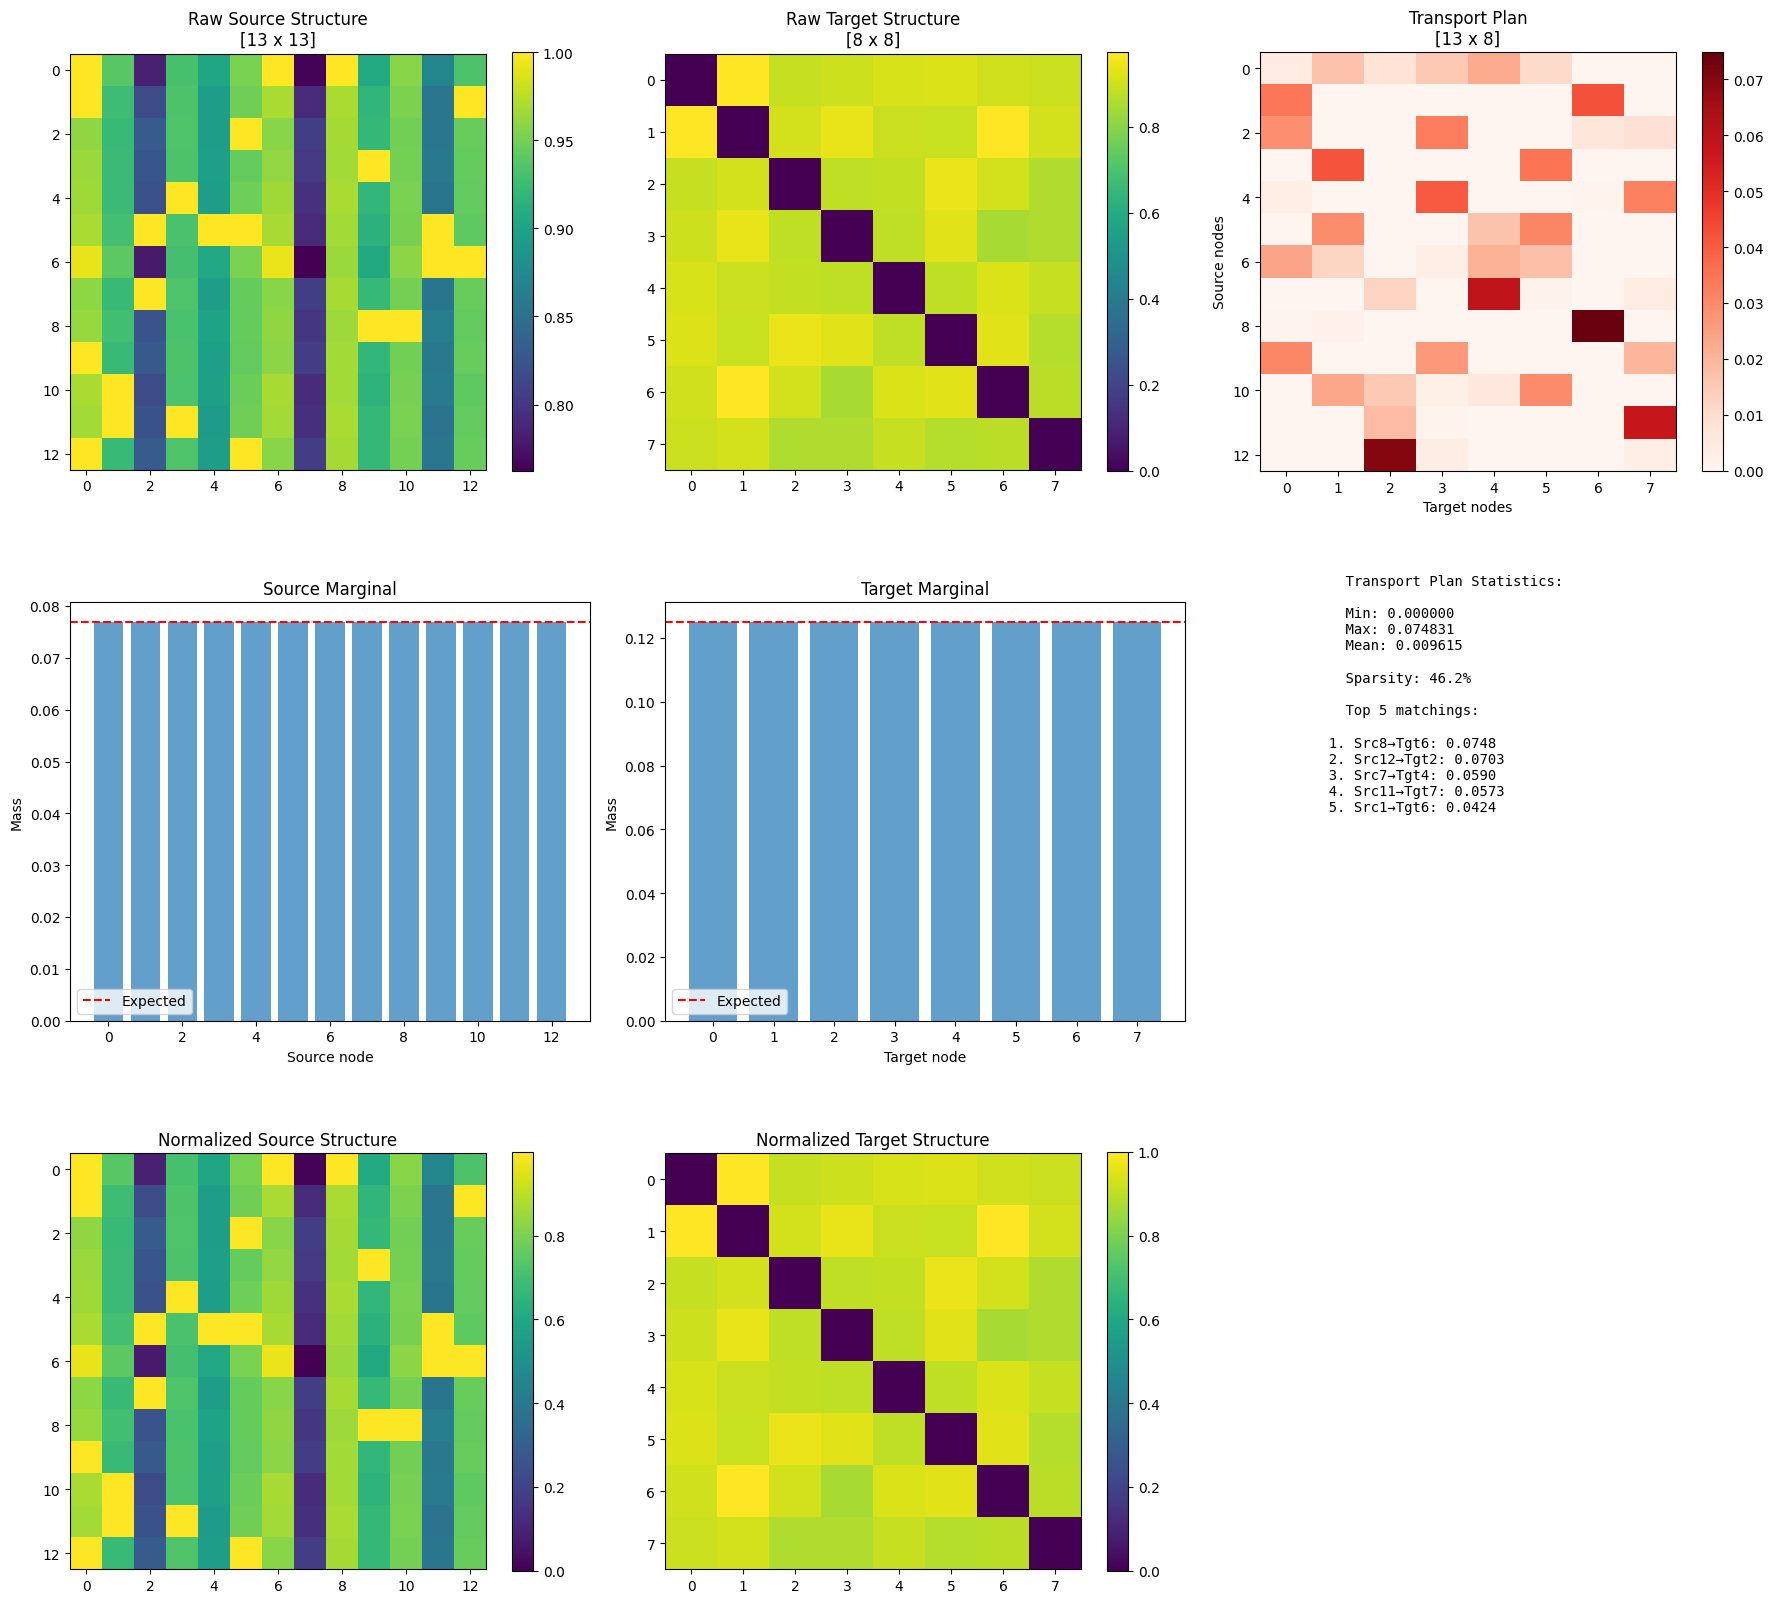

✅ Visualization saved!

>>> Visualization for Source: heart_target_3
  - heart_target_3 | Sample 0 → Graph 0


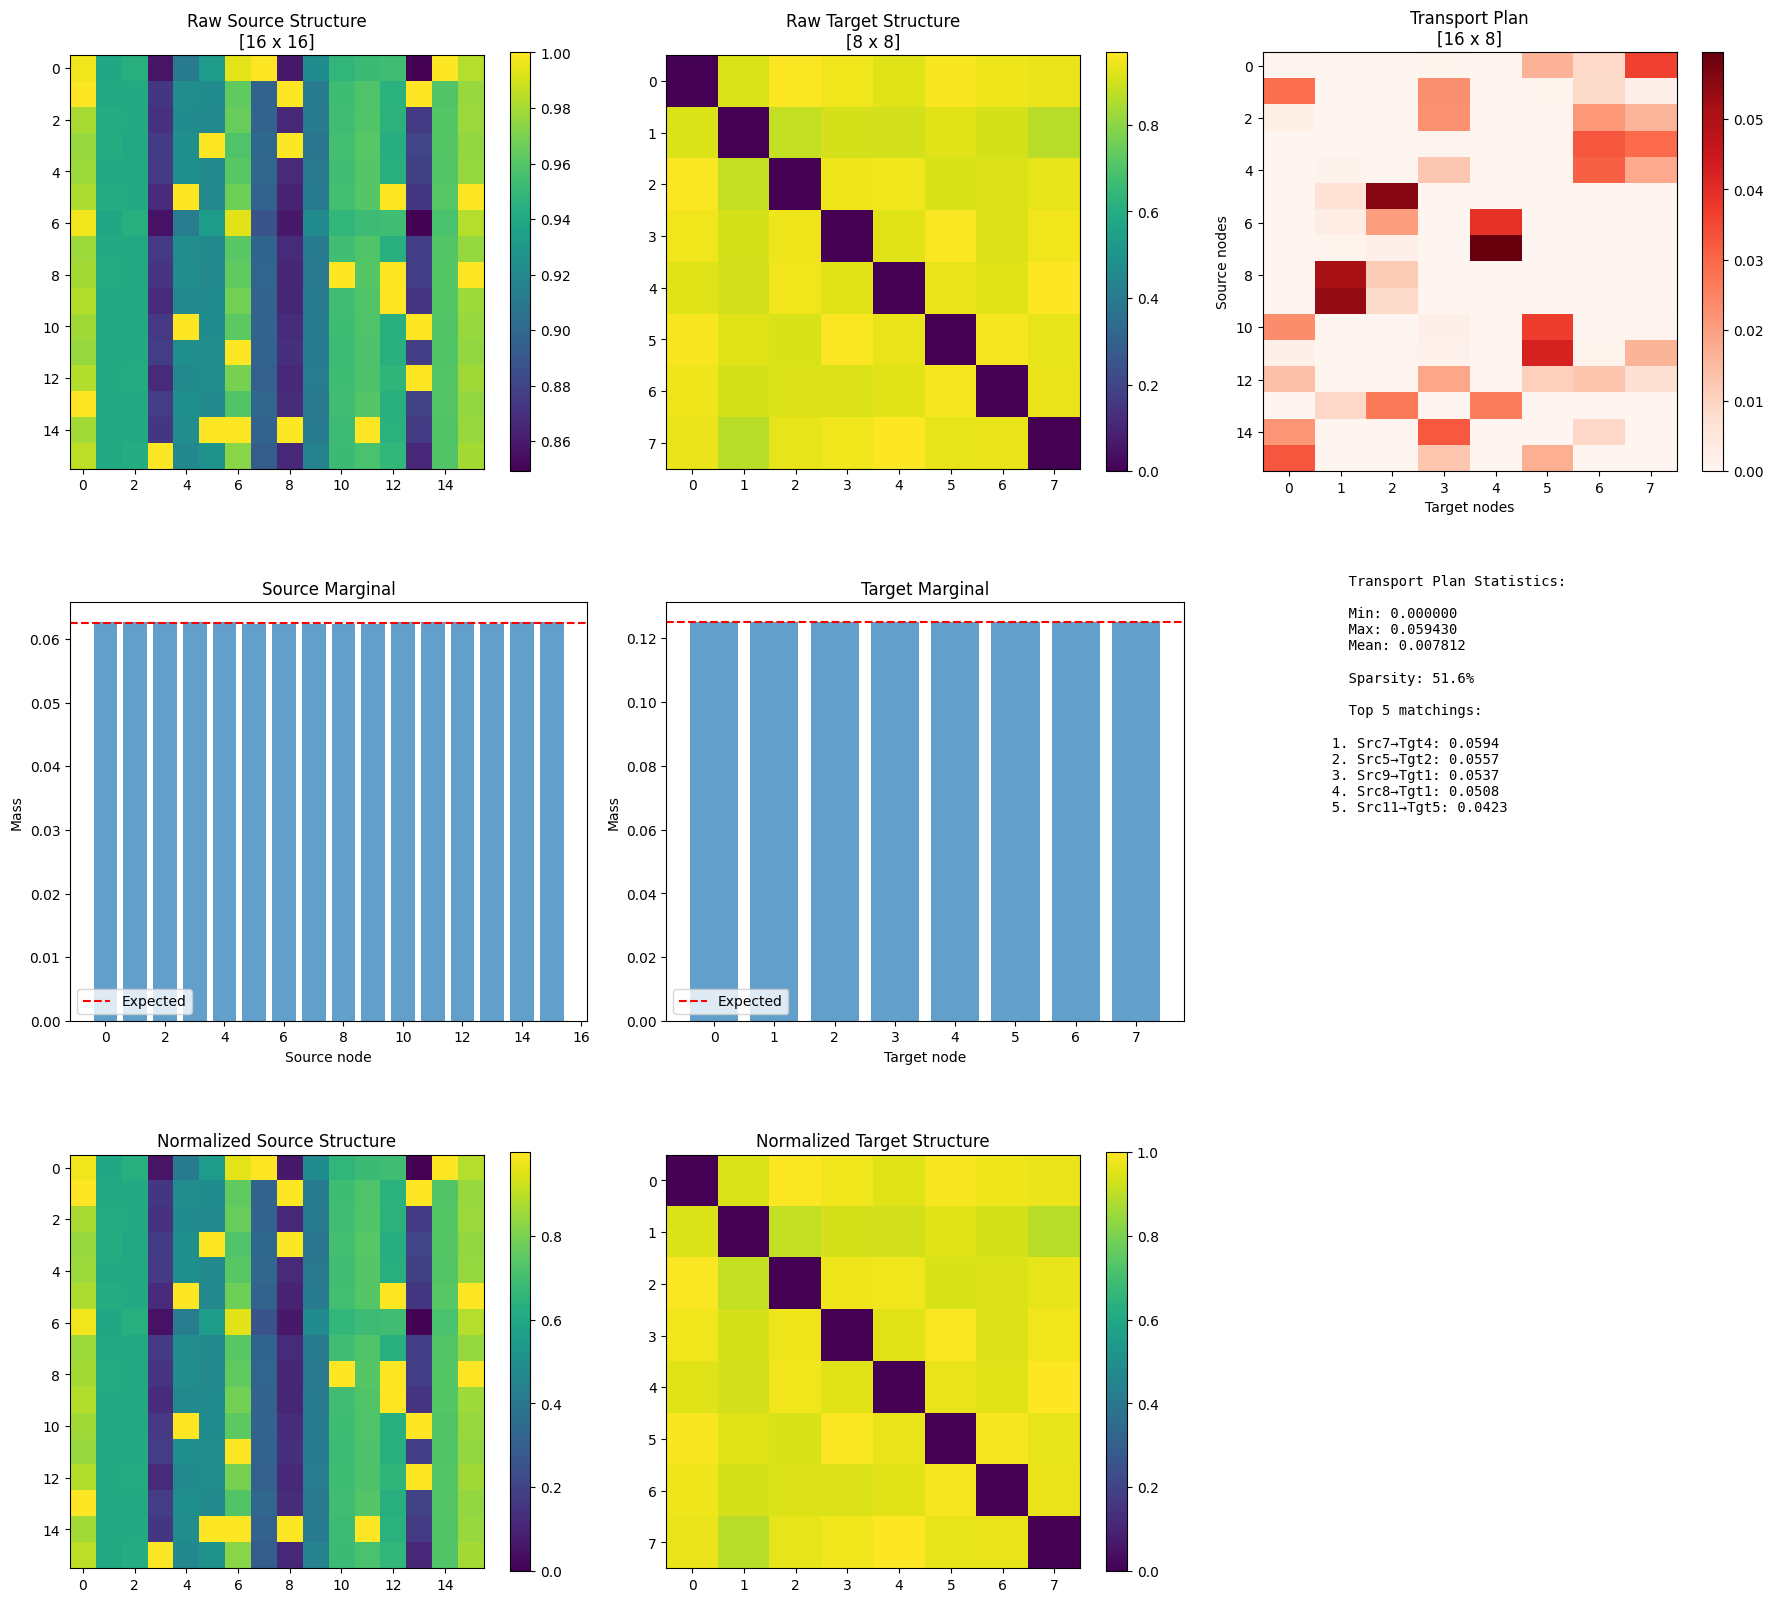

✅ Visualization saved!
  - heart_target_3 | Sample 1 → Graph 1


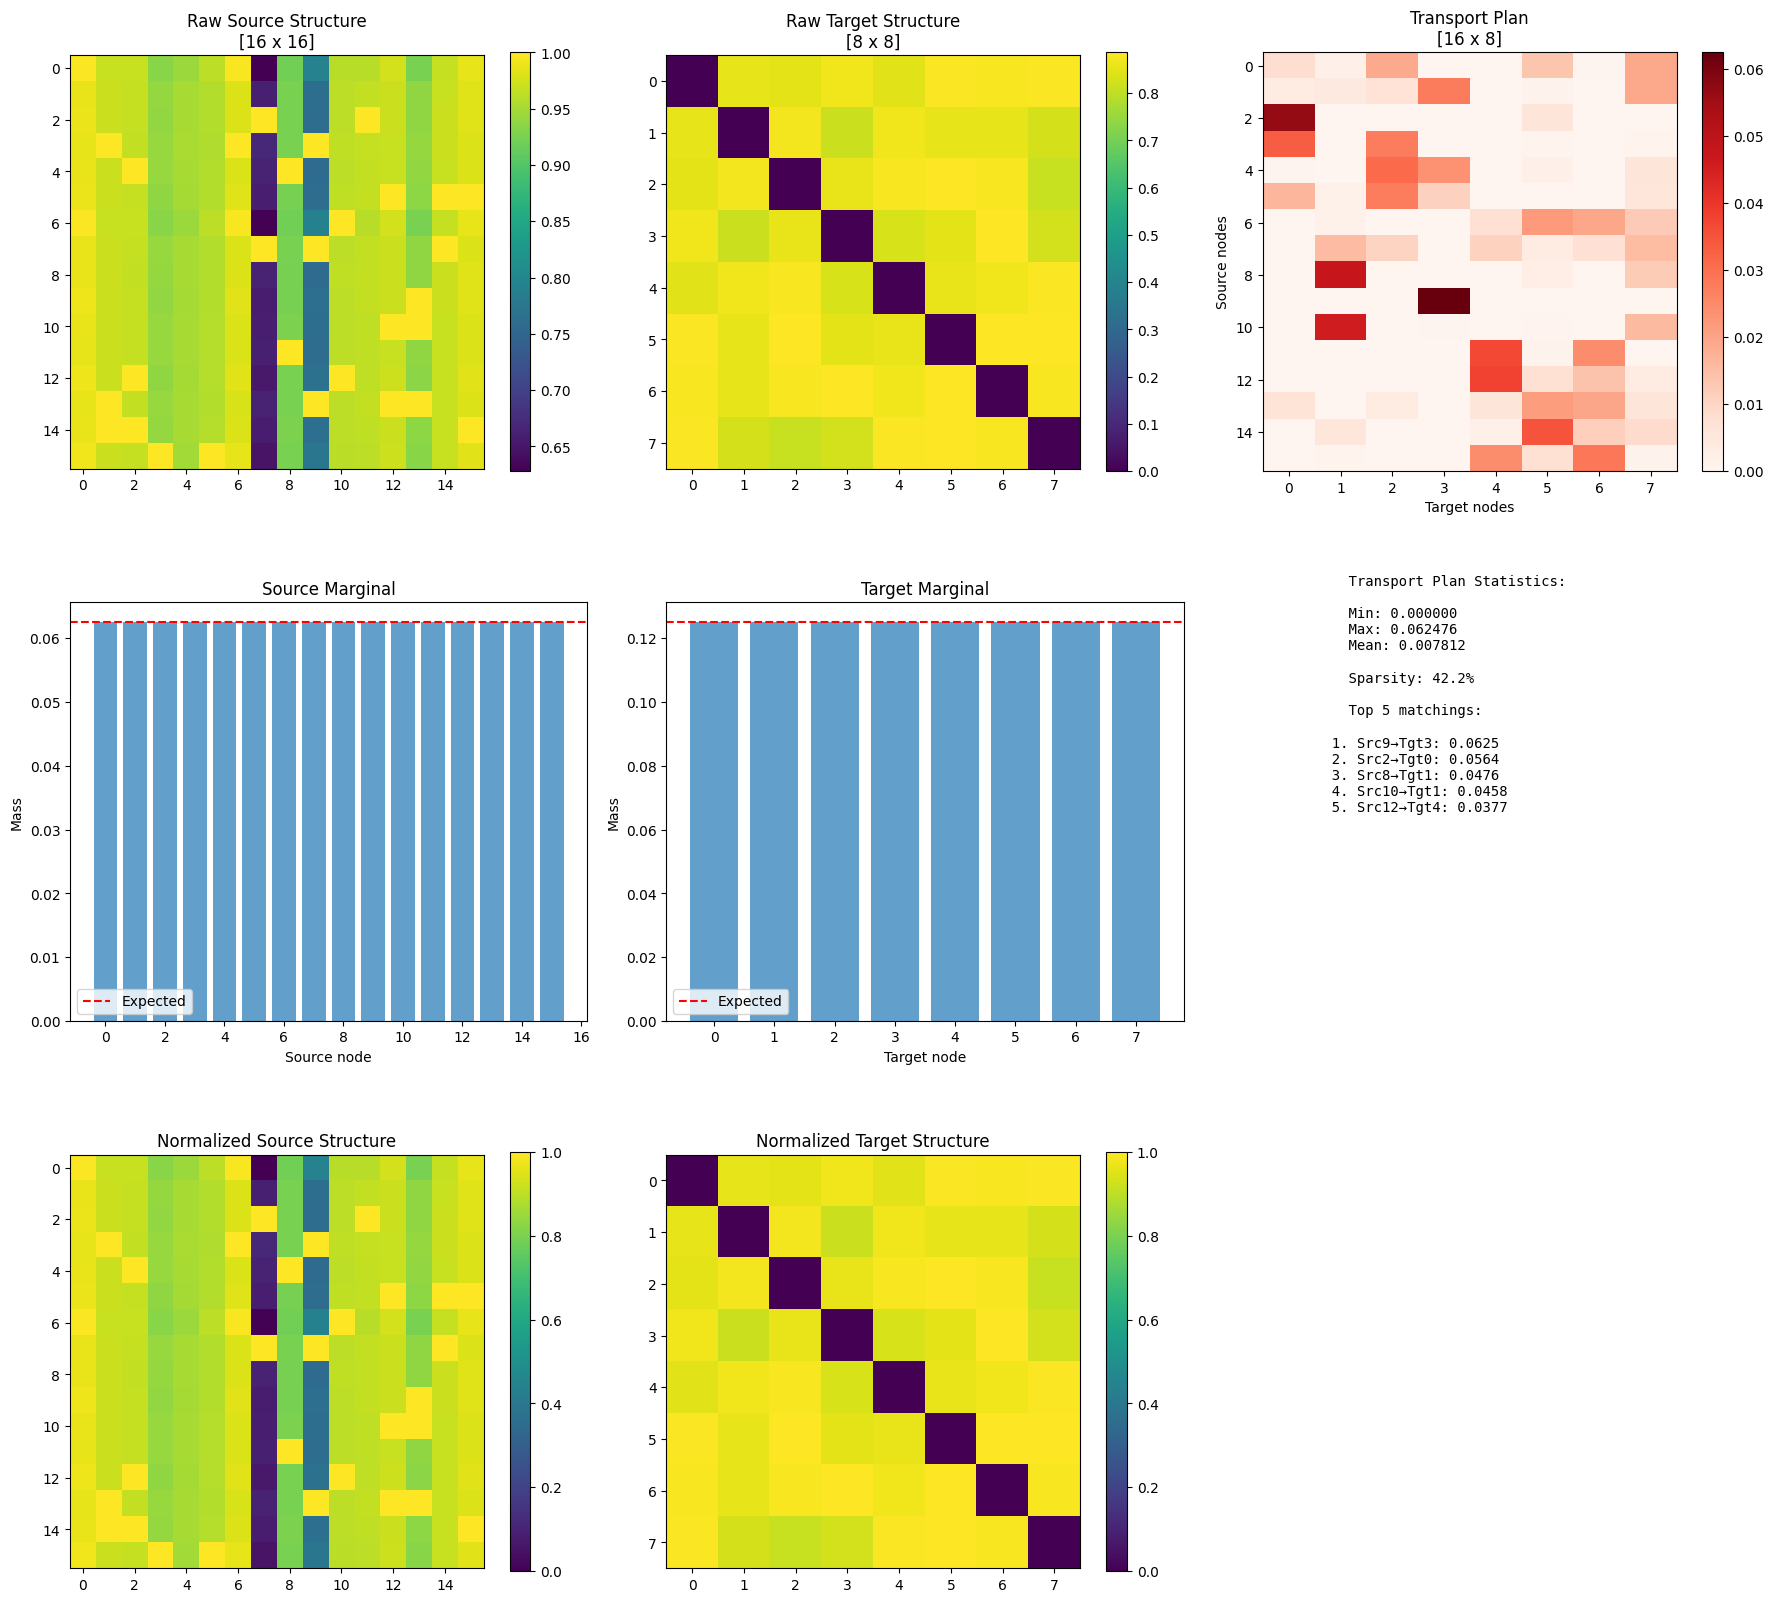

✅ Visualization saved!
  - heart_target_3 | Sample 2 → Graph 2


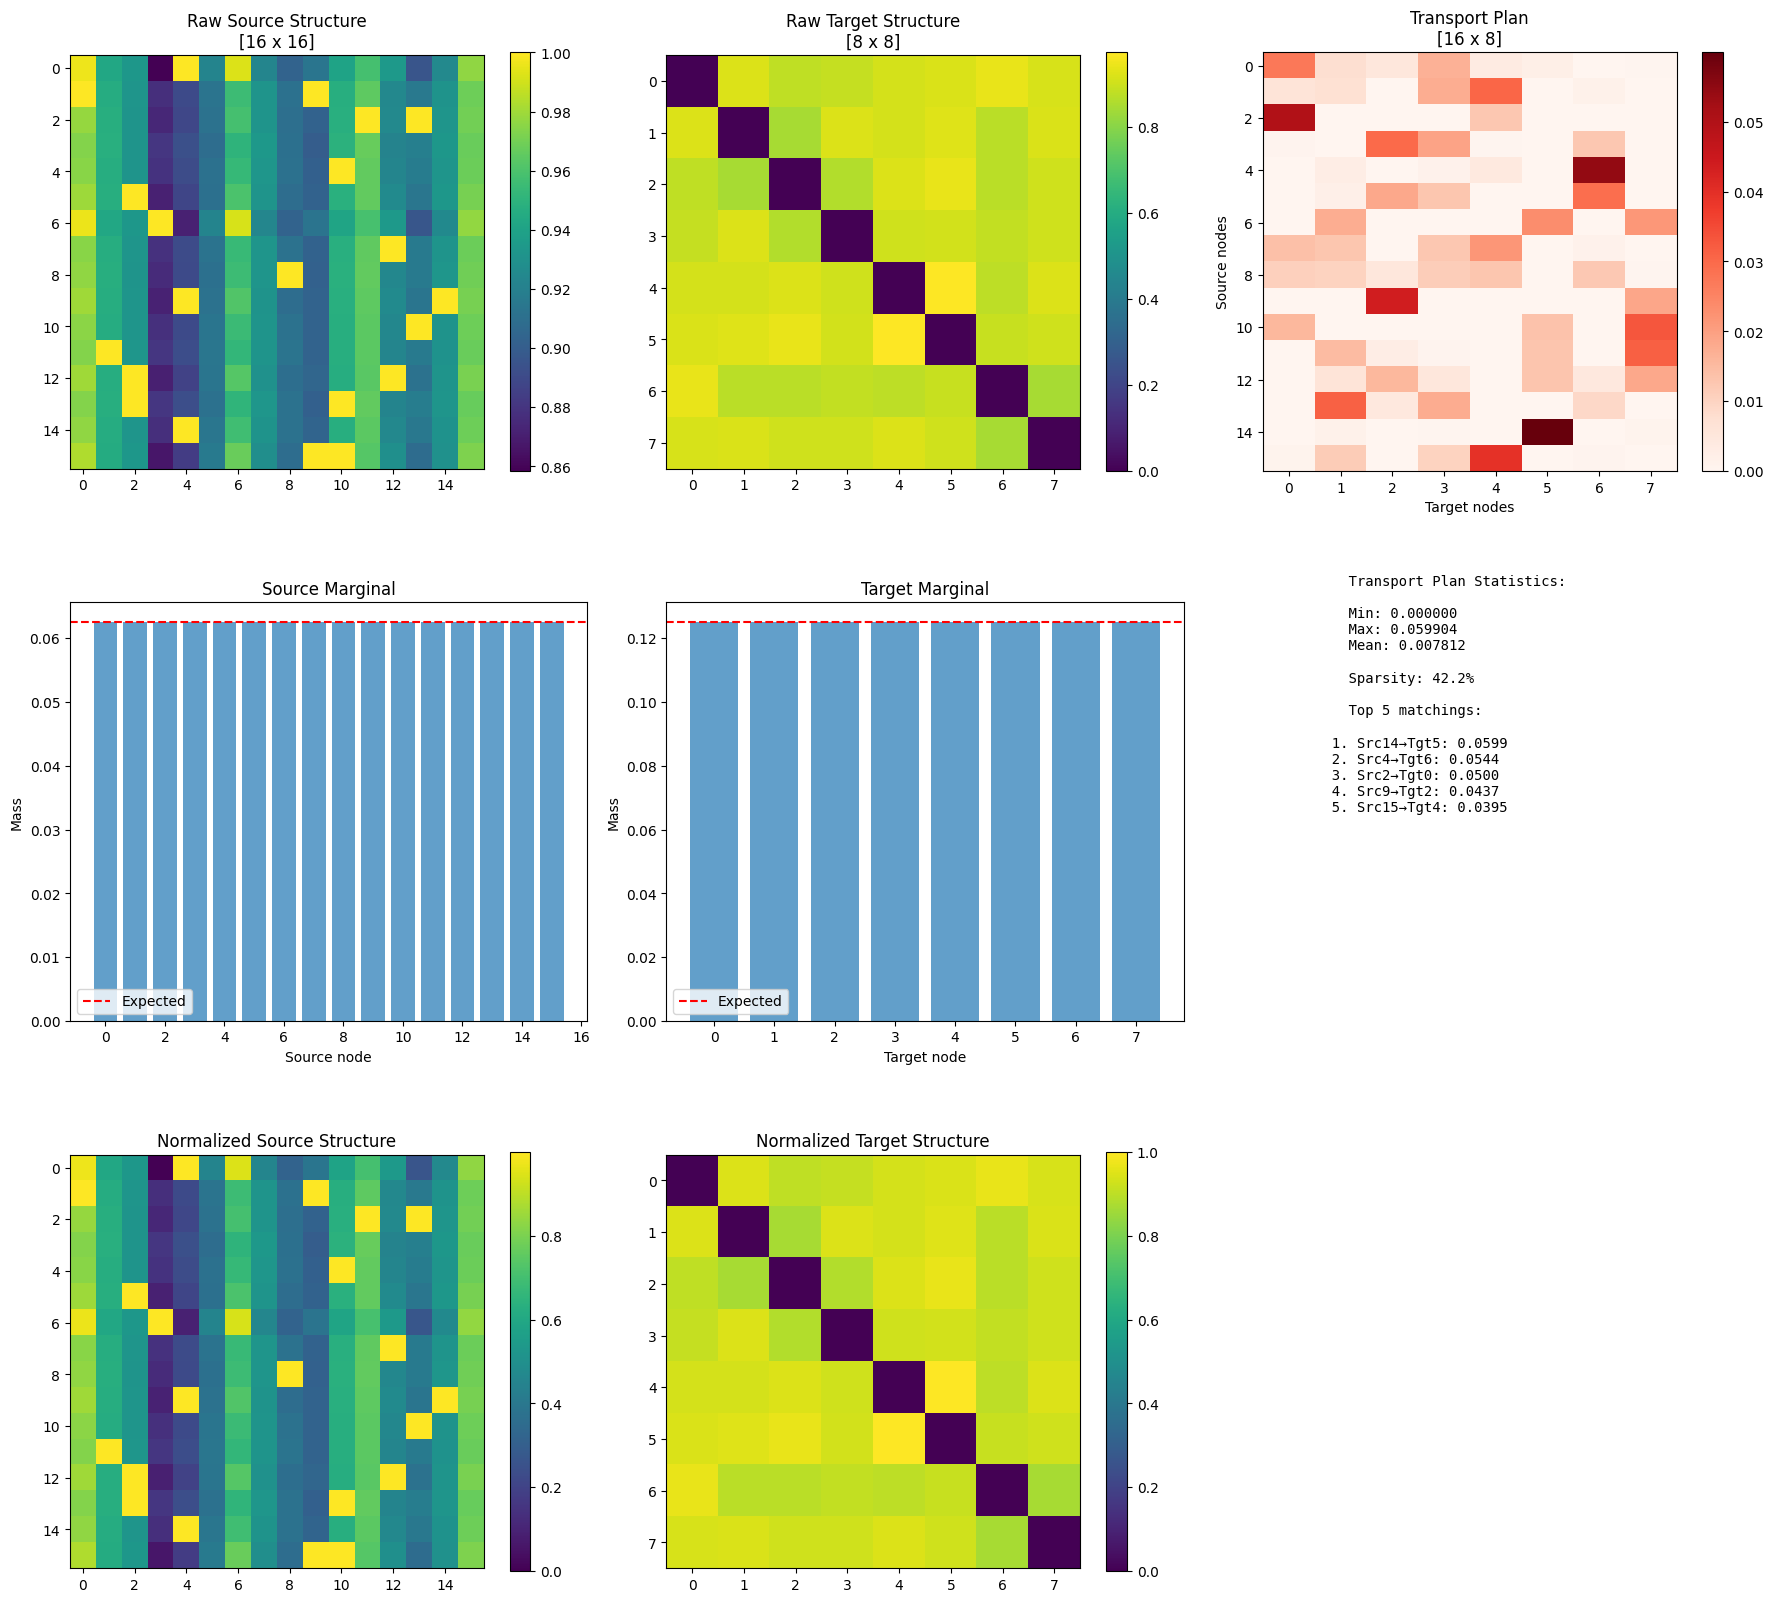

✅ Visualization saved!
  - heart_target_3 | Sample 3 → Graph 3


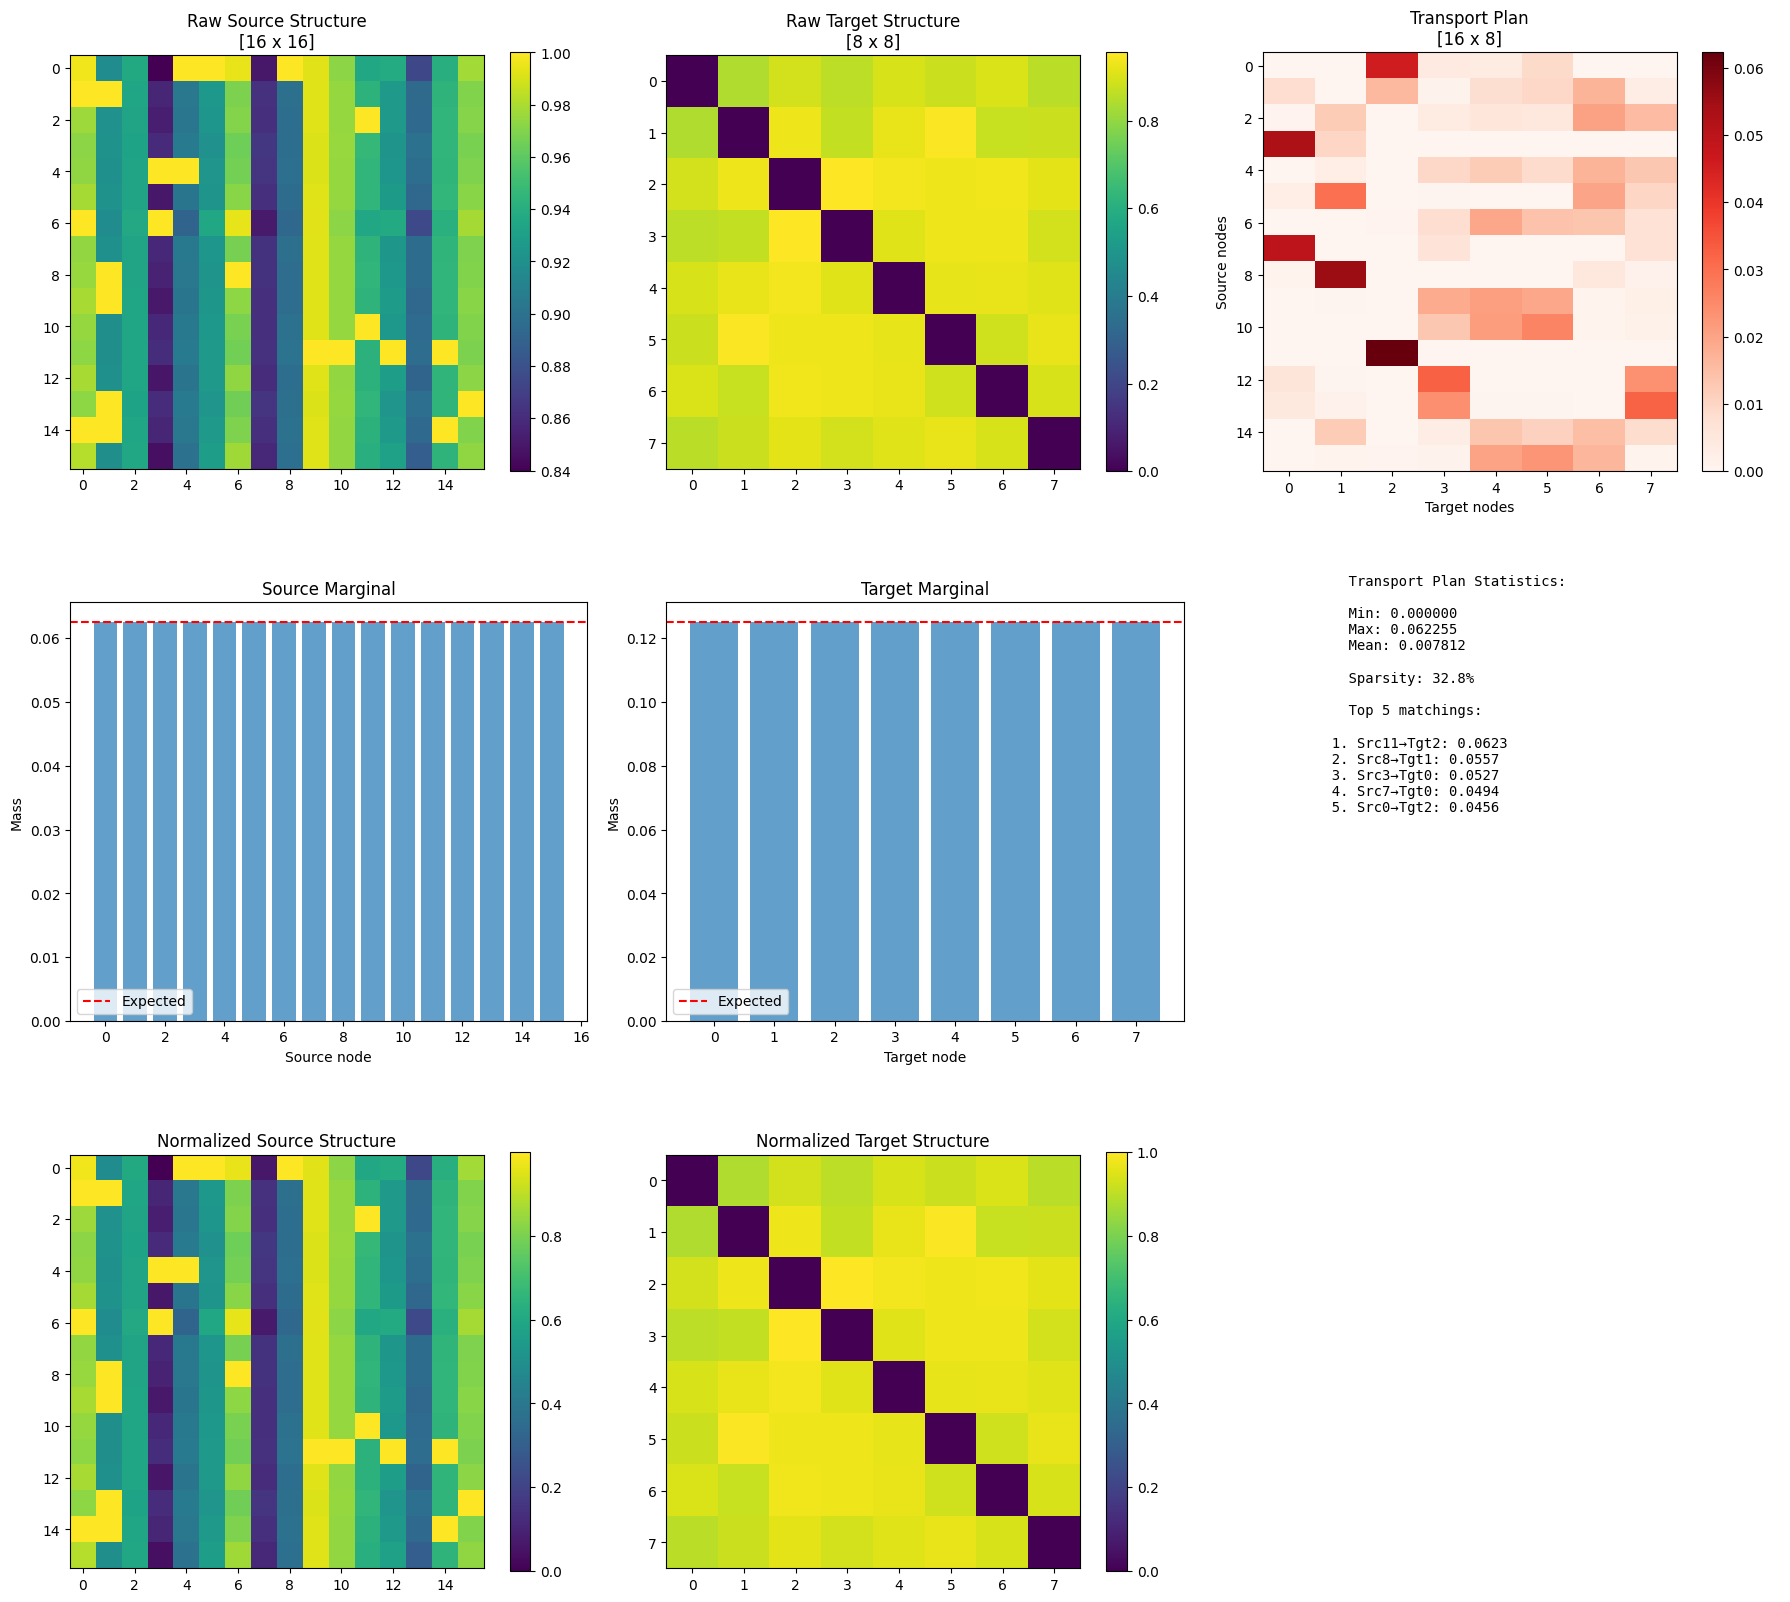

✅ Visualization saved!
  - heart_target_3 | Sample 4 → Graph 4


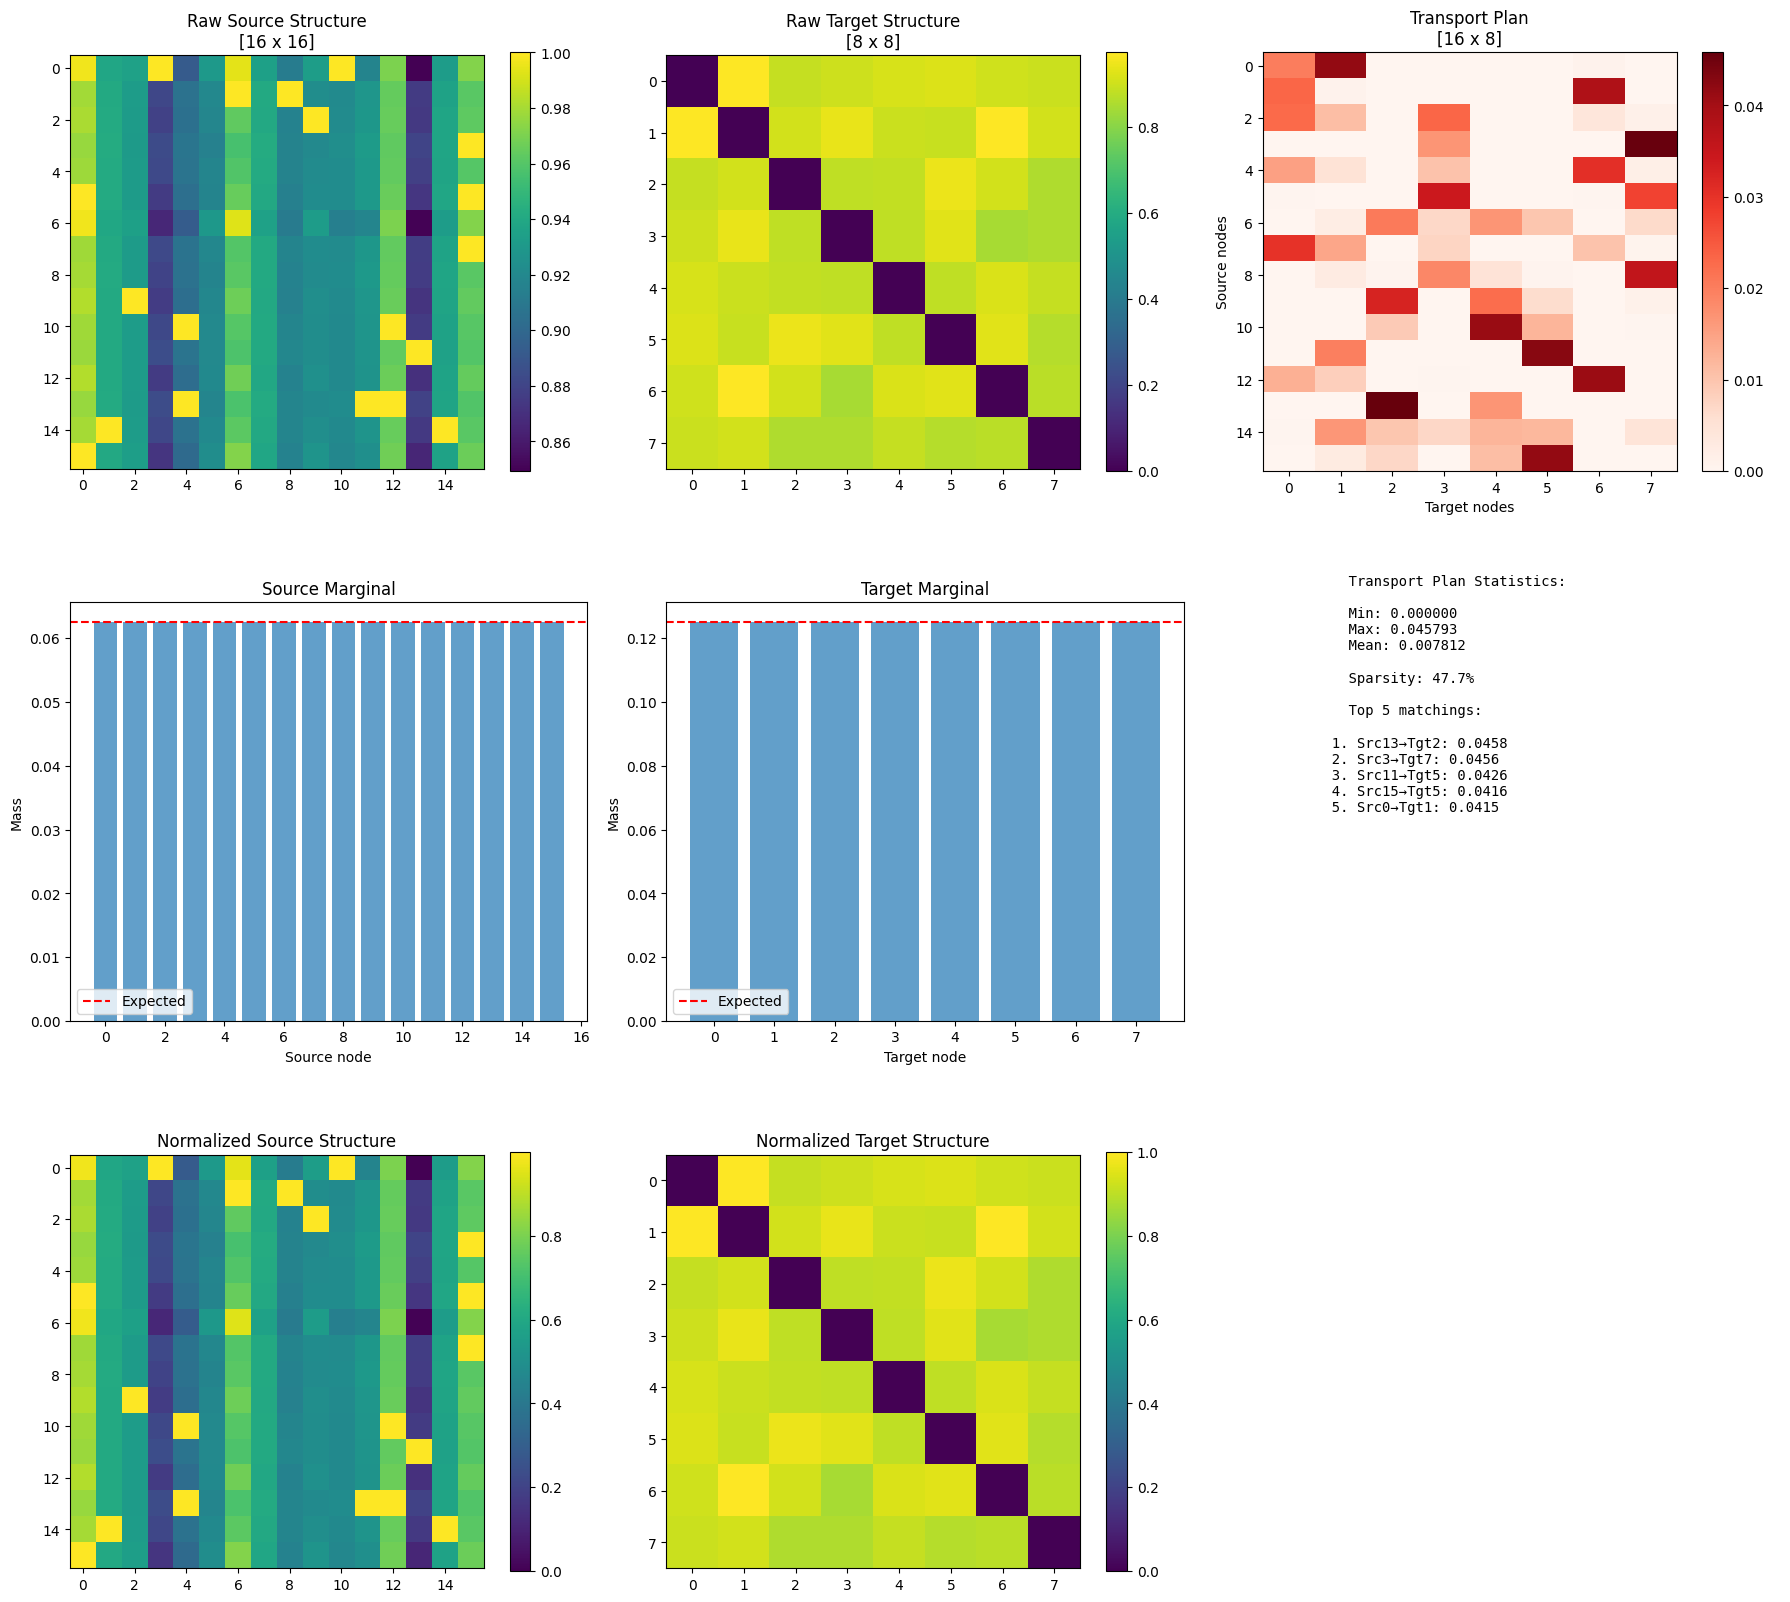

✅ Visualization saved!

>>> Visualization for Source: heart_target_4
  - heart_target_4 | Sample 0 → Graph 0


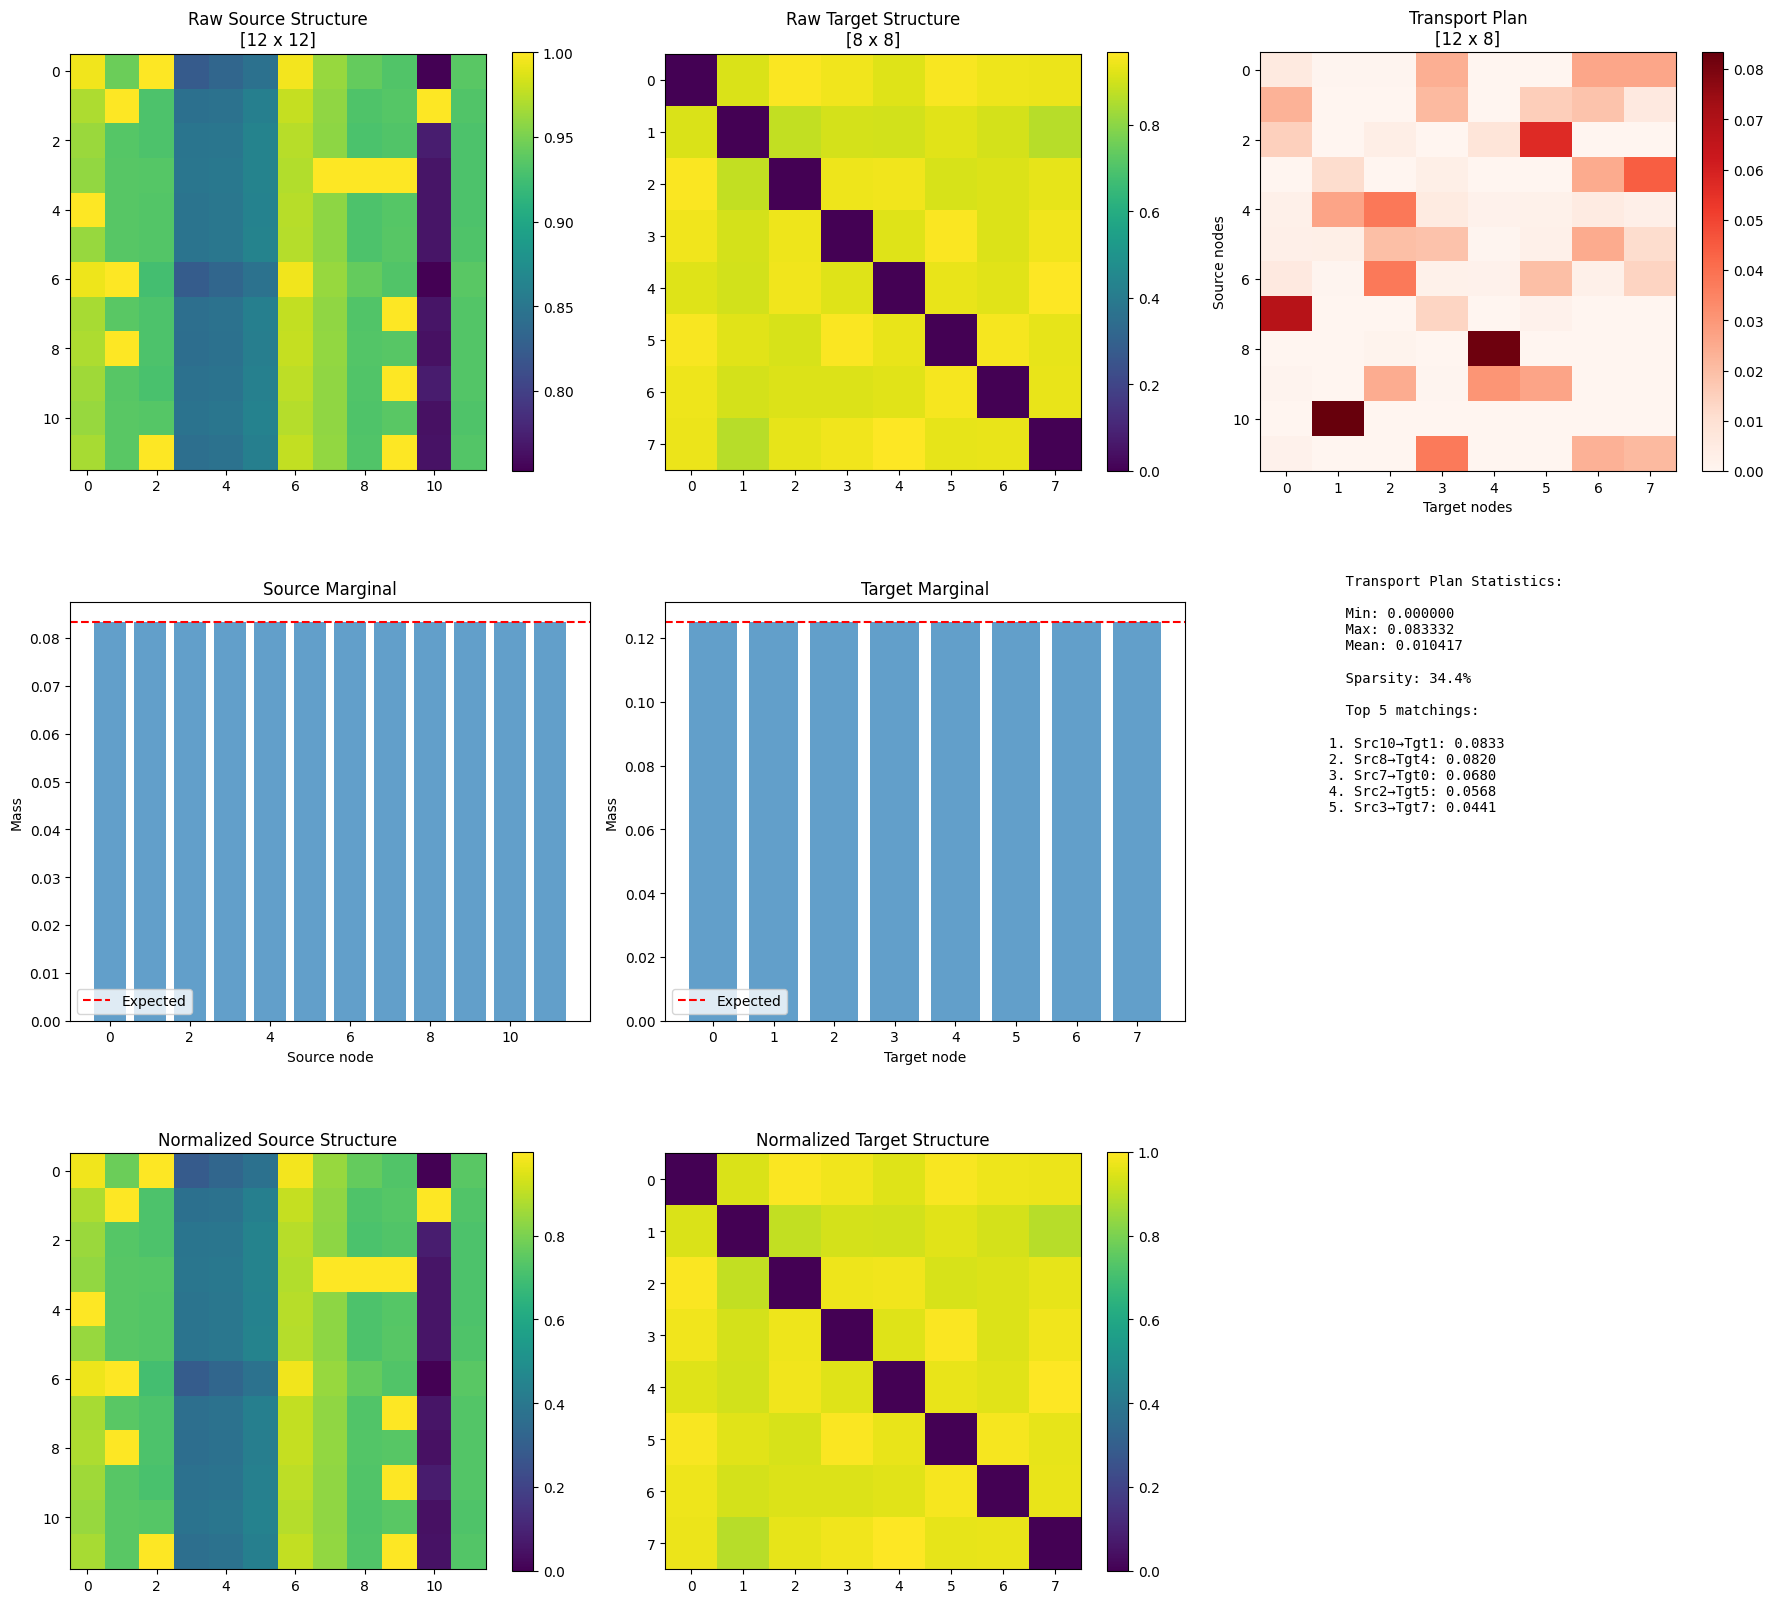

✅ Visualization saved!
  - heart_target_4 | Sample 1 → Graph 1


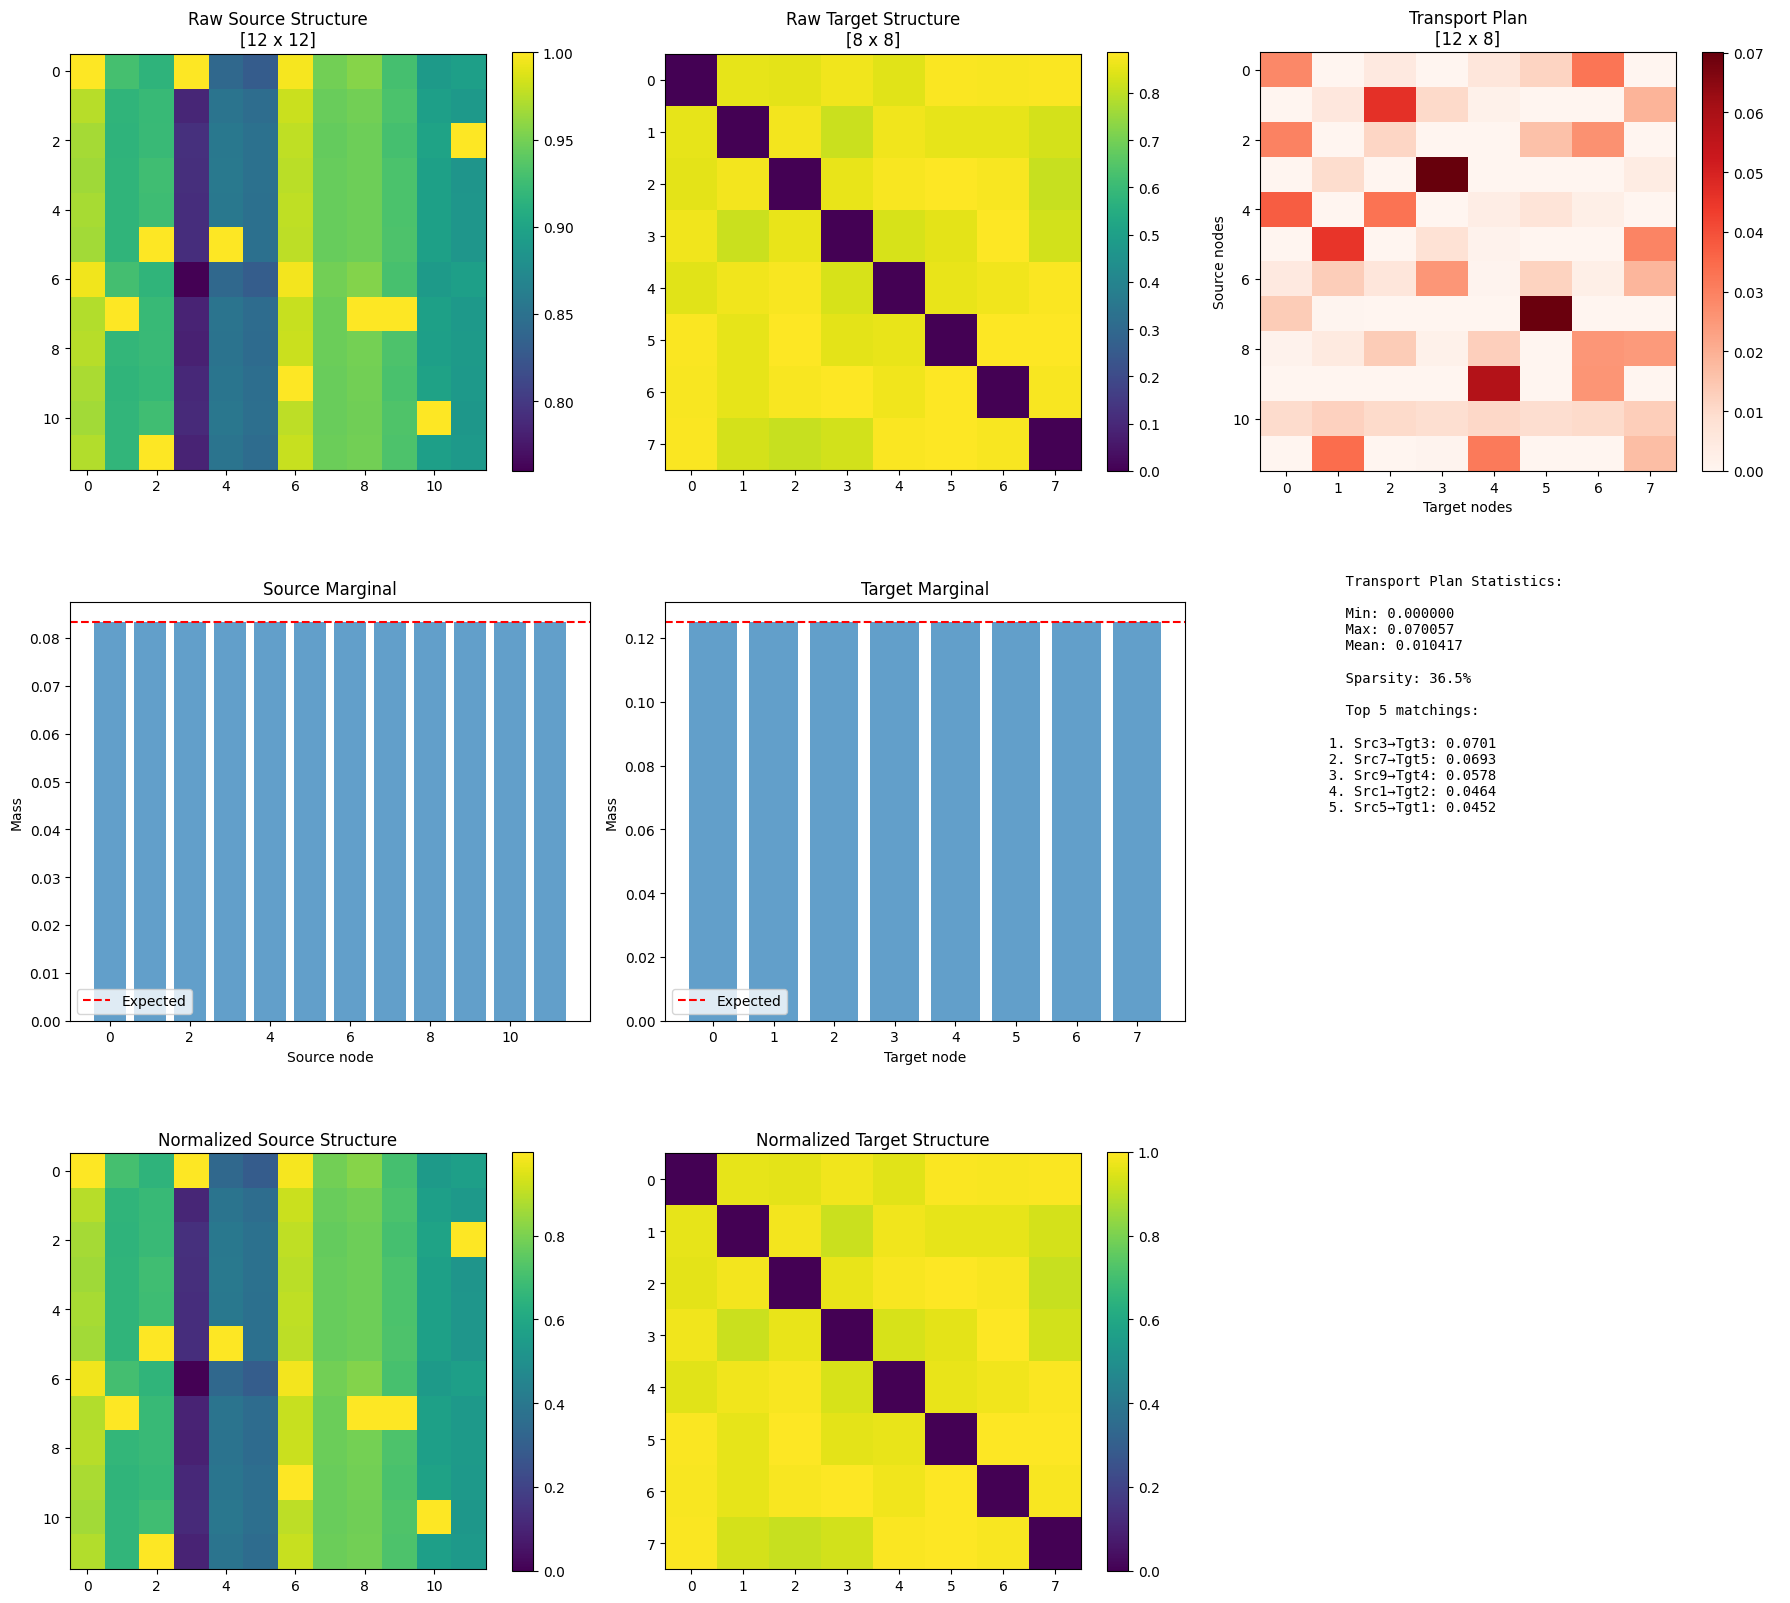

✅ Visualization saved!
  - heart_target_4 | Sample 2 → Graph 2


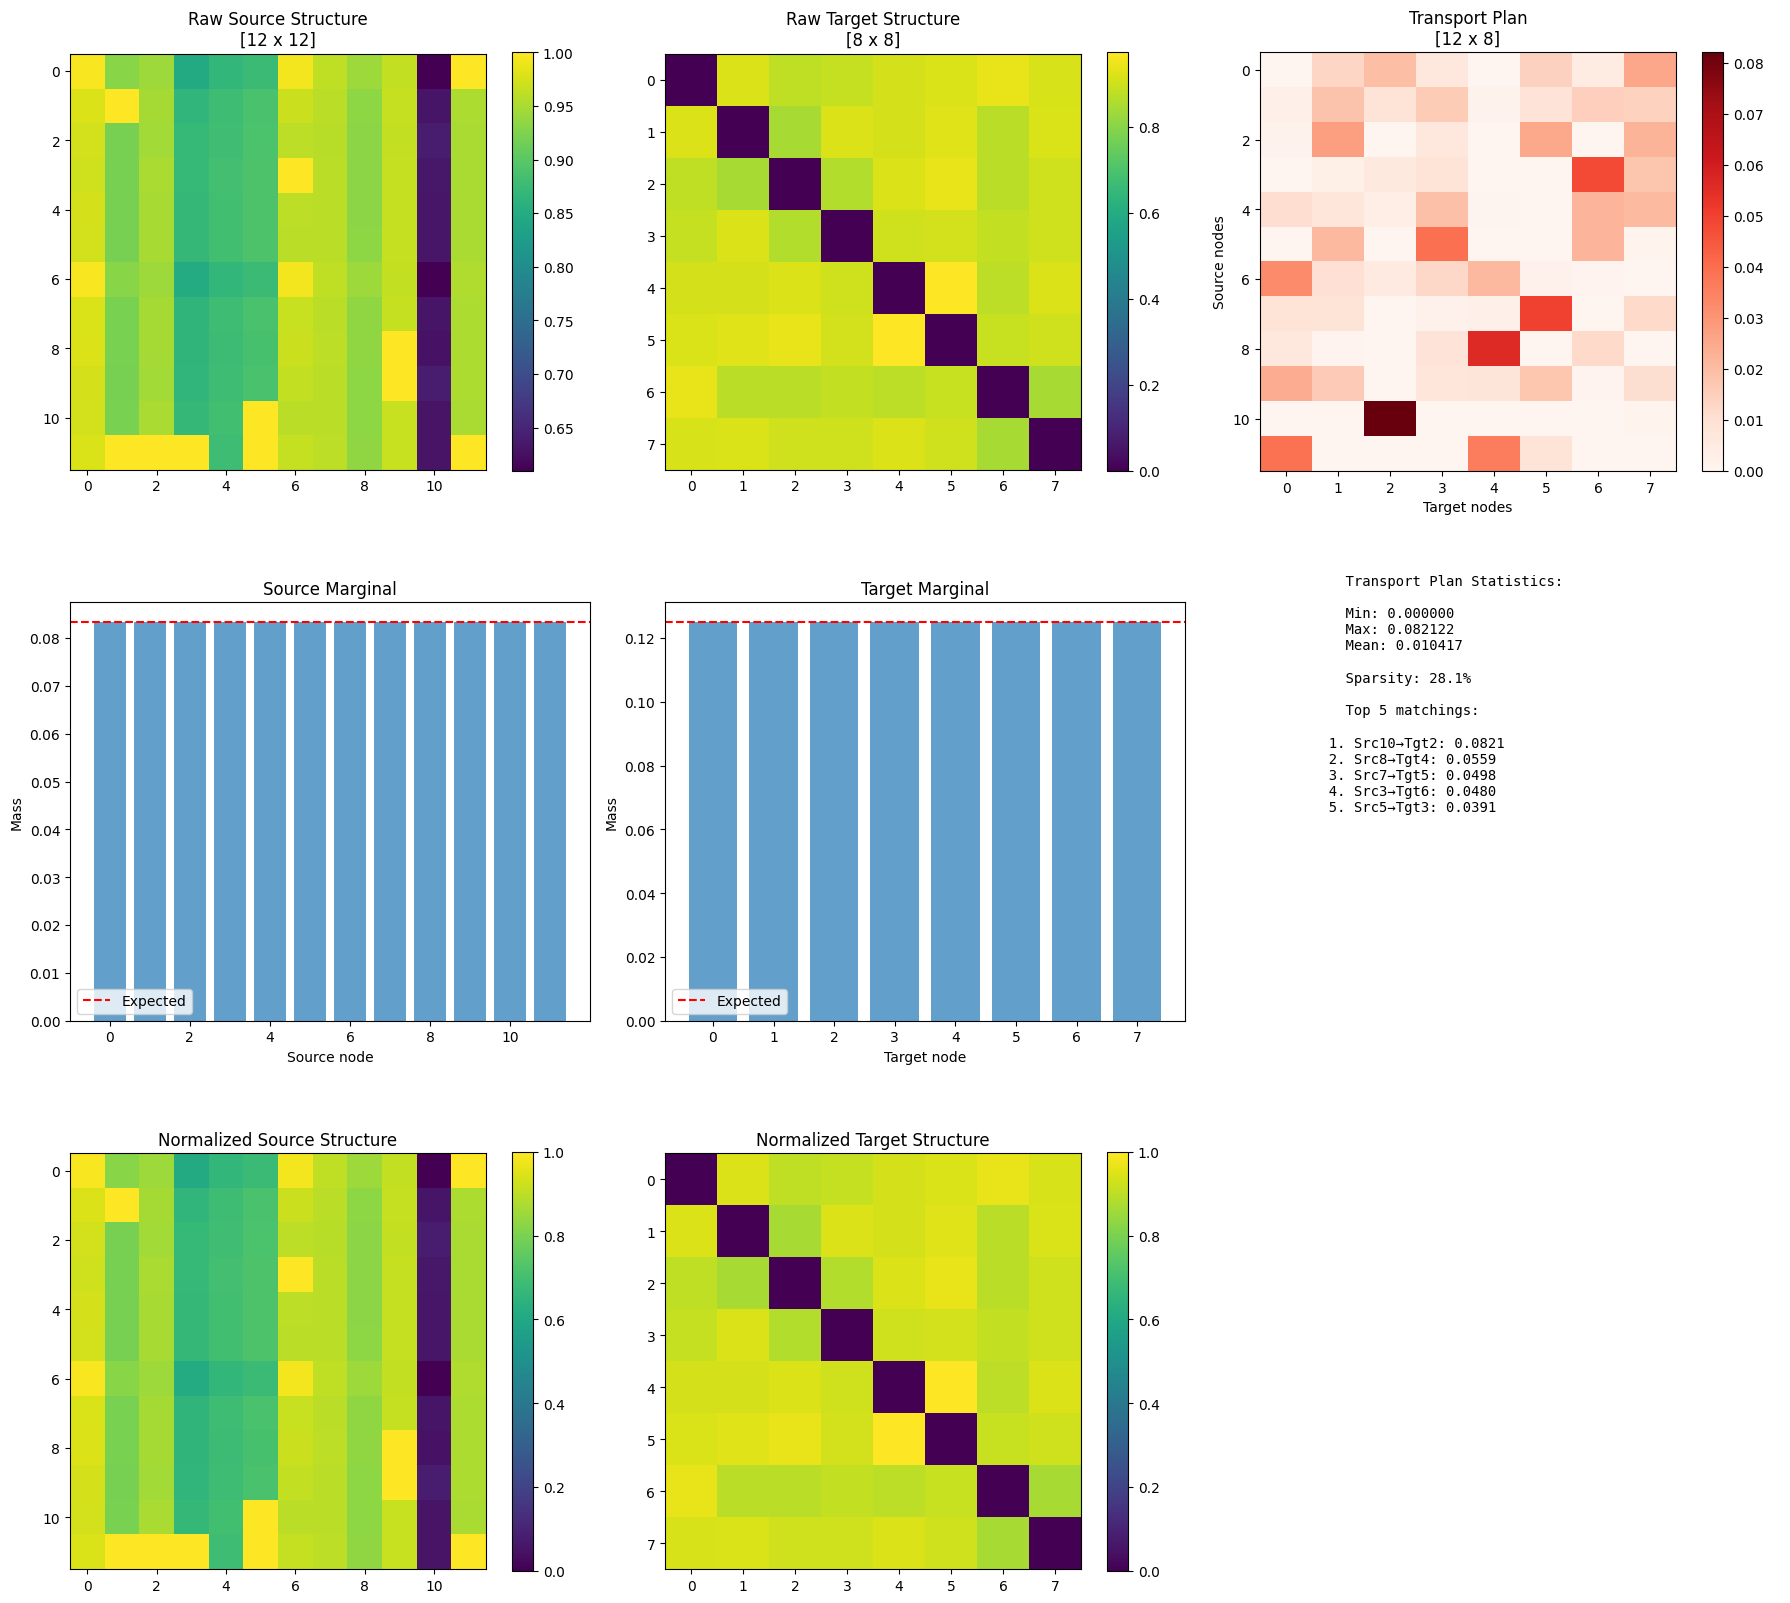

✅ Visualization saved!
  - heart_target_4 | Sample 3 → Graph 3


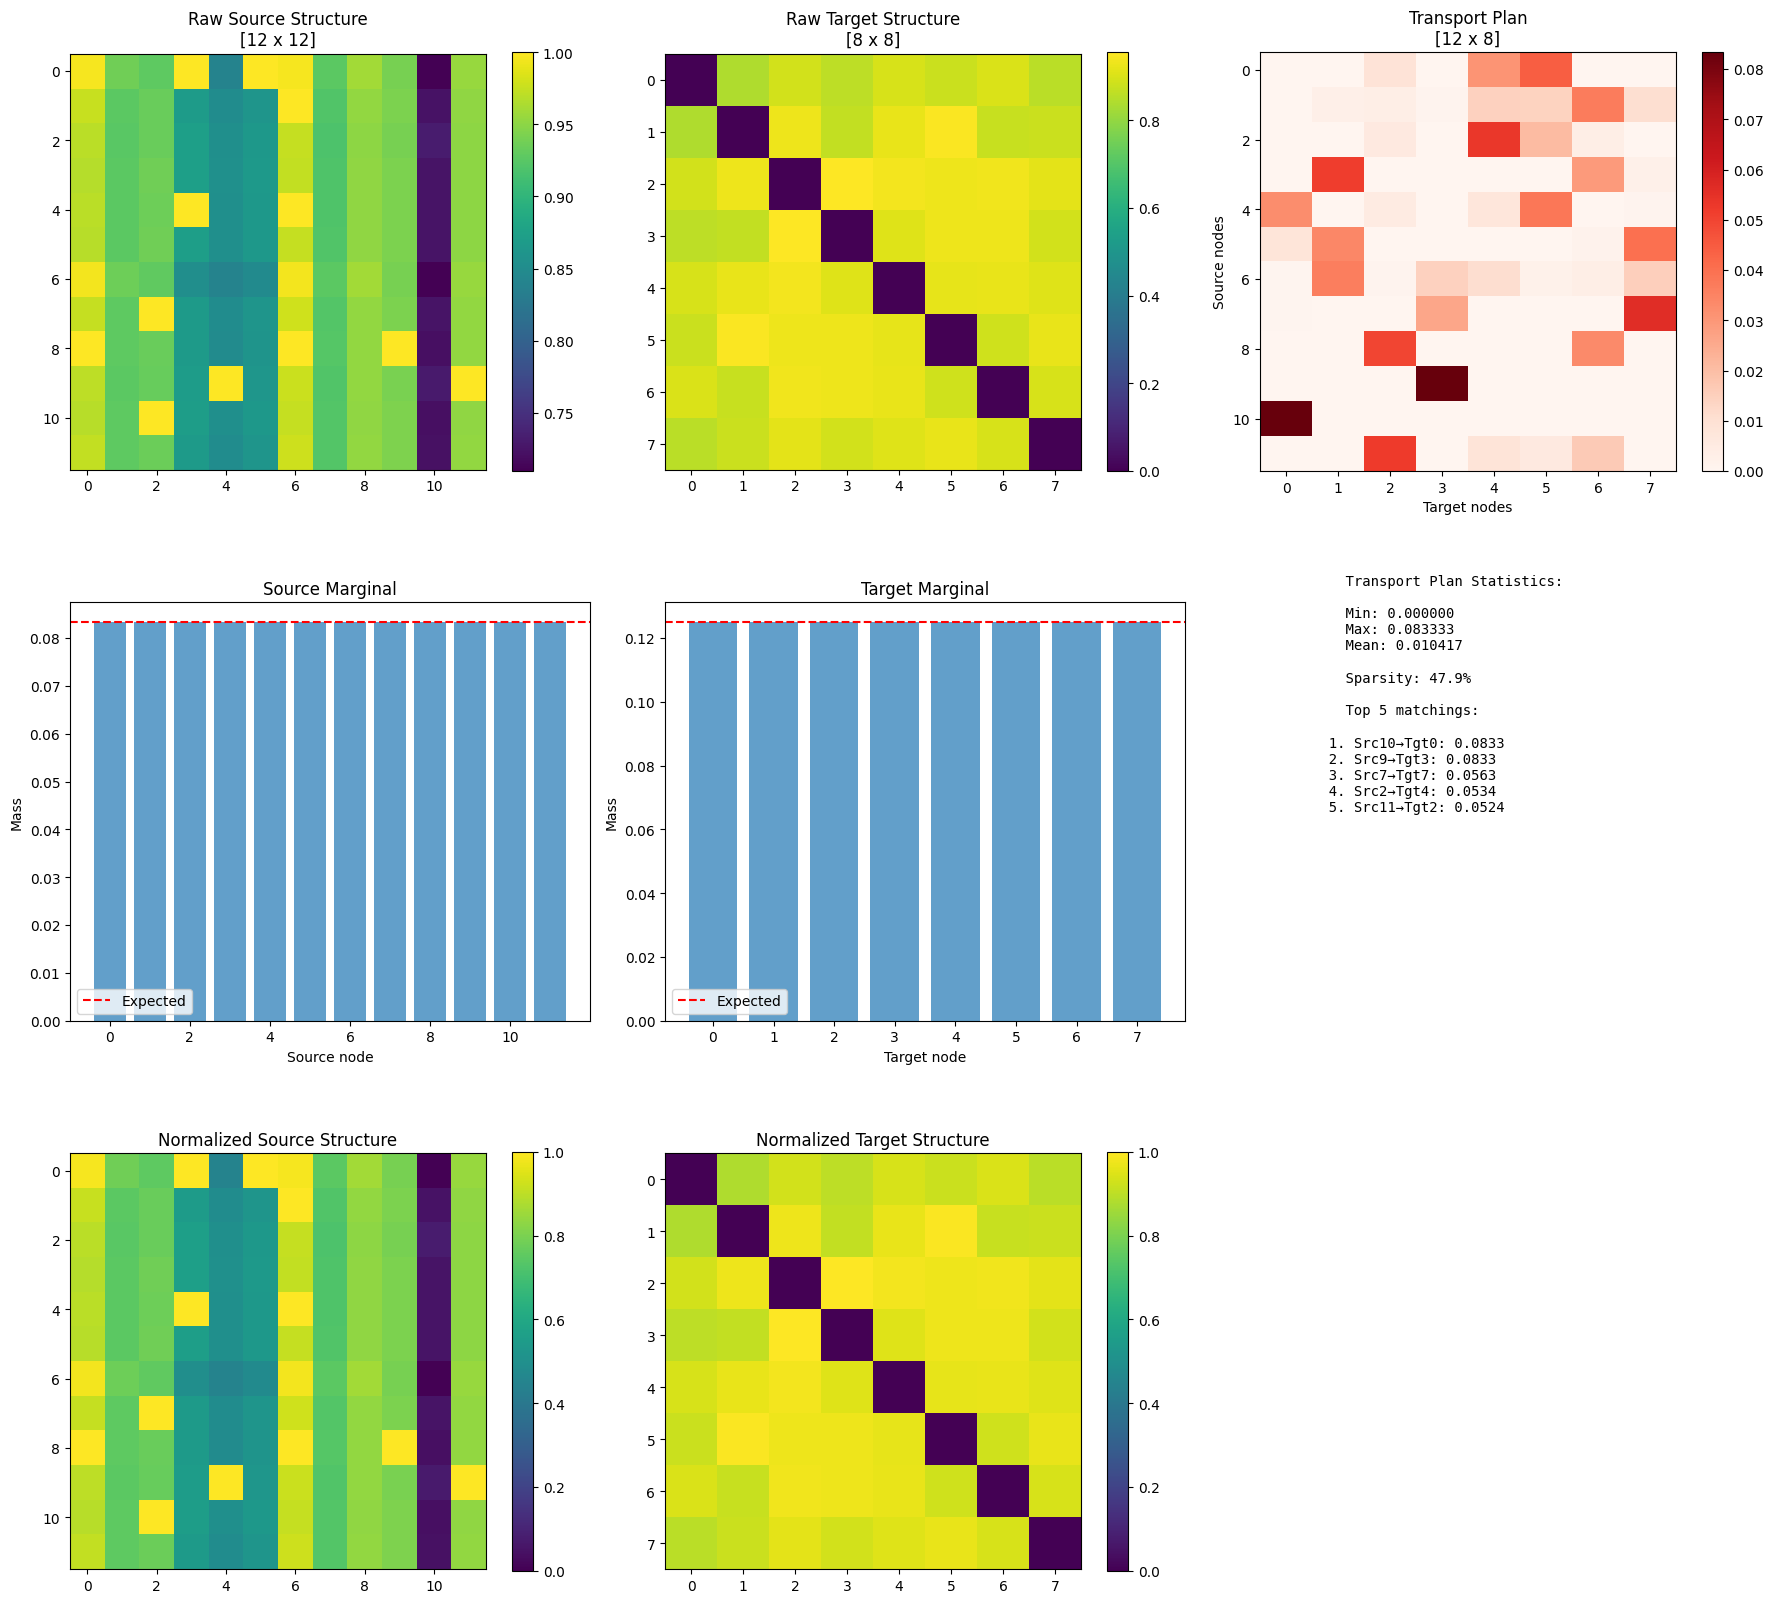

✅ Visualization saved!
  - heart_target_4 | Sample 4 → Graph 4


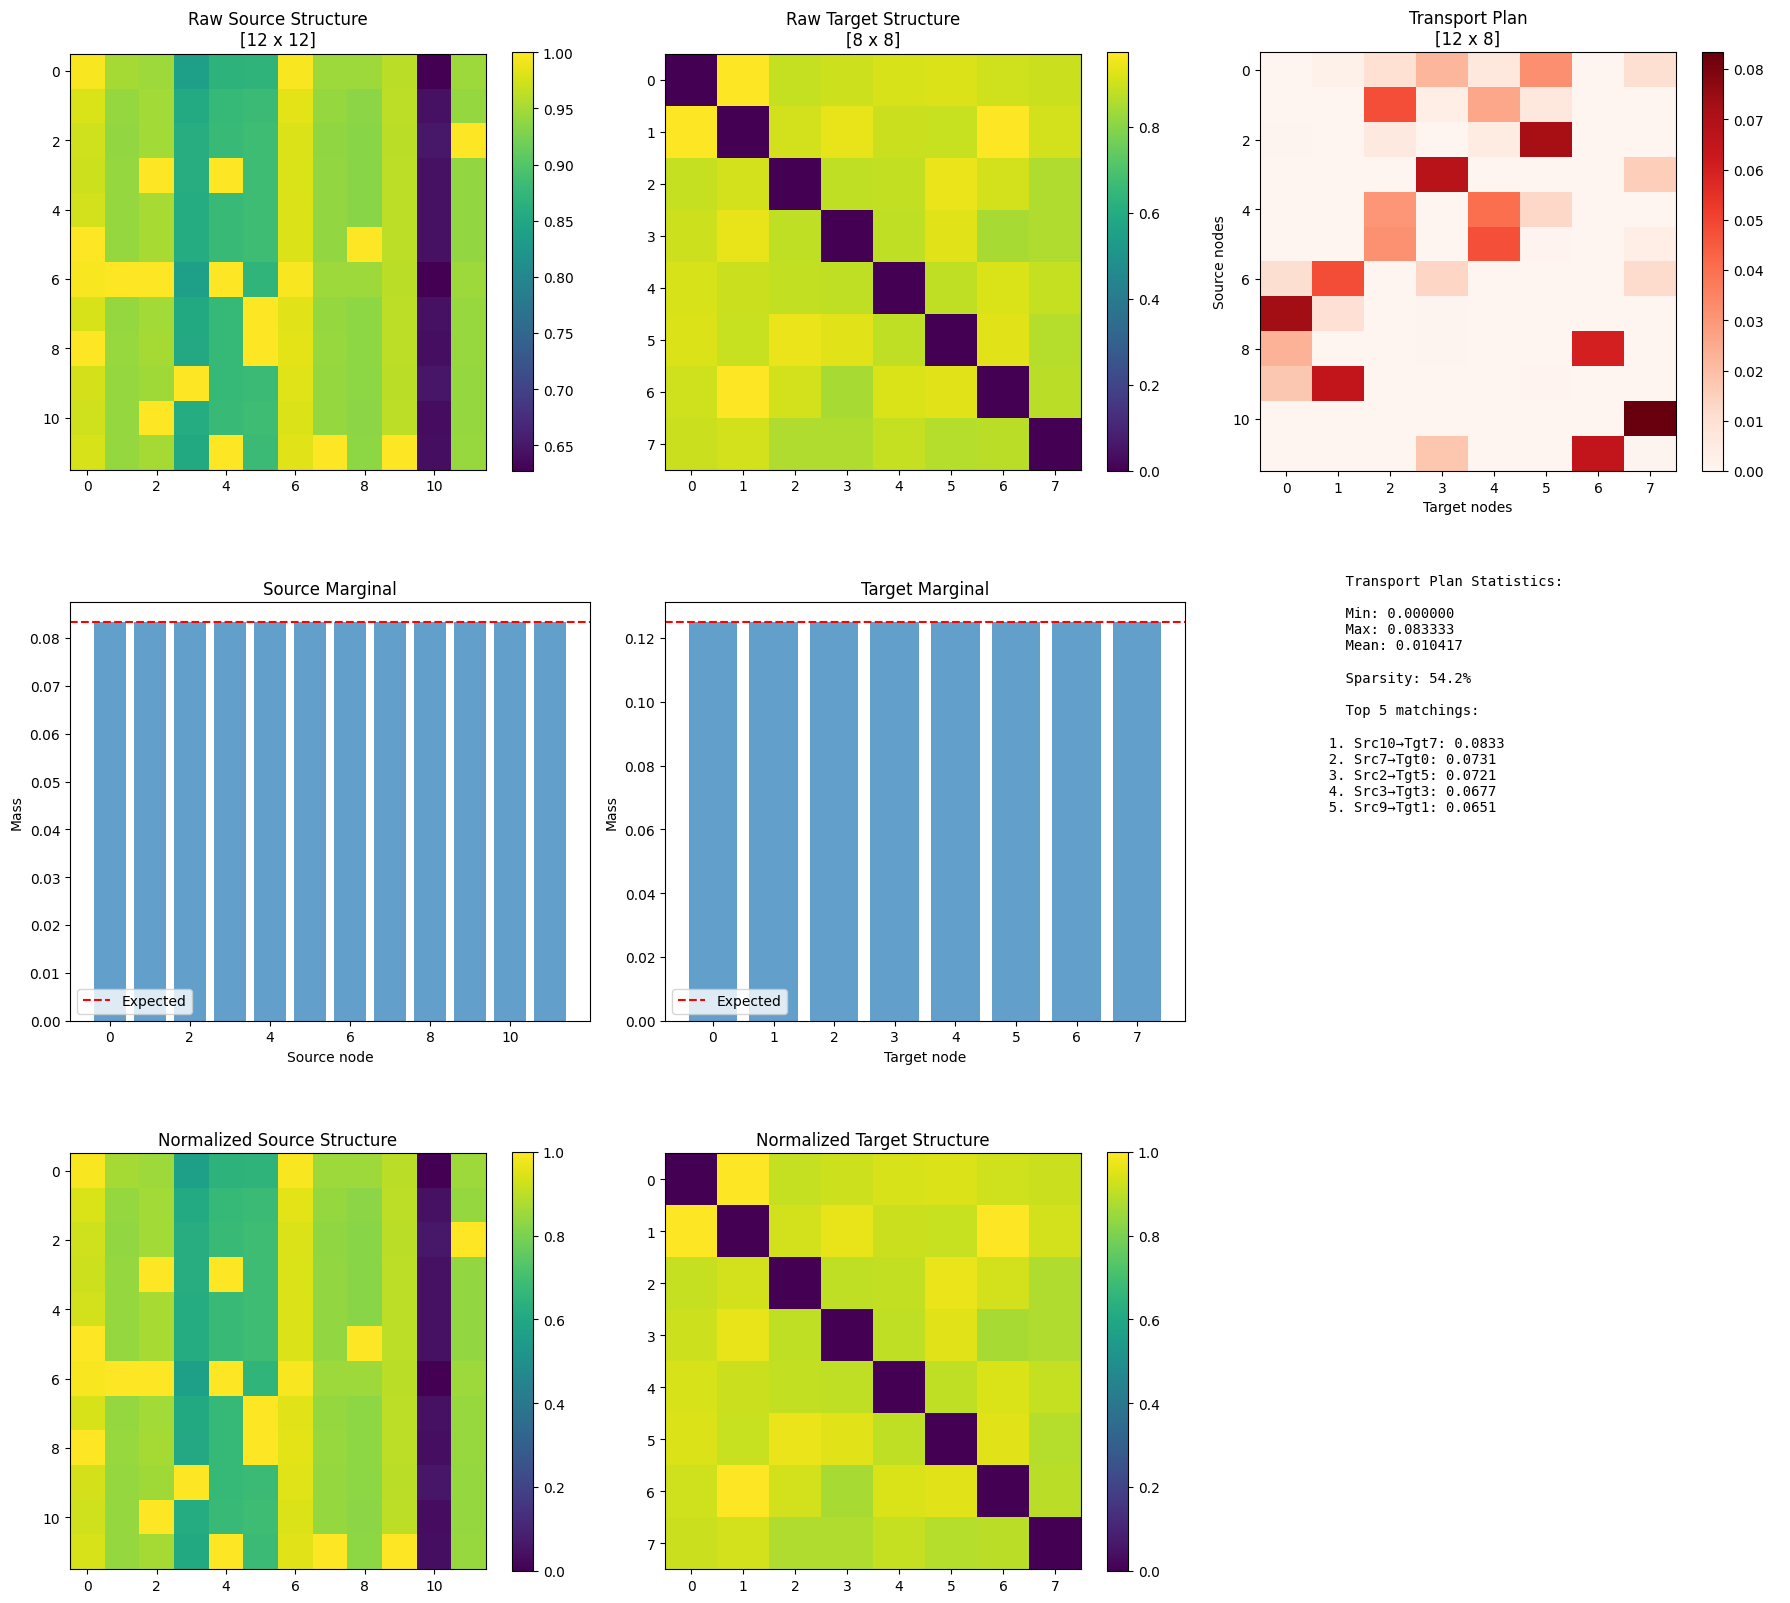

✅ Visualization saved!


In [14]:
if __name__ == "__main__":
    
    # Learnable LCG init
    learnable_graphs = LearnableGraphs(M=8, K=8, D=model.input_dim).to(device)
    optimizer = torch.optim.Adam(learnable_graphs.parameters(), lr=1e-3)

    # ========= Multi-Source Training =========
    for epoch in range(1, 4):
        print(f"\n===== Epoch {epoch} =====")
        avg_loss = train_with_pot_fgw_multi_source(
            model, loaders, learnable_graphs, optimizer,
            alpha=0.5, reg=0.01, batches_per_source=40
        )
        print(f"[Epoch {epoch}] Avg Loss = {avg_loss:.4f}")

    print("\n🎉 Multi-Source Training Completed!")

    # ========= Multi-Source FGW Visualization =========
    visualize_multi_source_alignment(
        model, loaders, learnable_graphs,
        alpha=0.5, reg=0.01
    )



===== Processing Source: Heart_disease_statlog =====
Collected 3510 embeddings from Heart_disease_statlog

===== Processing Source: Cardiovascular_Disease_Dataset =====
Collected 13000 embeddings from Cardiovascular_Disease_Dataset

===== Processing Source: heart_target_3 =====
Collected 16000 embeddings from heart_target_3

===== Processing Source: heart_target_4 =====
Collected 12000 embeddings from heart_target_4


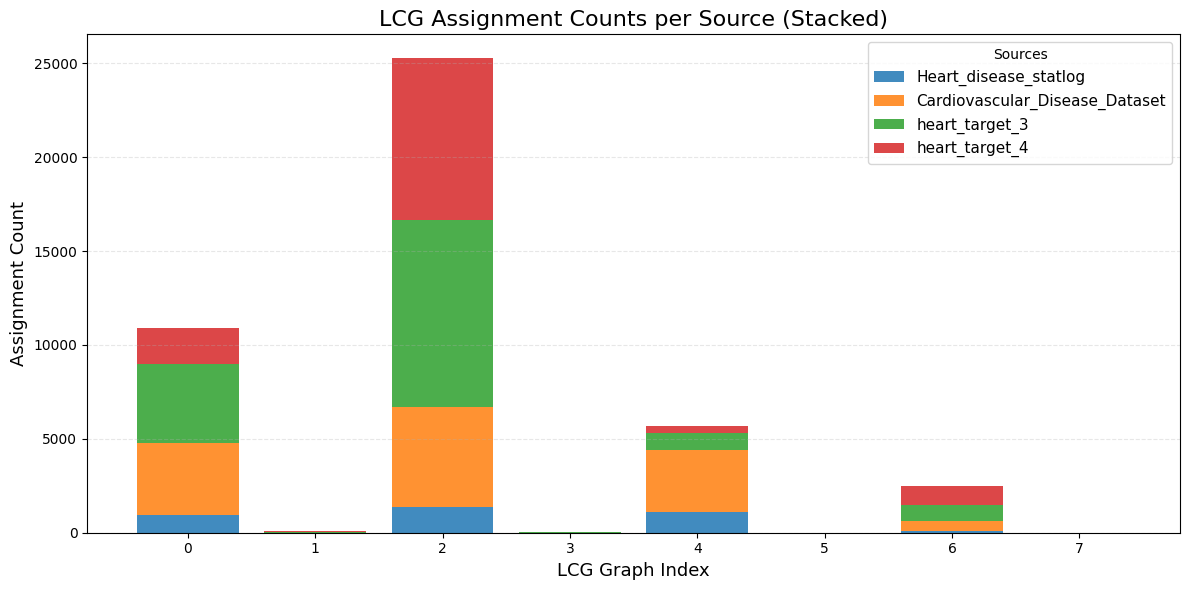


===== Multi-source Assignment Matrix =====
[[ 947.    0. 1355.    0. 1103.    0.  105.    0.]
 [3847.    0. 5334.    0. 3315.    0.  504.    0.]
 [4183.   51. 9972.   24.  906.    0.  864.    0.]
 [1923.   50. 8617.   23.  356.    0. 1031.    0.]]


In [15]:
assignment_matrix = analyze_multi_source_lcg_assignments(
    model,
    loaders,
    learnable_graphs,
    num_batches=320
)


In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_global_lcg_assignments(model, loaders, learnable_graphs, num_batches=30):
    """
    모든 source의 embedding을 모아서
    가장 가까운 LCG assignment를 bar graph로 출력하는 함수
    """
    model.eval()
    learnable_graphs.eval()

    # LCG embeddings
    lcg_embs = learnable_graphs.node_embeddings.detach().cpu().numpy()  # [M, K, D]
    M = learnable_graphs.M

    # 전체 assignment count
    total_counts = np.zeros(M)

    print("\n==============================")
    print("   GLOBAL LCG ASSIGNMENT MAP")
    print("==============================")

    for source_name, dataloader in loaders.items():
        print(f"\nProcessing {source_name} ...")

        emb_list = []
        for i, batch in enumerate(dataloader):
            if i >= num_batches:
                break
            features, _ = extract_source_graph(model, batch)
            emb_list.append(features.reshape(-1, features.shape[-1]))

        # [N_total, D]
        sample_embs = torch.cat(emb_list, dim=0).detach().cpu().numpy()

        # 각 embedding → 가장 가까운 LCG 찾기
        for i in range(sample_embs.shape[0]):
            node = sample_embs[i]
            dists = [
                np.linalg.norm(lcg_embs[m] - node, axis=1).mean()
                for m in range(M)
            ]
            closest = np.argmin(dists)
            total_counts[closest] += 1

    # ================================
    # Bar graph (전체 assignment)
    # ================================
    plt.figure(figsize=(10, 5))
    x = np.arange(M)
    plt.bar(x, total_counts, color="steelblue", alpha=0.85)

    plt.title("Global LCG Assignment Distribution (All Sources Combined)")
    plt.xlabel("LCG Index")
    plt.ylabel("Assignment Count")
    plt.xticks(x, x)
    plt.grid(True, alpha=0.3)

    for i, cnt in enumerate(total_counts):
        plt.text(i, cnt + max(total_counts)*0.01, f"{int(cnt)}", 
                 ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\nGlobal assignment counts:", total_counts)
    return total_counts



   GLOBAL LCG ASSIGNMENT MAP

Processing Heart_disease_statlog ...

Processing Cardiovascular_Disease_Dataset ...

Processing heart_target_3 ...

Processing heart_target_4 ...


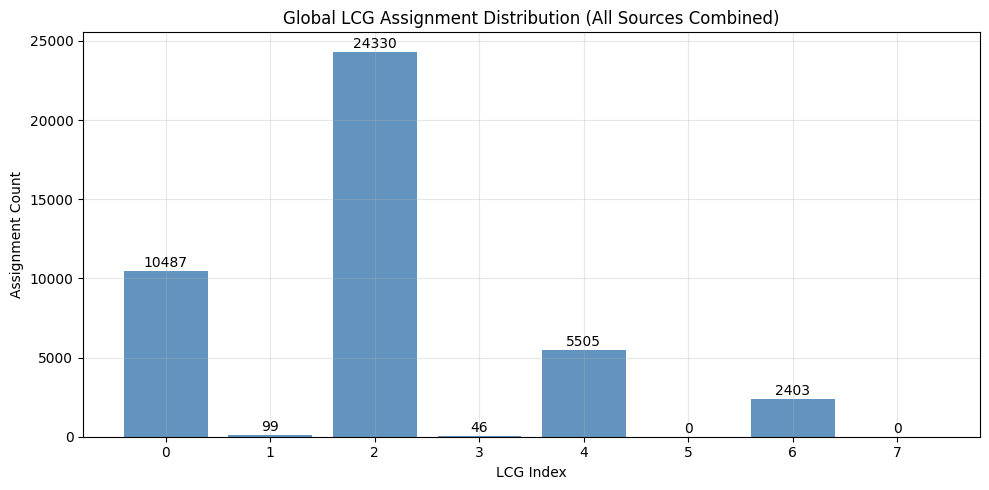


Global assignment counts: [10487.    99. 24330.    46.  5505.     0.  2403.     0.]


In [17]:
global_counts = plot_global_lcg_assignments(model, loaders, learnable_graphs)


In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def analyze_sources_and_lcgs(model, loaders, learnable_graphs):
    """
    num_batches 같은 제한 없이
    - 모든 source의 전체 샘플 mean/std 출력
    - 모든 LCG mean/std 출력
    - 모든 source 전체 샘플을 기반으로 한 LCG assignment bar graph 출력
    """
    model.eval()
    learnable_graphs.eval()

    # =====================================================================
    # 1. LCG mean/std 계산
    # =====================================================================
    lcg_embs = learnable_graphs.node_embeddings.detach().cpu().numpy()  # [M, K, D]
    M = learnable_graphs.M

    print("\n====================================")
    print("          L C G   S T A T S")
    print("====================================")

    lcg_means = []
    lcg_stds  = []

    for m in range(M):
        emb = lcg_embs[m]   # [K, D]
        mean_val = emb.mean()
        std_val  = emb.std()
        lcg_means.append(mean_val)
        lcg_stds.append(std_val)

        print(f"\n[LCG {m}]")
        print(f"  Mean: {mean_val:.4f}")
        print(f"  Std : {std_val:.4f}")

    # =====================================================================
    # 2. Source mean/std + ALL SAMPLE assignment
    # =====================================================================
    print("\n====================================")
    print("        S O U R C E   S T A T S")
    print("====================================")

    source_means = {}
    source_stds  = {}

    total_counts = np.zeros(M)  # 전체 assignment count

    for source_name, dataloader in loaders.items():
        print(f"\nProcessing Source: {source_name}")

        emb_list = []

        # ---- 전체 샘플 전부 사용 ----
        for batch in dataloader:
            features, _ = extract_source_graph(model, batch)
            emb_list.append(features.reshape(-1, features.shape[-1]))

        # ---- 모든 배치 concat ----
        sample_embs = torch.cat(emb_list, dim=0).detach().cpu().numpy()  # [N_total, D]

        # mean/std 계산
        src_mean = sample_embs.mean()
        src_std  = sample_embs.std()

        source_means[source_name] = src_mean
        source_stds[source_name]  = src_std

        print(f"[{source_name}]")
        print(f"  Mean: {src_mean:.4f}")
        print(f"  Std : {src_std:.4f}")

        # =====================================================================
        # 3. 이 source의 모든 sample → LCG assignment 계산
        # =====================================================================
        for i in range(sample_embs.shape[0]):
            node = sample_embs[i]  # [D]

            # 모든 LCG와 거리 계산
            dists = [
                np.linalg.norm(lcg_embs[m] - node, axis=1).mean()
                for m in range(M)
            ]

            closest = np.argmin(dists)
            total_counts[closest] += 1

    # =====================================================================
    # 4. Assignment Bar Graph (전체 데이터 기준)
    # =====================================================================
    plt.figure(figsize=(10, 5))
    x = np.arange(M)

    plt.bar(x, total_counts, color="steelblue", alpha=0.85)
    plt.title("Global LCG Assignment (All Sources, All Samples)")
    plt.xlabel("LCG Index")
    plt.ylabel("Assignment Count")
    plt.xticks(x, x)
    plt.grid(True, alpha=0.3)

    for i, cnt in enumerate(total_counts):
        plt.text(i, cnt + max(total_counts)*0.015,
                 f"{int(cnt)}", ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n====================================")
    print("  GLOBAL LCG ASSIGNMENT COUNTS")
    print("====================================")
    print(total_counts)

    return {
        "source_means": source_means,
        "source_stds": source_stds,
        "lcg_means": lcg_means,
        "lcg_stds": lcg_stds,
        "assign_counts": total_counts
    }



          L C G   S T A T S

[LCG 0]
  Mean: -0.0086
  Std : 2.0870

[LCG 1]
  Mean: -0.0478
  Std : 2.1046

[LCG 2]
  Mean: 0.0346
  Std : 2.0919

[LCG 3]
  Mean: -0.1211
  Std : 2.1280

[LCG 4]
  Mean: 0.0684
  Std : 2.1051

[LCG 5]
  Mean: -0.0415
  Std : 2.2037

[LCG 6]
  Mean: 0.0812
  Std : 2.1658

[LCG 7]
  Mean: -0.0182
  Std : 2.1347

        S O U R C E   S T A T S

Processing Source: Heart_disease_statlog
[Heart_disease_statlog]
  Mean: 0.0714
  Std : 4.4552

Processing Source: Cardiovascular_Disease_Dataset
[Cardiovascular_Disease_Dataset]
  Mean: 0.0538
  Std : 4.8532

Processing Source: heart_target_3
[heart_target_3]
  Mean: 0.0345
  Std : 4.7207

Processing Source: heart_target_4
[heart_target_4]
  Mean: 0.0370
  Std : 4.3080


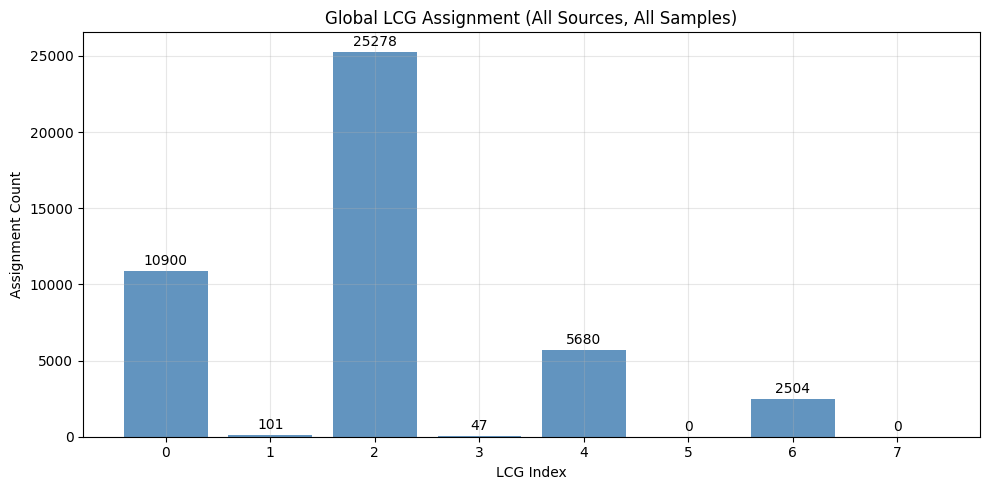


  GLOBAL LCG ASSIGNMENT COUNTS
[10900.   101. 25278.    47.  5680.     0.  2504.     0.]


In [19]:
results = analyze_sources_and_lcgs(model, loaders, learnable_graphs)


In [26]:
def plot_node_and_lcg_tsne(model, loaders, learnable_graphs):
    from sklearn.manifold import TSNE
    import numpy as np
    import matplotlib.pyplot as plt
    import torch

    model.eval()
    learnable_graphs.eval()

    # -----------------------------------------------------
    # 1) 모든 source 노드 → LCG distance feature 만들기
    # -----------------------------------------------------
    all_features = []
    all_labels = []

    label_map = {}
    for i, src in enumerate(loaders.keys()):
        label_map[src] = i

    lcg_embs = learnable_graphs.node_embeddings.detach().cpu().numpy()   # [M, K, D]
    M, K, D = lcg_embs.shape

    for src_name, dataloader in loaders.items():
        for batch in dataloader:
            features, _ = extract_source_graph(model, batch)
            features = features.reshape(-1, features.shape[-1]).detach().cpu().numpy()

            # 각 노드 → LCG distance 벡터
            dist_vecs = []
            for node in features:
                d = [np.linalg.norm(lcg_embs[m] - node, axis=1).mean() for m in range(M)]
                dist_vecs.append(d)

            all_features.extend(dist_vecs)
            all_labels.extend([label_map[src_name]] * len(dist_vecs))

    all_features = np.array(all_features)
    all_labels = np.array(all_labels)

    # -----------------------------------------------------
    # 2) LCG centroid도 t-SNE 입력 공간에 넣기
    # -----------------------------------------------------
    lcg_center_vecs = []
    for m in range(M):
        # LCG m의 centroid node → LCG 전체까지 distance
        centroid = lcg_embs[m].mean(axis=0)
        d = [np.linalg.norm(lcg_embs[j] - centroid, axis=1).mean() for j in range(M)]
        lcg_center_vecs.append(d)

    lcg_center_vecs = np.array(lcg_center_vecs)

    # 합치기
    X = np.vstack([all_features, lcg_center_vecs])

    # -----------------------------------------------------
    # 3) t-SNE 변환
    # -----------------------------------------------------
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1500)
    X_tsne = tsne.fit_transform(X)

    node_tsne = X_tsne[:-M]      # 모든 sample node
    lcg_tsne = X_tsne[-M:]       # LCG centroid

    # -----------------------------------------------------
    # 4) 시각화: source node + LCG
    # -----------------------------------------------------
    plt.figure(figsize=(12, 10))
    colors = ['red', 'blue', 'green', 'orange', 'purple']

    # Node clusters
    for src_name, idx in label_map.items():
        points = node_tsne[all_labels == idx]
        plt.scatter(points[:, 0], points[:, 1], s=5, alpha=0.55,
                    color=colors[idx % len(colors)],
                    label=src_name)

    # LCG centroid (큰 점 + 검정 테두리)
    plt.scatter(lcg_tsne[:, 0], lcg_tsne[:, 1],
                s=600, color="yellow", edgecolor="black",
                marker="*", label="LCG Prototypes")

    for i in range(M):
        plt.text(lcg_tsne[i, 0], lcg_tsne[i, 1],
                 f"LCG {i}", fontsize=12, weight="bold")

    plt.title("t-SNE Visualization of Node Embeddings + LCG Prototypes")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return node_tsne, all_labels, lcg_tsne


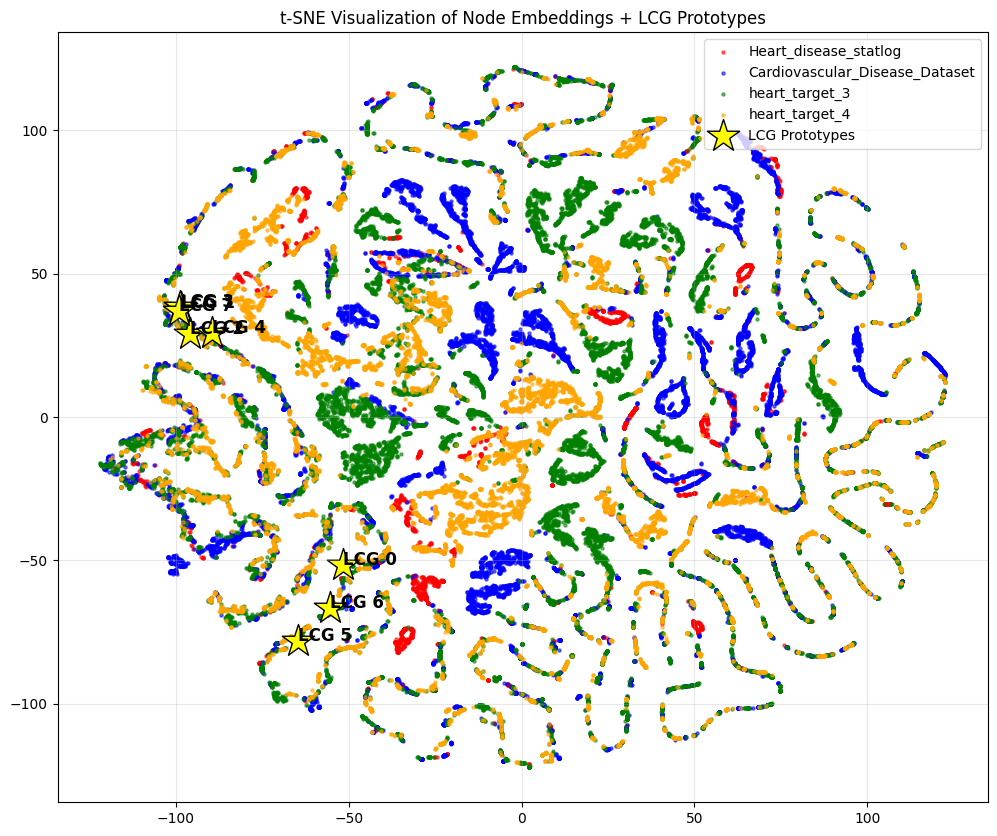

In [28]:
_, emb, labels = plot_node_and_lcg_tsne(model, loaders, learnable_graphs)